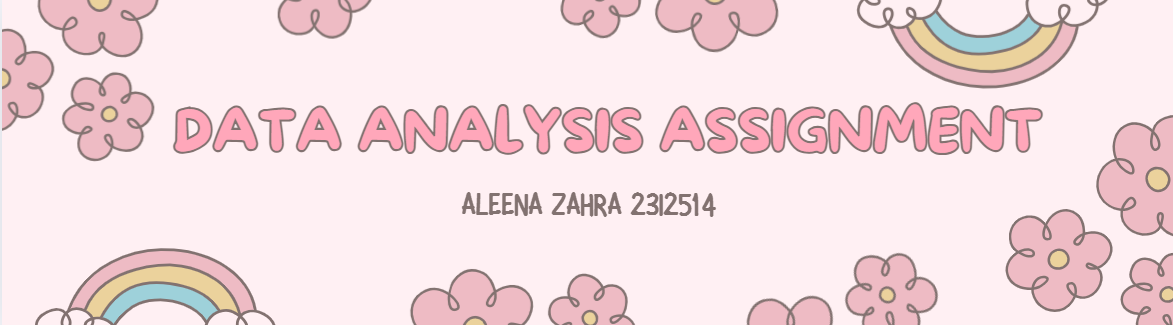

### <a id='toc1_1_1_'></a>[Importing Libraries and Notebook Setup](#toc0_)

In [9]:
# all libraries i used later
import datetime
import numpy as np
import pandas as pd
import pandas.api.types as ptypes
from skimpy import skim
from ChernoffFace import chernoff_face
import cv2
# Visualizations
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import parallel_coordinates
%matplotlib inline

# Network and graphs
from pyvis.network import Network
from urllib.parse import quote_plus
import webbrowser
from IPython.display import display, HTML

# Pandas settings
pd.options.display.max_columns = None
pd.options.display.max_colwidth = 60
pd.options.display.float_format = '{:,.3f}'.format

# Visualization settings
from matplotlib import rcParams
plt.style.use('fivethirtyeight')
rcParams['figure.figsize'] = (16, 5)   
rcParams['axes.spines.right'] = False
rcParams['axes.spines.top'] = False
rcParams['font.size'] = 12
# rcParams['figure.dpi'] = 300
rcParams['savefig.dpi'] = 300
plt.rc('xtick', labelsize=11)
plt.rc('ytick', labelsize=11)
custom_hue = ['#004c6d', '#346888', '#5886a5', '#7aa6c2', '#9dc6e0', '#c1e7ff']
custom_divergent = ['#00876c', '#6aaa96', '#aecdc2', '#f1f1f1', '#f0b8b8', '#e67f83', '#d43d51']

%config InlineBackend.figure_format = 'retina'



kawaii_palette = ["#FC7D8A", "#E0FF6F", "#FFFF8D", "#72DEFF", "#FFBAF7", "#FF6ED1"]
sns.set_palette(kawaii_palette)

# Global styling
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams['figure.facecolor'] = "#FFF7FB"
plt.rcParams['axes.facecolor'] = "#FFFFFF"
plt.rcParams['axes.edgecolor'] = "#FFB7CE"
plt.rcParams['axes.titlecolor'] = "#FF5C8A"
plt.rcParams['axes.labelcolor'] = "#FF5C8A"
plt.rcParams['xtick.color'] = "#FF69B4"
plt.rcParams['ytick.color'] = "#FF69B4"
plt.rcParams['grid.color'] = "#F9DDE3"
plt.rcParams['axes.titleweight'] = "bold"
plt.rcParams['axes.titlepad'] = 15
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.edgecolor'] = "#FFB7CE"


c:\Users\ThinkPad T480s\AppData\Local\Programs\Python\Python313\Lib\site-packages\ChernoffFace\DataLoaders.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources



---

# <a id='toc2_'></a>[Football Dataset](#toc0_)

## <a id='toc2_1_'></a>[Introduction](#toc0_)



<div class="alert alert-danger" role="alert">
The FIFA World Cup is the most prestigious tournament in international football, played every four years and watched by millions worldwide. This dataset contains historical World Cup match records, including match dates, participating teams, goals scored, match locations, tournament rounds, and additional observations. The purpose of this analysis is to explore historical trends in World Cup match data and understand patterns in goals, team performance, and tournament evolution over time.

In this section, I focus on cleaning the dataset, handling duplicates, exploring numerical and categorical attributes, and using data visualizations to uncover patterns. I also construct a graph network of team interactions to explore relationships between teams based on match connections.


``` Hypothesis: The number of goals for all World cup matches will be the highest for germany ```

To explore this hypothesis, I will:

- Load and inspect the dataset

- Clean and prepare the data for analysis

- Explore historical trends in the number of matches played per tournament for each country

This analysis begins with basic exploration and preprocessing, followed by univariate, bivariate, and multivariate analysis, and ends with a graph network visualization of team interactions for the 2014 World Cup.

### Loading Data

In [3]:
# Load DataFrame
df = pd.read_excel('football_world_cups_results.xlsx')

### Basic Data Exploration

In [4]:
# Show rows and columns count
print(f"Total Rows: {df.shape[0]}\nTotal Columns: {df.shape[1]}")

Total Rows: 852
Total Columns: 12


In [5]:
df.head()

,Year,Date,Time,Round,Stadium,City,Country,HomeTeam,HomeGoals,AwayGoals,AwayTeam,Observation
0,1930,1930-07-13,15:00,Group 1,Pocitos,Montevideo,Uruguay,France,4,1,Mexico,
1,1930,1930-07-13,15:00,Group 4,Parque Central,Montevideo,Uruguay,USA,3,0,Belgium,
2,1930,1930-07-14,12:45,Group 2,Parque Central,Montevideo,Uruguay,Yugoslavia,2,1,Brazil,
3,1930,1930-07-14,14:50,Group 3,Pocitos,Montevideo,Uruguay,Romania,3,1,Peru,
4,1930,1930-07-15,16:00,Group 1,Parque Central,Montevideo,Uruguay,Argentina,1,0,France,


In [6]:
df.tail()

,Year,Date,Time,Round,Stadium,City,Country,HomeTeam,HomeGoals,AwayGoals,AwayTeam,Observation
847,2014,2014-07-05,17:00,Quarter-finals,Arena Fonte Nova,Salvador,Brazil,Netherlands,0,0,Costa Rica,Netherlands win on penalties (4 - 3)
848,2014,2014-07-08,17:00,Semi-finals,Estadio Mineirao,Belo Horizonte,Brazil,Brazil,1,7,Germany,
849,2014,2014-07-09,17:00,Semi-finals,Arena de Sao Paulo,Sao Paulo,Brazil,Netherlands,0,0,Argentina,Argentina win on penalties (2 - 4)
850,2014,2014-07-12,17:00,Play-off for third place,Estadio Nacional,Brasilia,Brazil,Brazil,0,3,Netherlands,
851,2014,2014-07-13,16:00,Final,Estadio do Maracana,Rio De Janeiro,Brazil,Germany,1,0,Argentina,Germany win after extra time


#### Check Data Types

In [7]:
# Show data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 852 entries, 0 to 851
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Year         852 non-null    int64         
 1   Date         852 non-null    datetime64[ns]
 2   Time         852 non-null    object        
 3   Round        852 non-null    object        
 4   Stadium      852 non-null    object        
 5   City         852 non-null    object        
 6   Country      852 non-null    object        
 7   HomeTeam     852 non-null    object        
 8   HomeGoals    852 non-null    int64         
 9   AwayGoals    852 non-null    int64         
 10  AwayTeam     852 non-null    object        
 11  Observation  852 non-null    object        
dtypes: datetime64[ns](1), int64(3), object(8)
memory usage: 80.0+ KB


- `Date` is **datetime**.
- `Year` , `HomeGoals`, `AwayGoals` are **integers**.
- The rest are **objects**

#### Check Missing Data

In [8]:
# Print percentage of missing values
missing_percent = df.isna().mean().sort_values(ascending=False)
print('---- Percentage of Missing Values (%) -----')
if missing_percent.sum():
    print(missing_percent[missing_percent > 0] * 100)
else:
    print('None')

---- Percentage of Missing Values (%) -----
None


In [9]:
# check for blank strings or spaces
for col in df.columns:
    if df[col].dtype == 'object':
        if (df[col].str.strip() == '').any():
            print(f"Column '{col}' contains blank strings or spaces.")

Column 'Observation' contains blank strings or spaces.


#### Check for Duplicate Rows

In [10]:
# Show number of duplicated rows
print(f"No. of entirely duplicated rows: {df.duplicated().sum()}")

# Show duplicated rows
df[df.duplicated()]

No. of entirely duplicated rows: 16


,Year,Date,Time,Round,Stadium,City,Country,HomeTeam,HomeGoals,AwayGoals,AwayTeam,Observation
836,2014,2014-06-28,13:00,Round of 16,Estadio Mineirao,Belo Horizonte,Brazil,Brazil,1,1,Chile,Brazil win on penalties (3 - 2)
837,2014,2014-06-28,17:00,Round of 16,Estadio do Maracana,Rio De Janeiro,Brazil,Colombia,2,0,Uruguay,
838,2014,2014-06-29,13:00,Round of 16,Estadio Castelao,Fortaleza,Brazil,Netherlands,2,1,Mexico,
839,2014,2014-06-29,17:00,Round of 16,Arena Pernambuco,Recife,Brazil,Costa Rica,1,1,Greece,Costa Rica win on penalties (5 - 3)
840,2014,2014-06-30,13:00,Round of 16,Estadio Nacional,Brasilia,Brazil,France,2,0,Nigeria,
841,2014,2014-06-30,17:00,Round of 16,Estadio Beira-Rio,Porto Alegre,Brazil,Germany,2,1,Algeria,Germany win after extra time
842,2014,2014-07-01,13:00,Round of 16,Arena de Sao Paulo,Sao Paulo,Brazil,Argentina,1,0,Switzerland,Argentina win after extra time
843,2014,2014-07-01,17:00,Round of 16,Arena Fonte Nova,Salvador,Brazil,Belgium,2,1,USA,Belgium win after extra time
844,2014,2014-07-04,13:00,Quarter-finals,Estadio do Maracana,Rio De Janeiro,Brazil,France,0,1,Germany,
845,2014,2014-07-04,17:00,Quarter-finals,Estadio Castelao,Fortaleza,Brazil,Brazil,2,1,Colombia,


#### Check for Uniqueness

In [11]:
# check for percentage of uniqueness
uniqueness = df.nunique() / df.shape[0] * 100
print('Percentage of Uniqueness')
if uniqueness.sum():
    print(uniqueness.sort_values(ascending=True))
else:
    print('None')

Percentage of Uniqueness
AwayGoals      0.822
HomeGoals      1.291
Country        1.761
Year           2.347
Round          2.700
Time           4.343
Observation    5.047
HomeTeam       9.155
AwayTeam       9.742
City          17.723
Stadium       21.244
Date          38.732
dtype: float64


#### Check Summary Statistics

In [12]:
# Print summary statistics
df.describe(include='all')
skim(df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 852    │ │ string      │ 8     │                                                          │
│ │ Number of columns │ 12     │ │ int64       │ 3     │                                                          │
│ └───────────────────┴────────┘ │ datetime64  │ 1     │                                                          │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━┳━━━━━━┳━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┓  │
│ ┃ column        ┃ NA   ┃ NA %   ┃ mean     ┃ sd       ┃ p0     ┃ p25    ┃ p50    ┃ p75    ┃ p100   ┃ hist    ┃  │
│ ┡━━━━━━━━━━━━━━━╇━━━━━━╇━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━┩  │
│ │ Year          │    0 │      0 │     1985 │    22.45 │   1930 │   1970 │   1990 │   2002 │   2014 │ ▂▁▃▃▆▇  │  │
│ │ HomeGoals     │    0 │      0 │    1.811 │     1.61 │      0 │      1 │      2 │      3 │     10 │  ▇▆▁▁   │  │
│ │ AwayGoals     │    0 │      0 │    1.022 │    1.088 │      0 │      0 │      1 │      2 │      7 │   ▇▂▁   │  │
│ └───────────────┴──────┴────────┴──────────┴──────────┴────────┴────────┴────────┴────────┴────────┴─────────┘  │
│                                                    datetime                                                     │
│ ┏━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓  │
│ ┃ column         ┃ NA     ┃ NA %       ┃ first                 ┃ last                  ┃ frequency           ┃  │
│ ┡━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩  │
│ │ Date           │      0 │          0 │      1930-07-13       │      2014-07-13       │ None                │  │
│ └────────────────┴────────┴────────────┴───────────────────────┴───────────────────────┴─────────────────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┓  │
│ ┃           ┃    ┃      ┃          ┃           ┃           ┃           ┃ chars per  ┃ words per ┃ total      ┃  │
│ ┃ column    ┃ NA ┃ NA % ┃ shortest ┃ longest   ┃ min       ┃ max       ┃ row        ┃ row       ┃ words      ┃  │
│ ┡━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━┩  │
│ │ Time      │  0 │    0 │  15:00   │  15:00    │  11:30    │  22:00    │          7 │         3 │       2556 │  │
│ │ Round     │  0 │    0 │ Final    │ Play-off  │ Final     │ Third     │       8.43 │         2 │       1688 │  │
│ │           │    │      │          │ for third │           │ place     │            │           │            │  │
│ │           │    │      │          │ place     │           │           │            │           │            │  │
│ │ Stadium   │  0 │    0 │ Neza     │ El        │ Arena     │ Zentralst │       17.4 │       2.5 │       2142 │  │
│ │           │    │      │          │ Monumenta │ Amazonia  │ adion     │            │           │            │  │
│ │           │    │      │          │ l -       │      

## Data Preprocessing

### Fixing issues

<div class="alert alert-danger">
Change country names to standard names

In [13]:

# Standardize country names
country_rename_map = {
    "USA": "United States",
    "United States of America": "United States",
    "Korea Republic": "South Korea",
    "Korea DPR": "North Korea",
    "IR Iran": "Iran",
    "Côte d'Ivoire": "Ivory Coast",
    "Cï¿½te d'Ivoire": "Ivory Coast",
    "China PR": "China",
    "German DR": "Germany",
    "Germany FR": "Germany",
    "Soviet Union": "Russia",
    "Serbia and Montenegro": "Serbia",
    "Yugoslavia": "Serbia",
    "Czechoslovakia": "Czech Republic",
    "Dutch East Indies": "Indonesia",
    "Republic of Ireland": "Ireland",
    "Zaire": "Democratic Republic of the Congo"
}



In [14]:
# Fix country names in the dataset
df['HomeTeam'] = df['HomeTeam'].replace(country_rename_map)
df['AwayTeam'] = df['AwayTeam'].replace(country_rename_map)
df['Country']  = df['Country'].replace(country_rename_map)


**Data Types**

In [15]:
# convert all object types to strings
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype('string')

In [16]:
# convert to categorical data type
categorical_cols = [ 'City', 'Country', 'HomeTeam', 'AwayTeam', 'Stadium', 'Round']
for col in categorical_cols:
    df[col] = df[col].astype('category')

**Duplicated rows**

In [17]:
# remove duplicated rows
df = df.drop_duplicates().reset_index(drop=True)

**Remove blank strings**

In [18]:
# replace blank strings or spaces with NaN in the 'Observation' column
df['Observation'] = df['Observation'].replace(r'^\s*$', np.nan, regex=True)

**Aggregate 2 columns**

In [19]:
# make new column 'TotalGoals'
df['TotalGoals'] = df['HomeGoals'] + df['AwayGoals']

In [20]:
# make new column winning team
def determine_winner(row):
    if row['HomeGoals'] > row['AwayGoals']:
        return row['HomeTeam']
    elif row['HomeGoals'] < row['AwayGoals']:
        return row['AwayTeam']
    else:
        return 'Draw'
df['WinningTeam'] = df.apply(determine_winner, axis=1)
# make winning team categorial
df['WinningTeam'] = df['WinningTeam'].astype('category')

---

In [21]:
df.describe(include='all')
skim(df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types               Categories                                        │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓ ┏━━━━━━━━━━━━━━━━━━━━━━━┓                                │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃ ┃ Categorical Variables ┃                                │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩ ┡━━━━━━━━━━━━━━━━━━━━━━━┩                                │
│ │ Number of rows    │ 836    │ │ category    │ 7     │ │ Round                 │                                │
│ │ Number of columns │ 14     │ │ int64       │ 4     │ │ Stadium               │                                │
│ └───────────────────┴────────┘ │ string      │ 2     │ │ City                  │                                │
│                                │ datetime64  │ 1     │ │ Country               │                                │
│                                └─────────────┴───────┘ │ HomeTeam              │                                │
│                                                        │ AwayTeam              │                                │
│                                                        │ WinningTeam           │                                │
│                                                        └───────────────────────┘                                │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━┳━━━━━━┳━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━━━┓  │
│ ┃ column         ┃ NA   ┃ NA %   ┃ mean     ┃ sd       ┃ p0     ┃ p25    ┃ p50    ┃ p75    ┃ p100  ┃ hist    ┃  │
│ ┡━━━━━━━━━━━━━━━━╇━━━━━━╇━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━━━┩  │
│ │ Year           │    0 │      0 │     1985 │     22.3 │   1930 │   1970 │   1990 │   2002 │  2014 │ ▂▂▅▃▇▇  │  │
│ │ HomeGoals      │    0 │      0 │    1.824 │    1.619 │      0 │      1 │      2 │      3 │    10 │  ▇▆▁▁   │  │
│ │ AwayGoals      │    0 │      0 │    1.022 │    1.072 │      0 │      0 │      1 │      2 │     7 │   ▇▂▁   │  │
│ │ TotalGoals     │    0 │      0 │    2.846 │    1.955 │      0 │      1 │      3 │      4 │    12 │  ▅▇▅▁   │  │
│ └────────────────┴──────┴────────┴──────────┴──────────┴────────┴────────┴────────┴────────┴───────┴─────────┘  │
│                                                    category                                                     │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓  │
│ ┃ column                           ┃ NA        ┃ NA %           ┃ ordered               ┃ unique             ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩  │
│ │ Round                            │         0 │              0 │ False                 │                 23 │  │
│ │ Stadium                          │         0 │              0 │ False                 │                181 │  │
│ │ City                             │         0 │              0 │ False                 │                151 │  │
│ │ Country                          │         0 │              0 │ False                 │                 15 │  │
│ │ HomeTeam                         │         0 │              0 │ False                 │                 71 │  │
│ │ AwayTeam                         │         0 │              0 │ False                 │                 76 │  │
│ │ WinningTeam                      │         0 │              0 │ False                 │                 60 │  │
│ └──────────────────────────────────┴───────────┴────────────────┴───────────────────────┴────────────────────┘  │
│                                                    dat

---

## Univariate Analysis

### Histograms

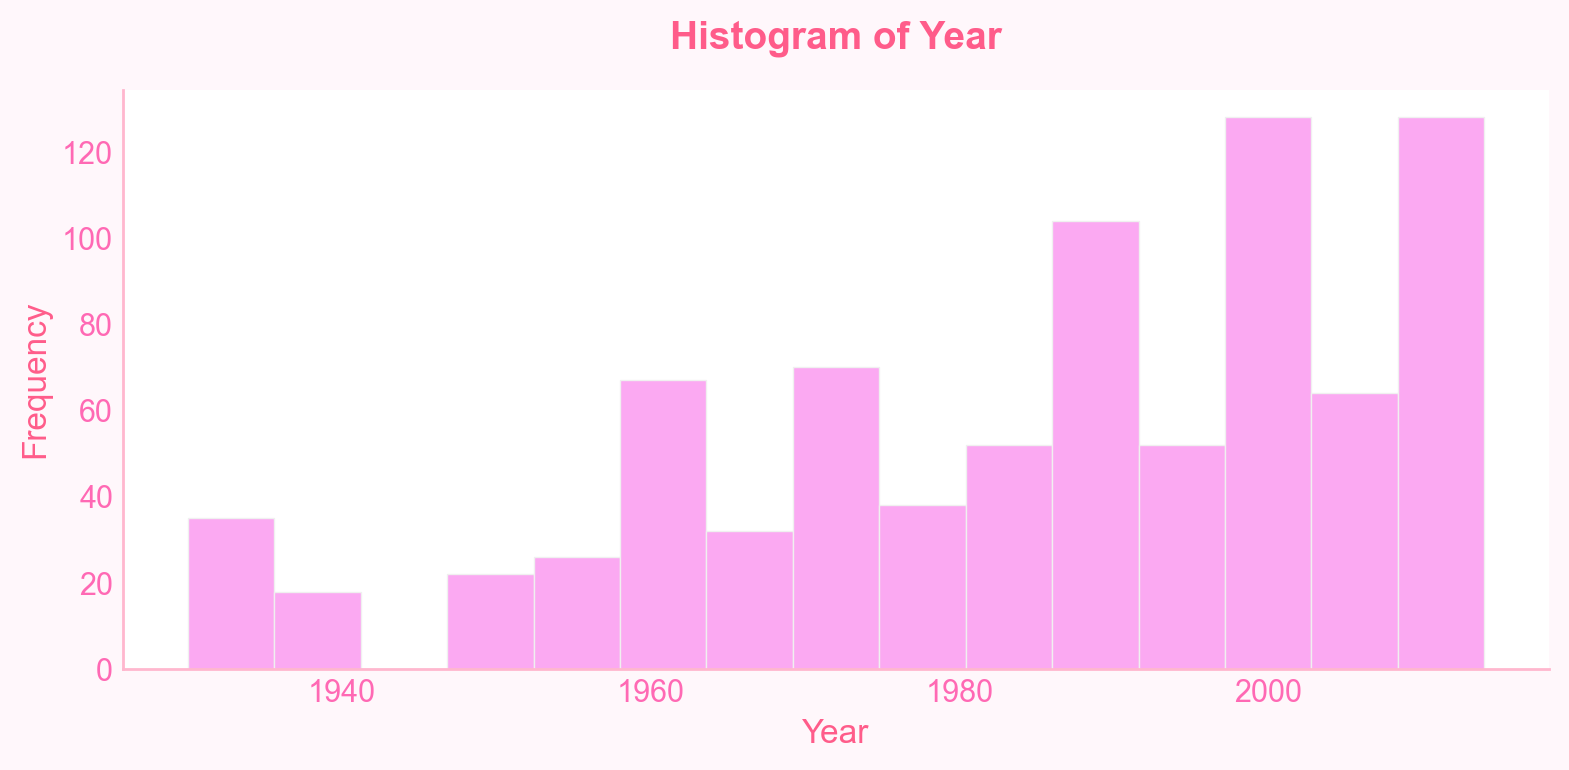

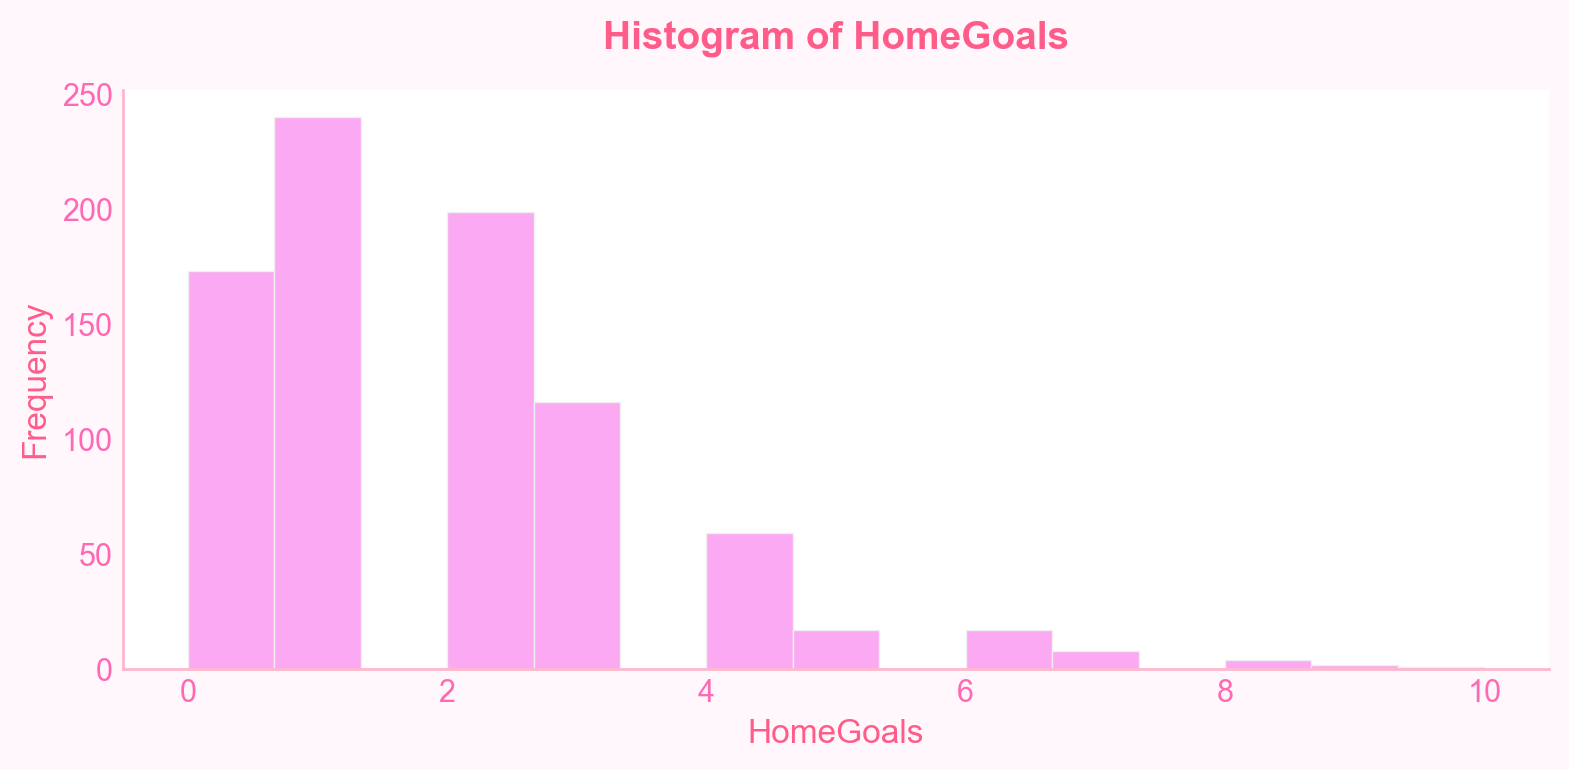

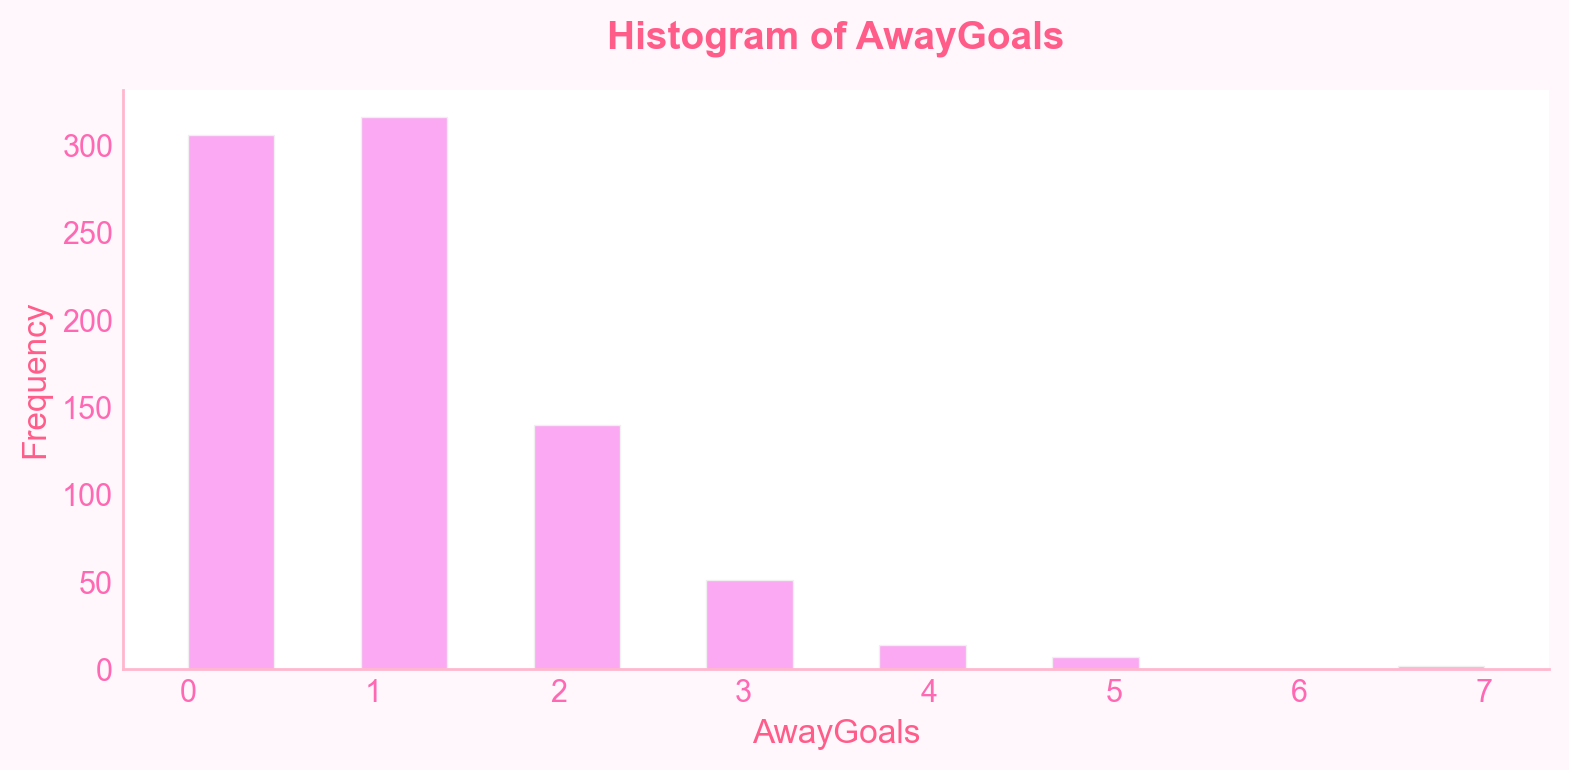

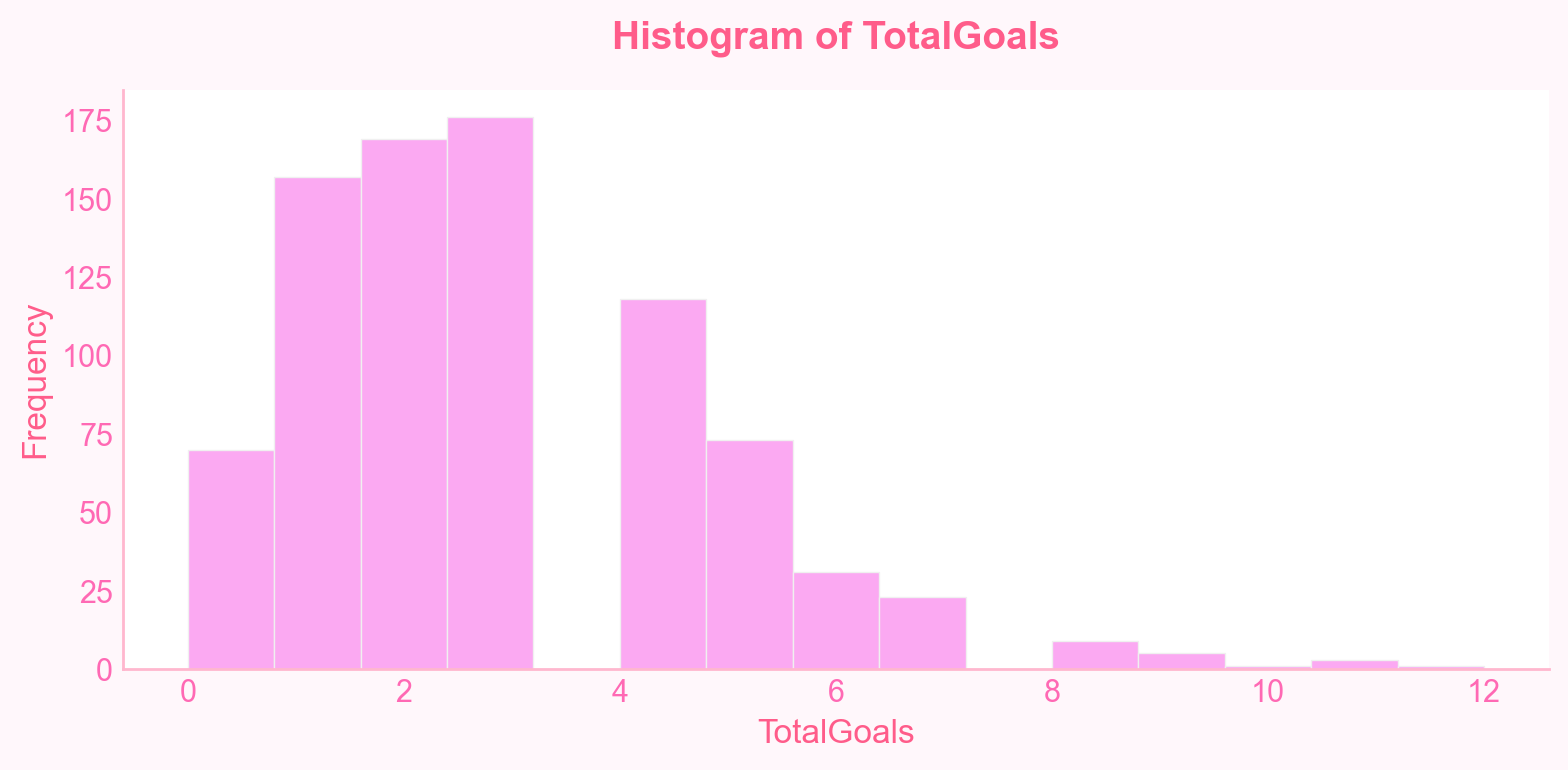

In [22]:
# histograms of all numerical columns
num_cols = df.select_dtypes(include=['number']).columns
for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x=col, bins=15, kde=False, color="#fa85ed", alpha=0.7)
    plt.title(f'Histogram of {col}', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.grid(False)
    plt.tight_layout()
    plt.show()

### Density Plots

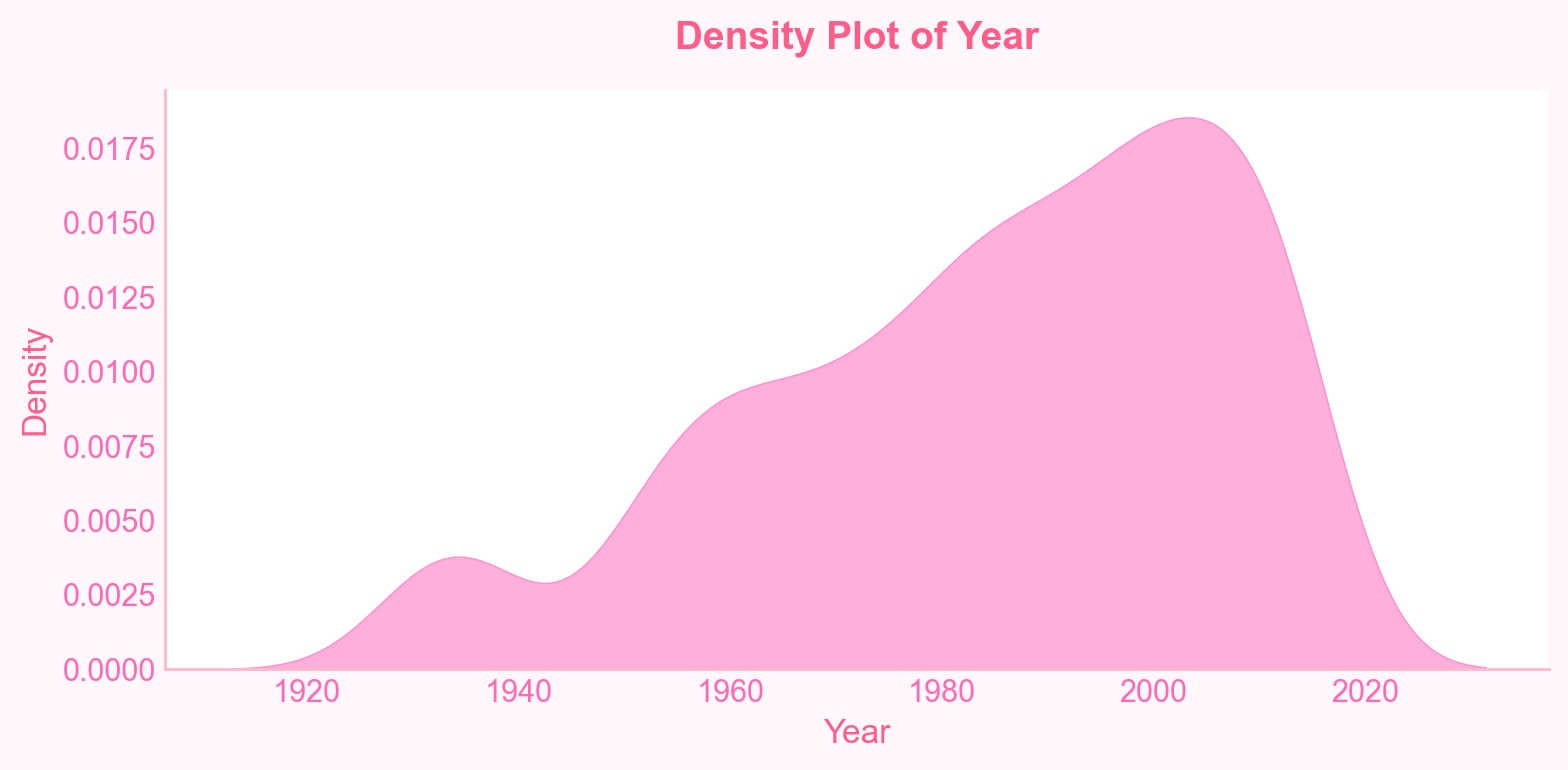

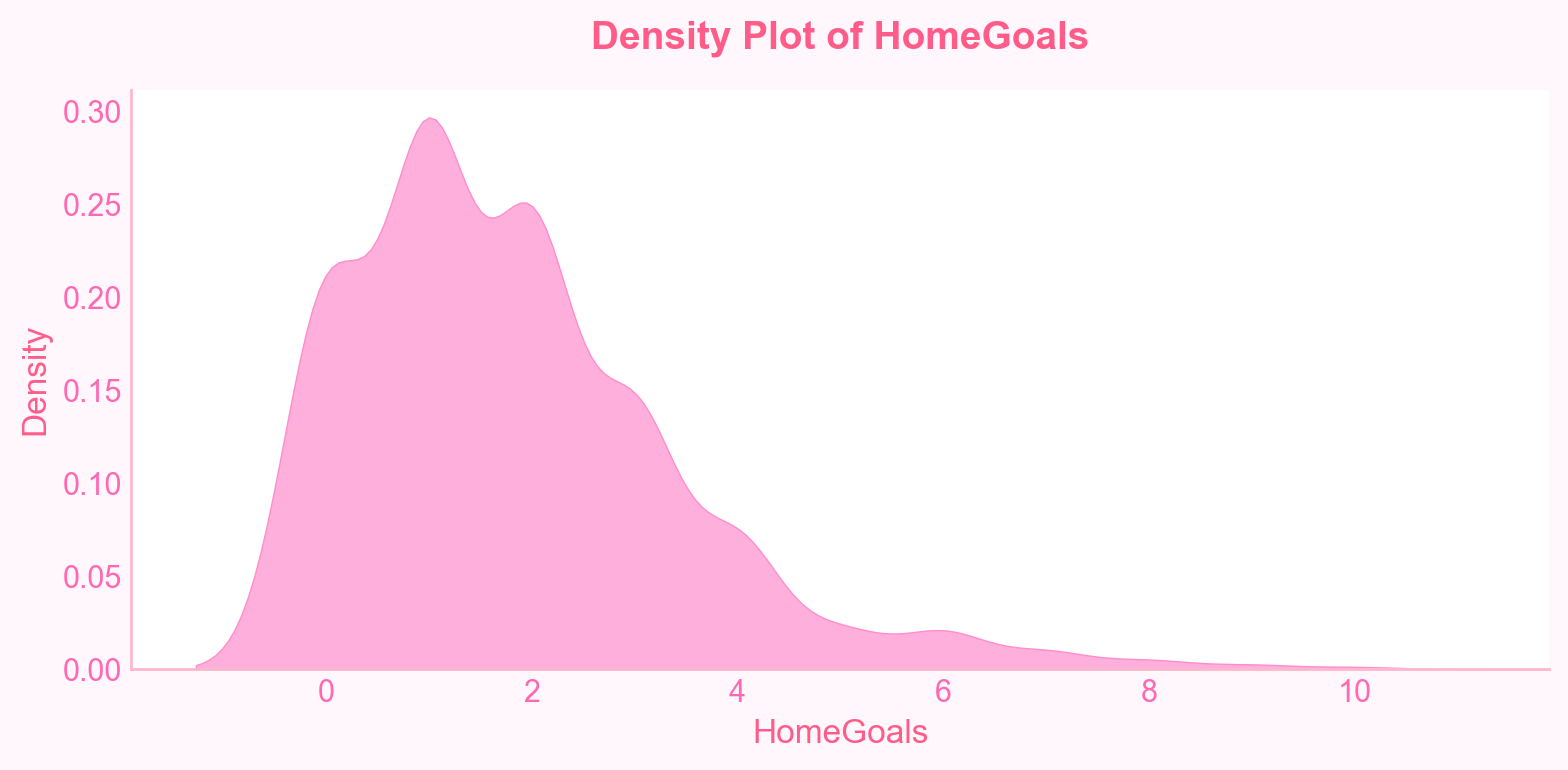

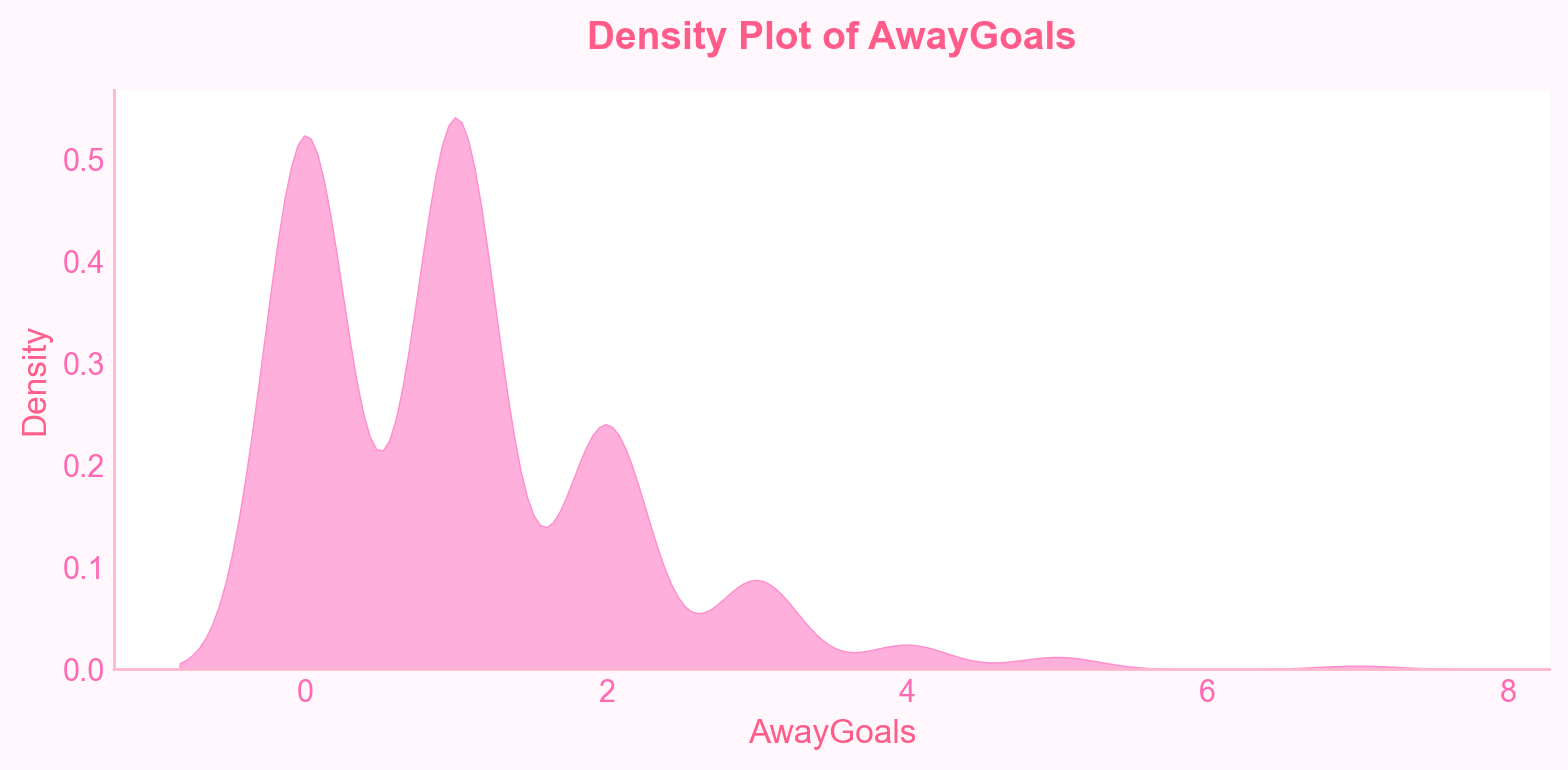

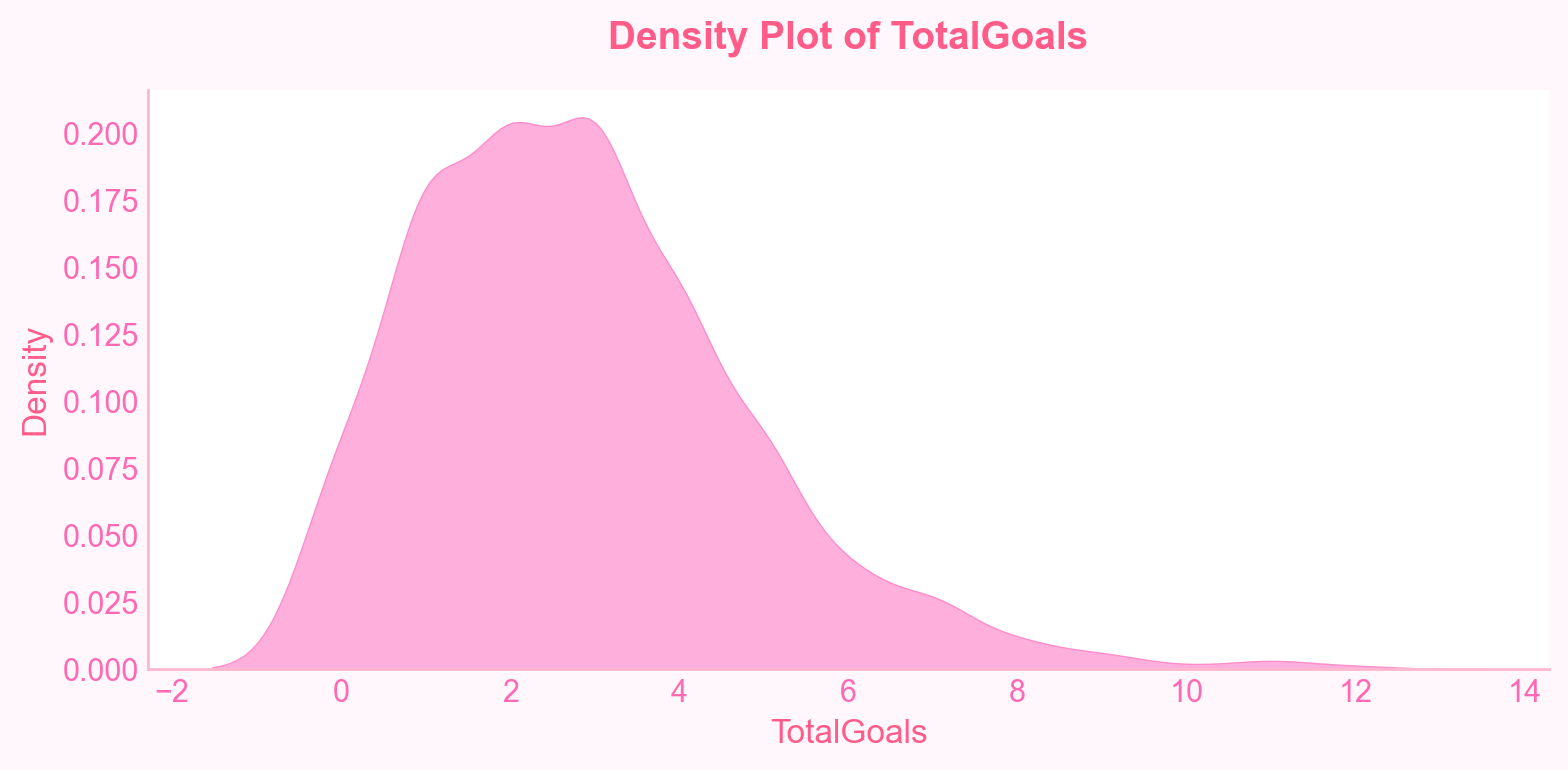

In [23]:
# density plots for numerical columns
for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.kdeplot(data=df, x=col, fill=True, color="#FF8DCC", alpha=0.7)
    plt.title(f'Density Plot of {col}', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.grid(False)
    plt.tight_layout()
    plt.show()

### Boxplots

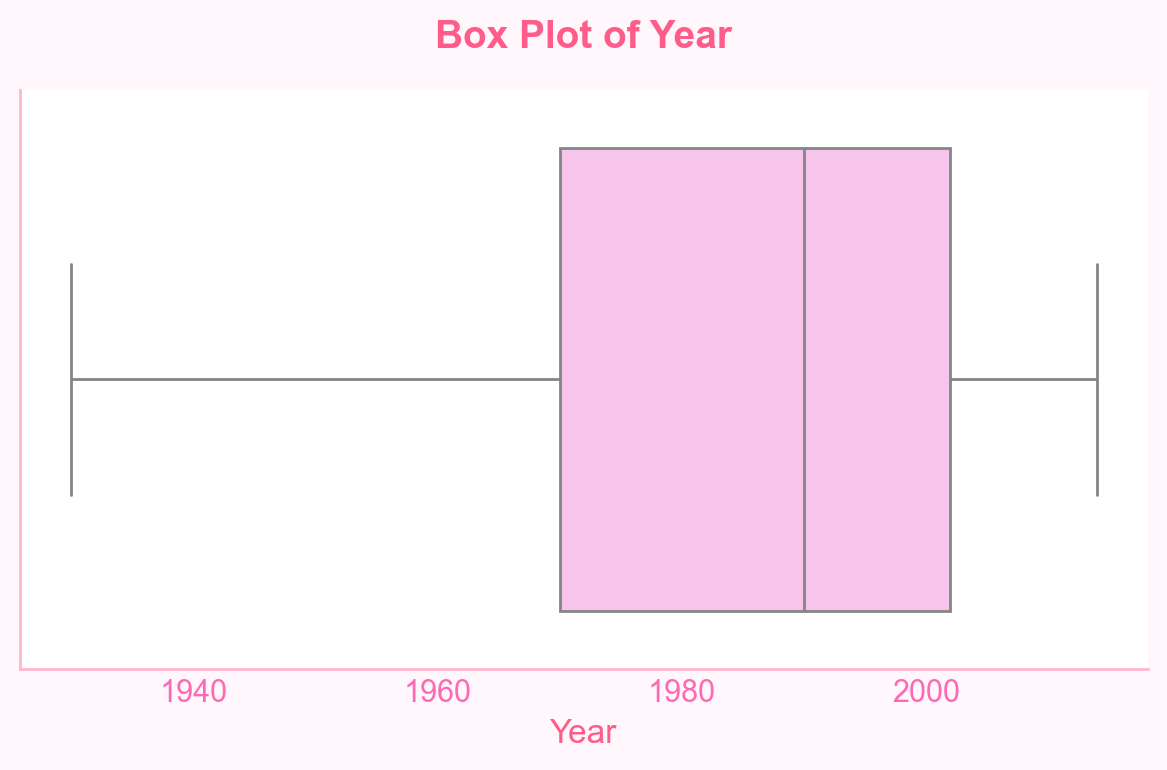

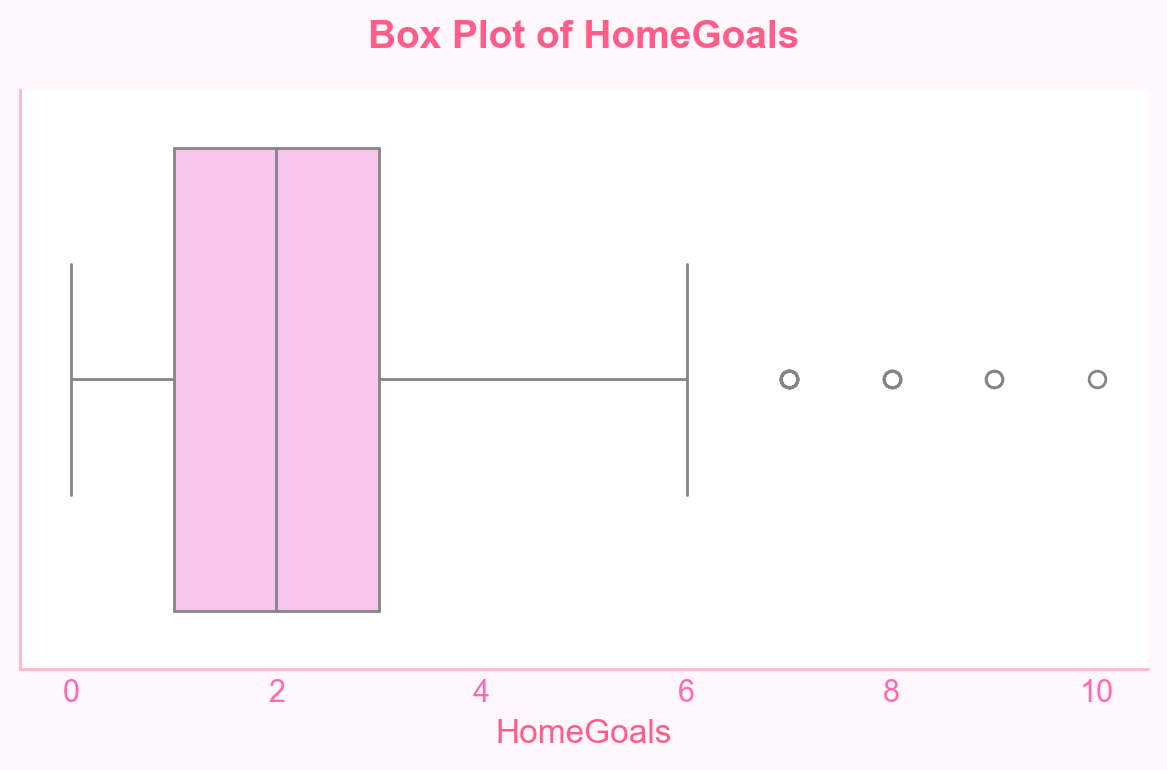

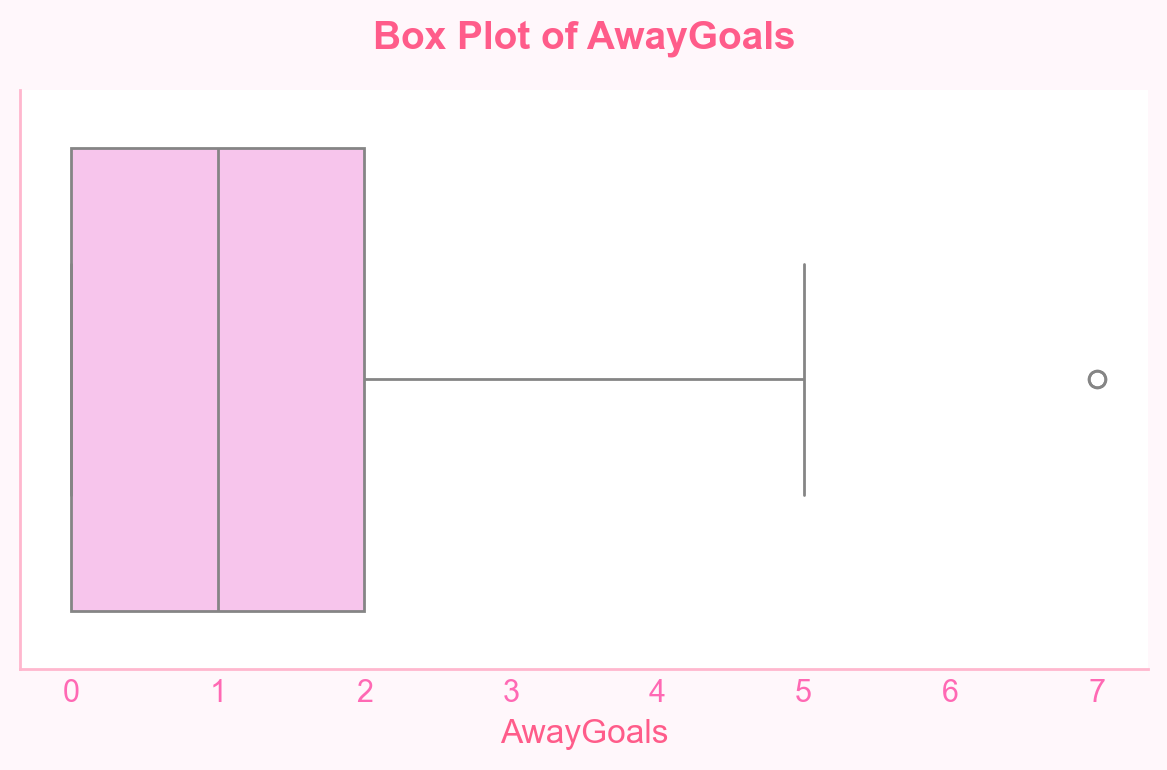

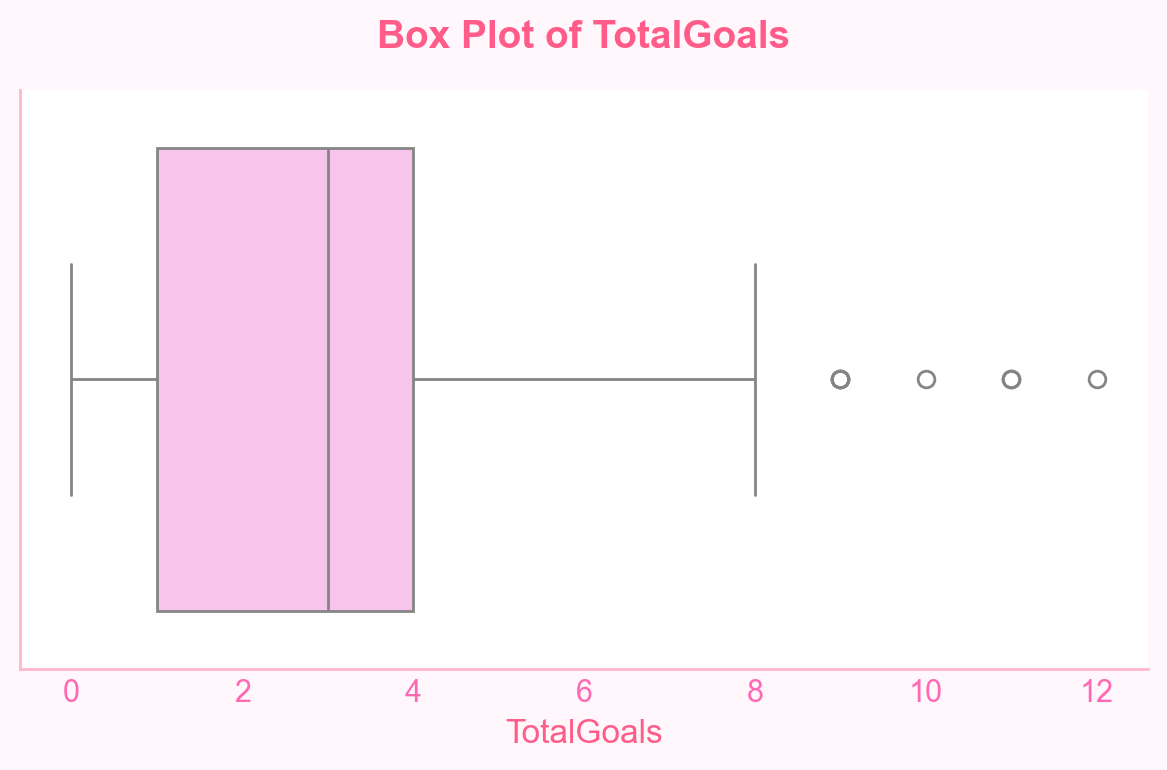

In [24]:
# box plots of all numerical columns
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col], color="#FFBDF1")
    plt.title(f'Box Plot of {col}', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.grid(False)
    plt.tight_layout()
    plt.show()

## Bivariate Analysis

### Scatterplots

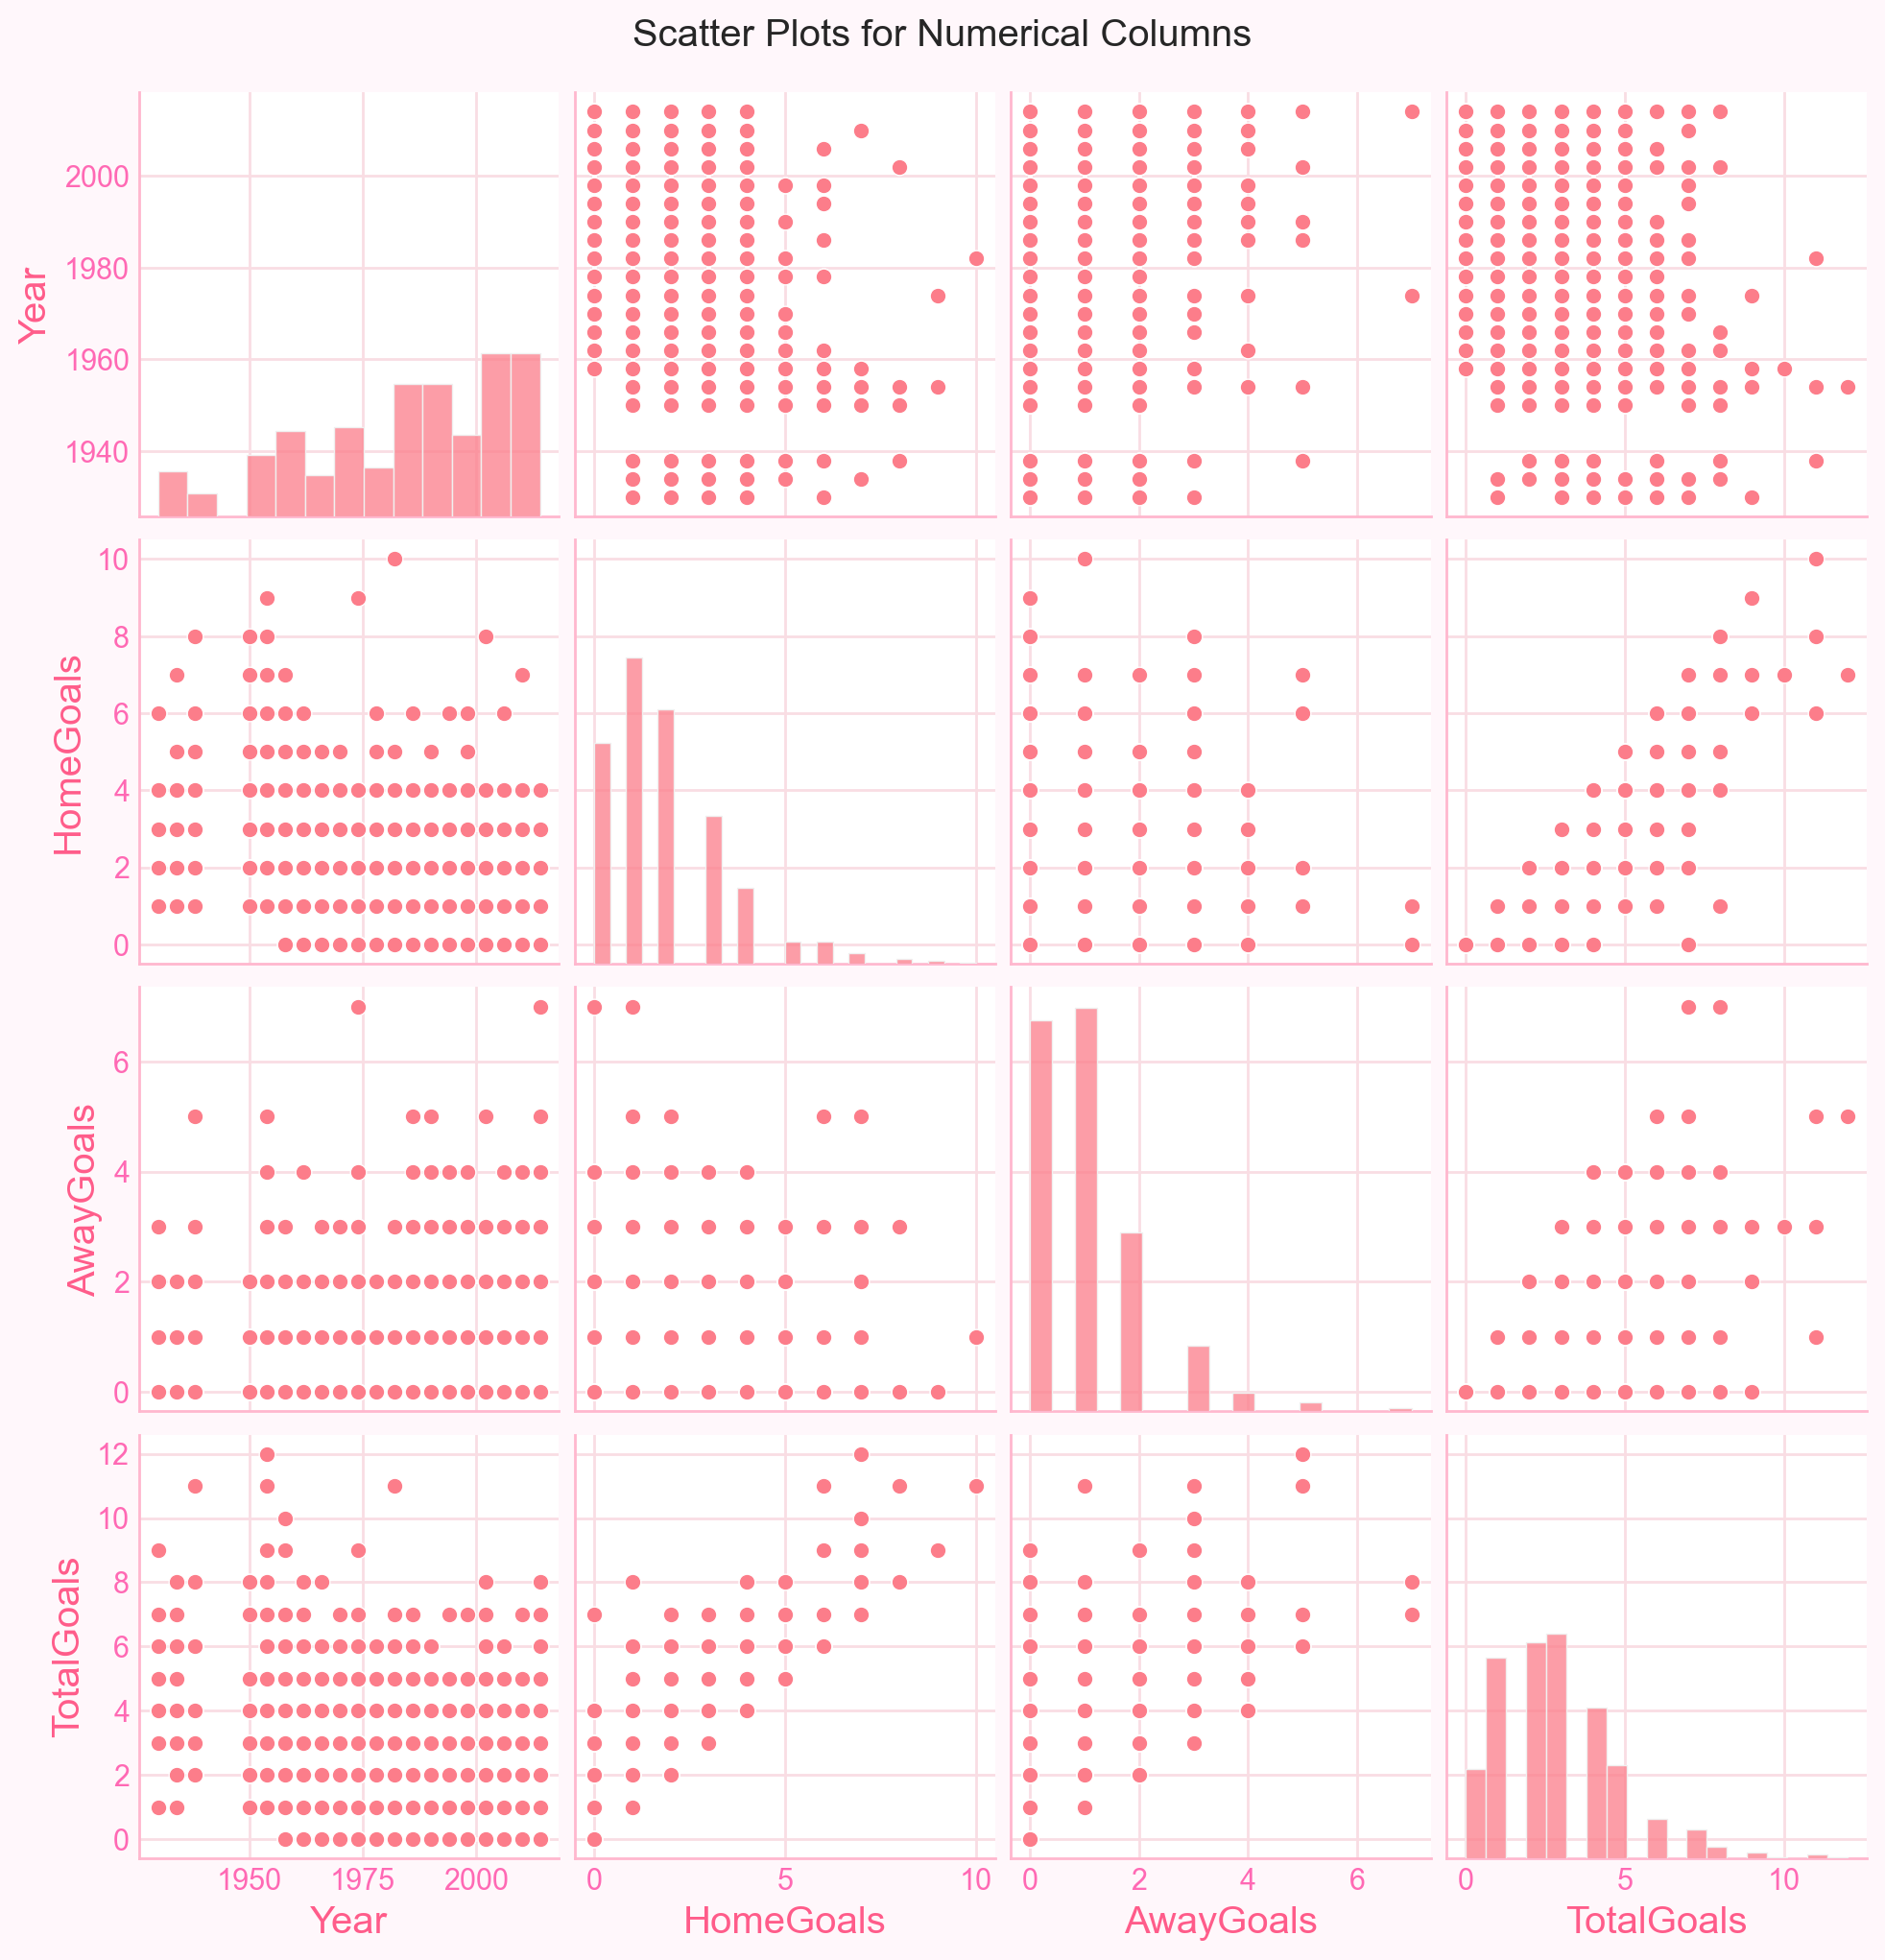

In [25]:

sns.pairplot(df[num_cols])
plt.suptitle("Scatter Plots for Numerical Columns", y=1.02)
plt.show()

### Correlation Matrix

In [26]:
corr = df[num_cols].corr()
print(corr)

             Year  HomeGoals  AwayGoals  TotalGoals
Year        1.000     -0.378      0.077      -0.271
HomeGoals  -0.378      1.000      0.015       0.836
AwayGoals   0.077      0.015      1.000       0.560
TotalGoals -0.271      0.836      0.560       1.000


### Barcharts

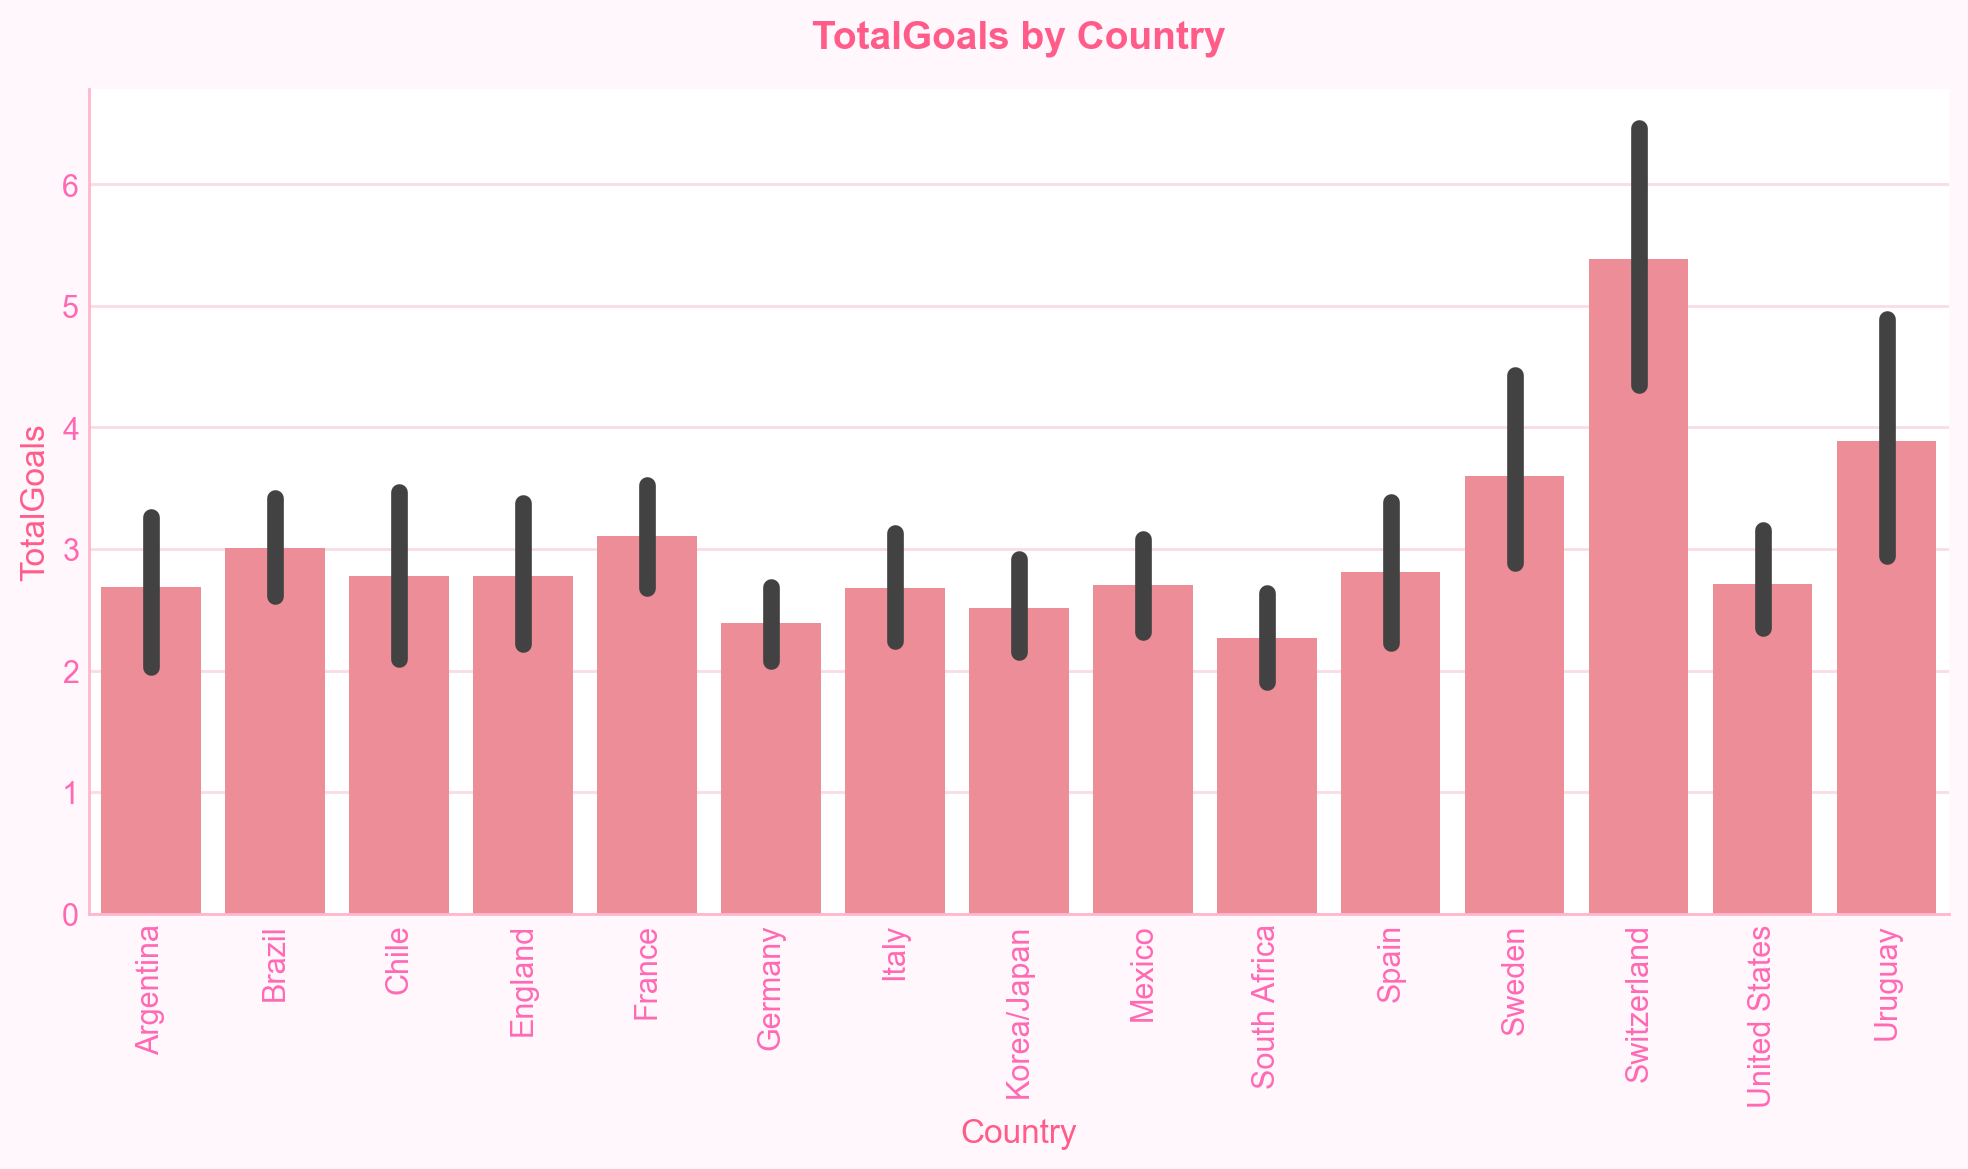

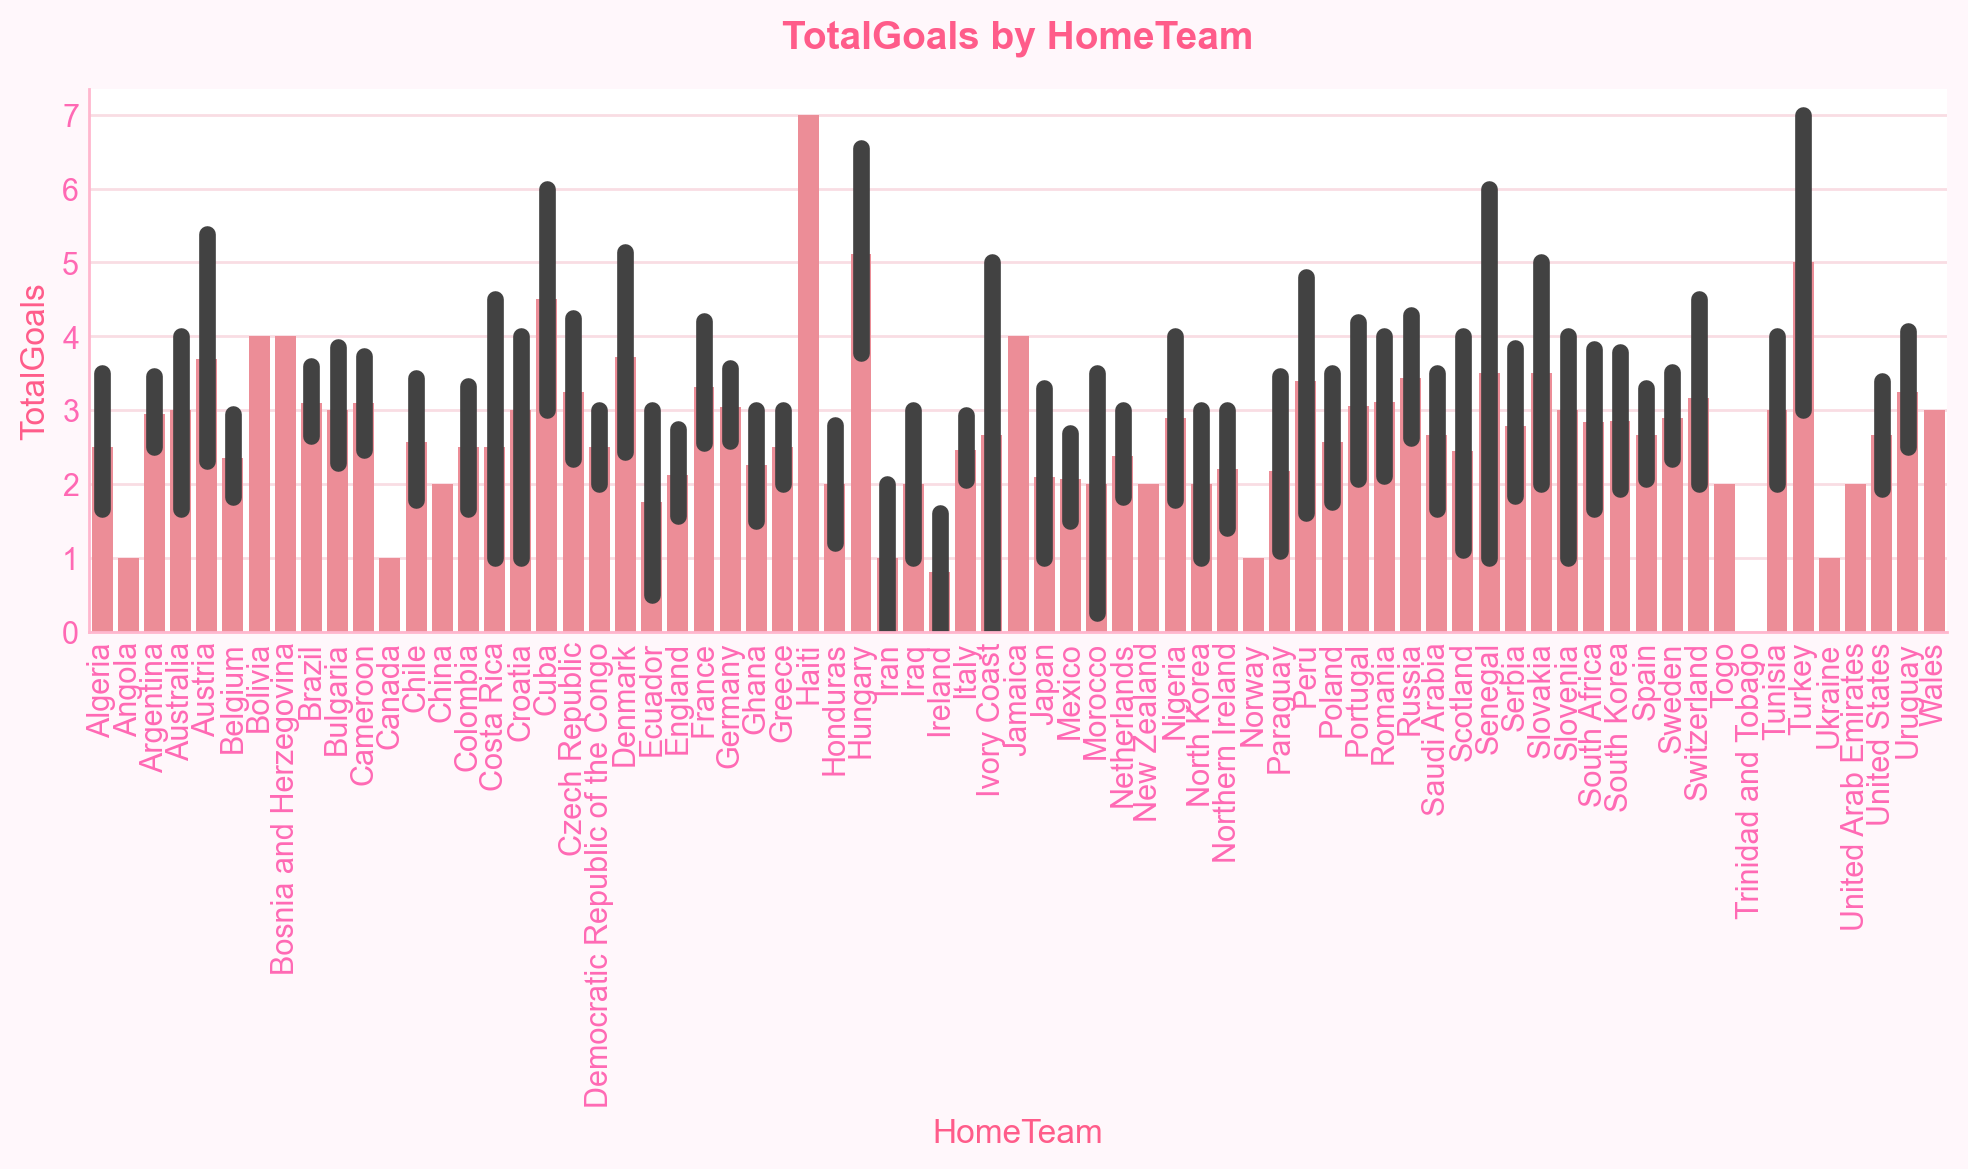

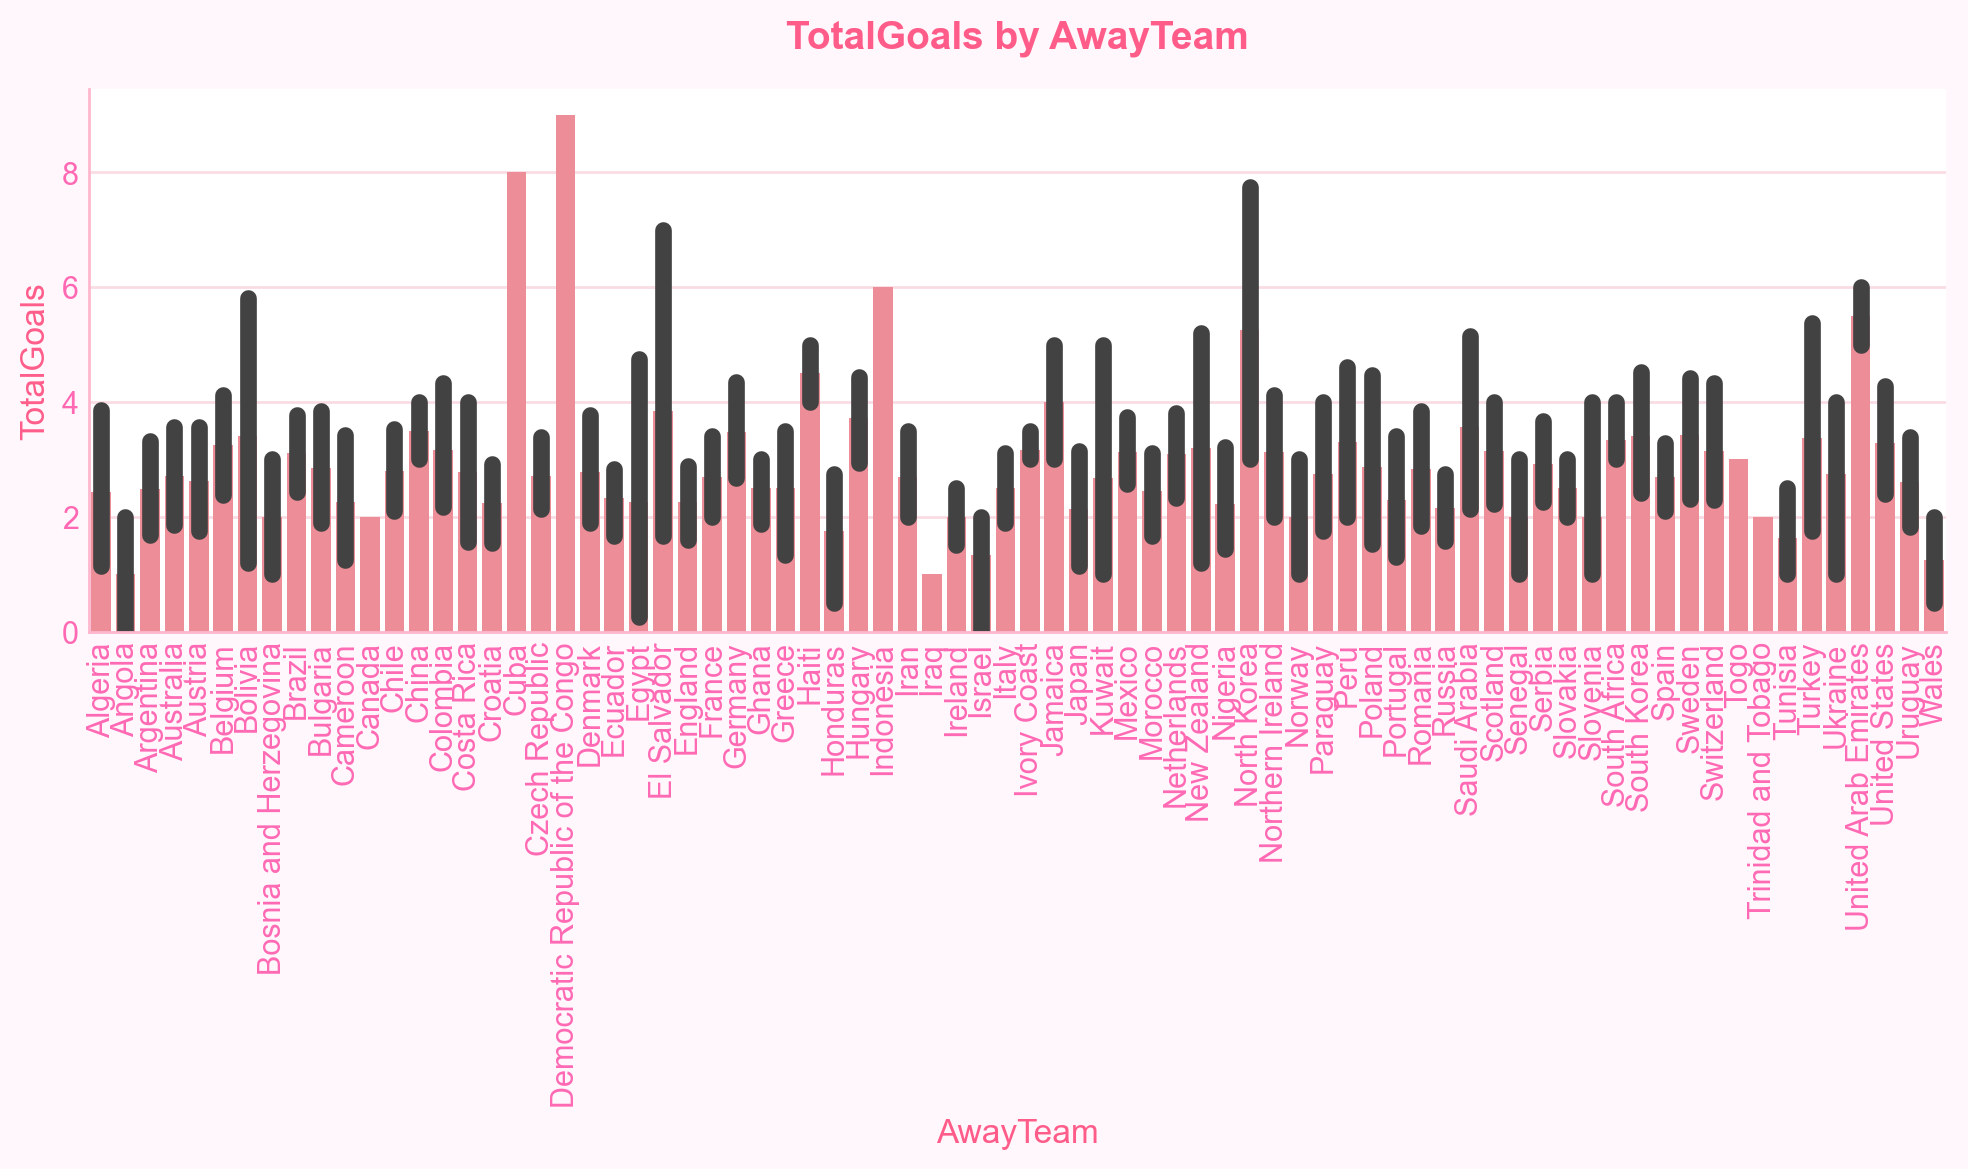

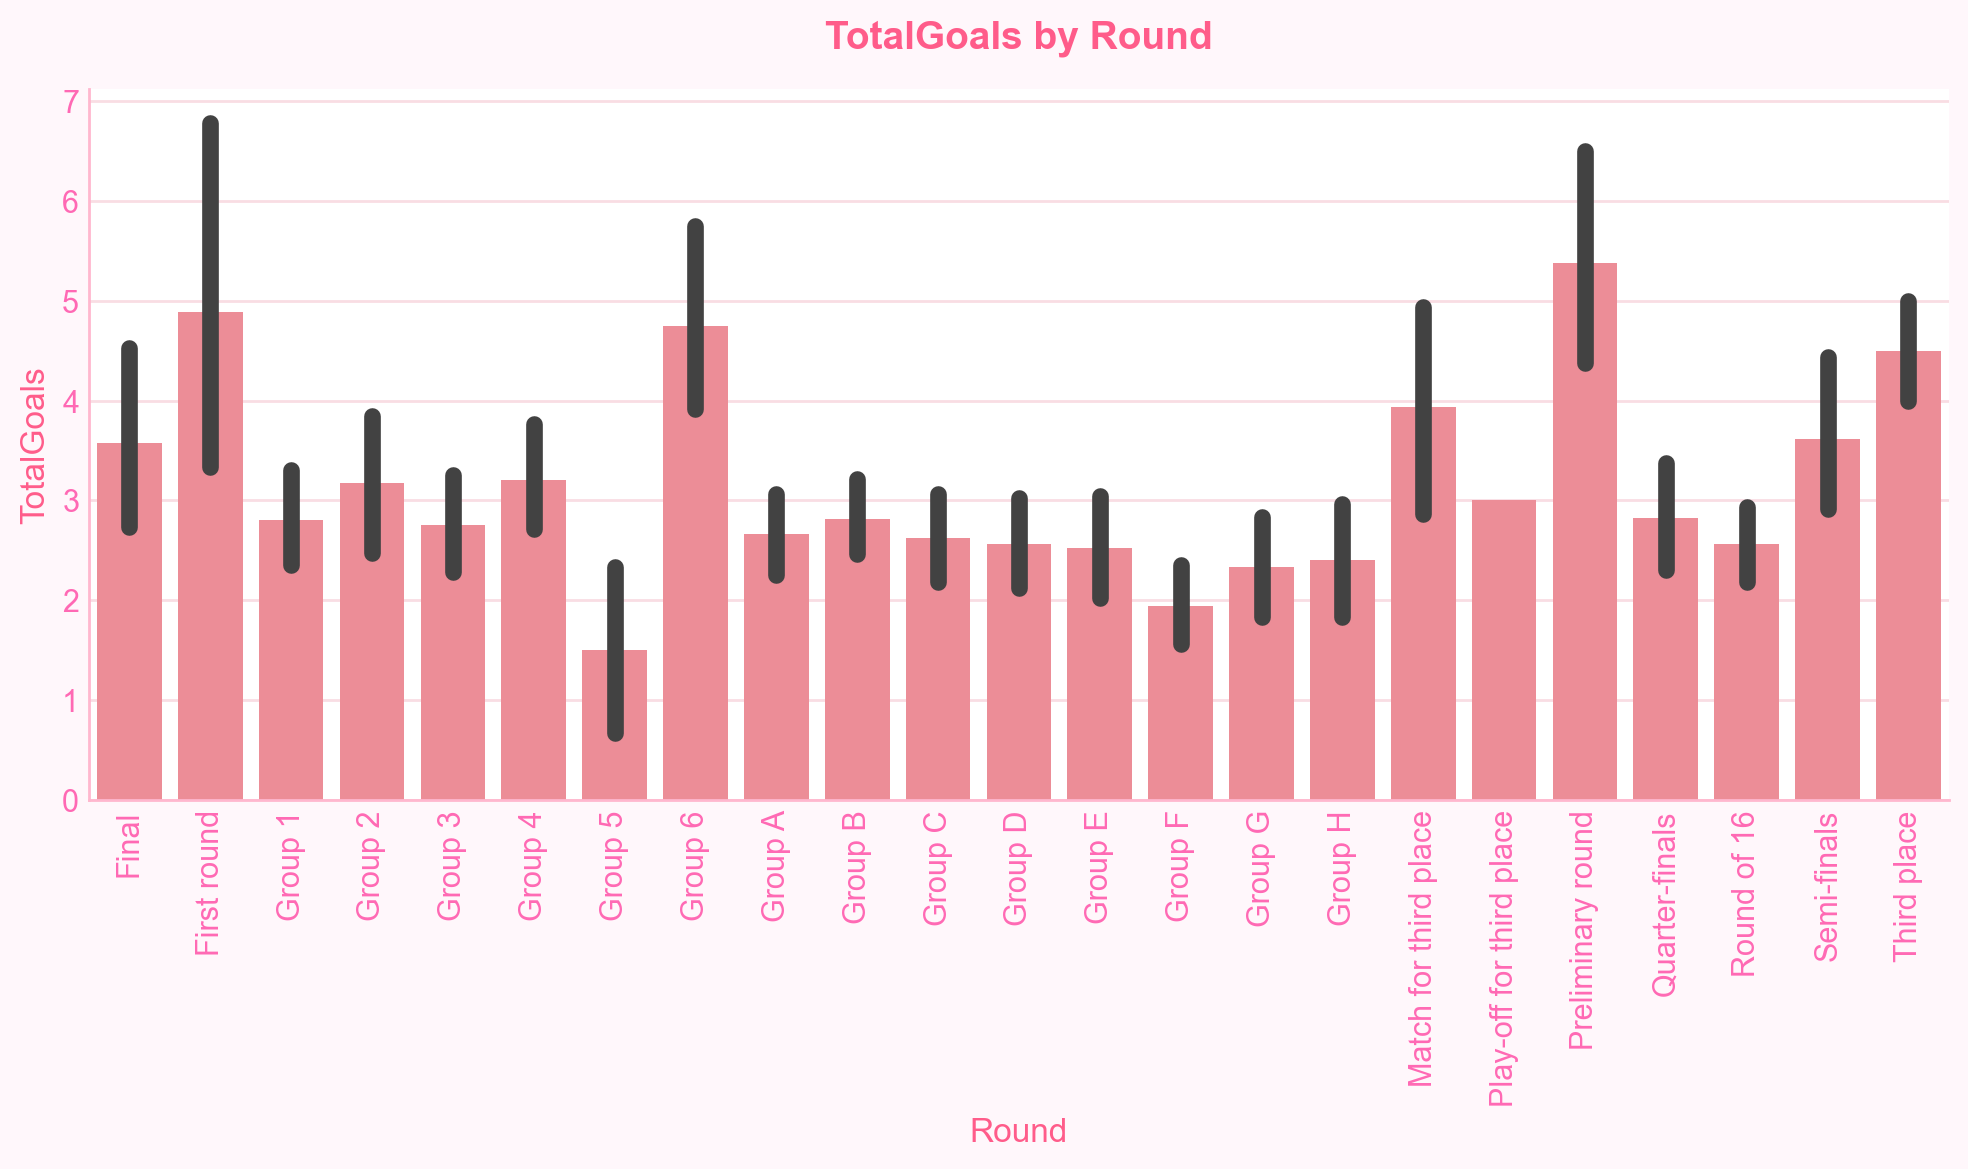

In [27]:
# total goal bar graphs with each category
categorical_cols_barchart = [ 'Country', 'HomeTeam', 'AwayTeam', 'Round']
numeric_col = 'TotalGoals'
for col in categorical_cols_barchart:
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df, x=col, y=numeric_col)
    plt.title(f'{numeric_col} by {col}', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel(numeric_col, fontsize=12)
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

---

## Multivariate Analysis

### Scatter Plot Matrix

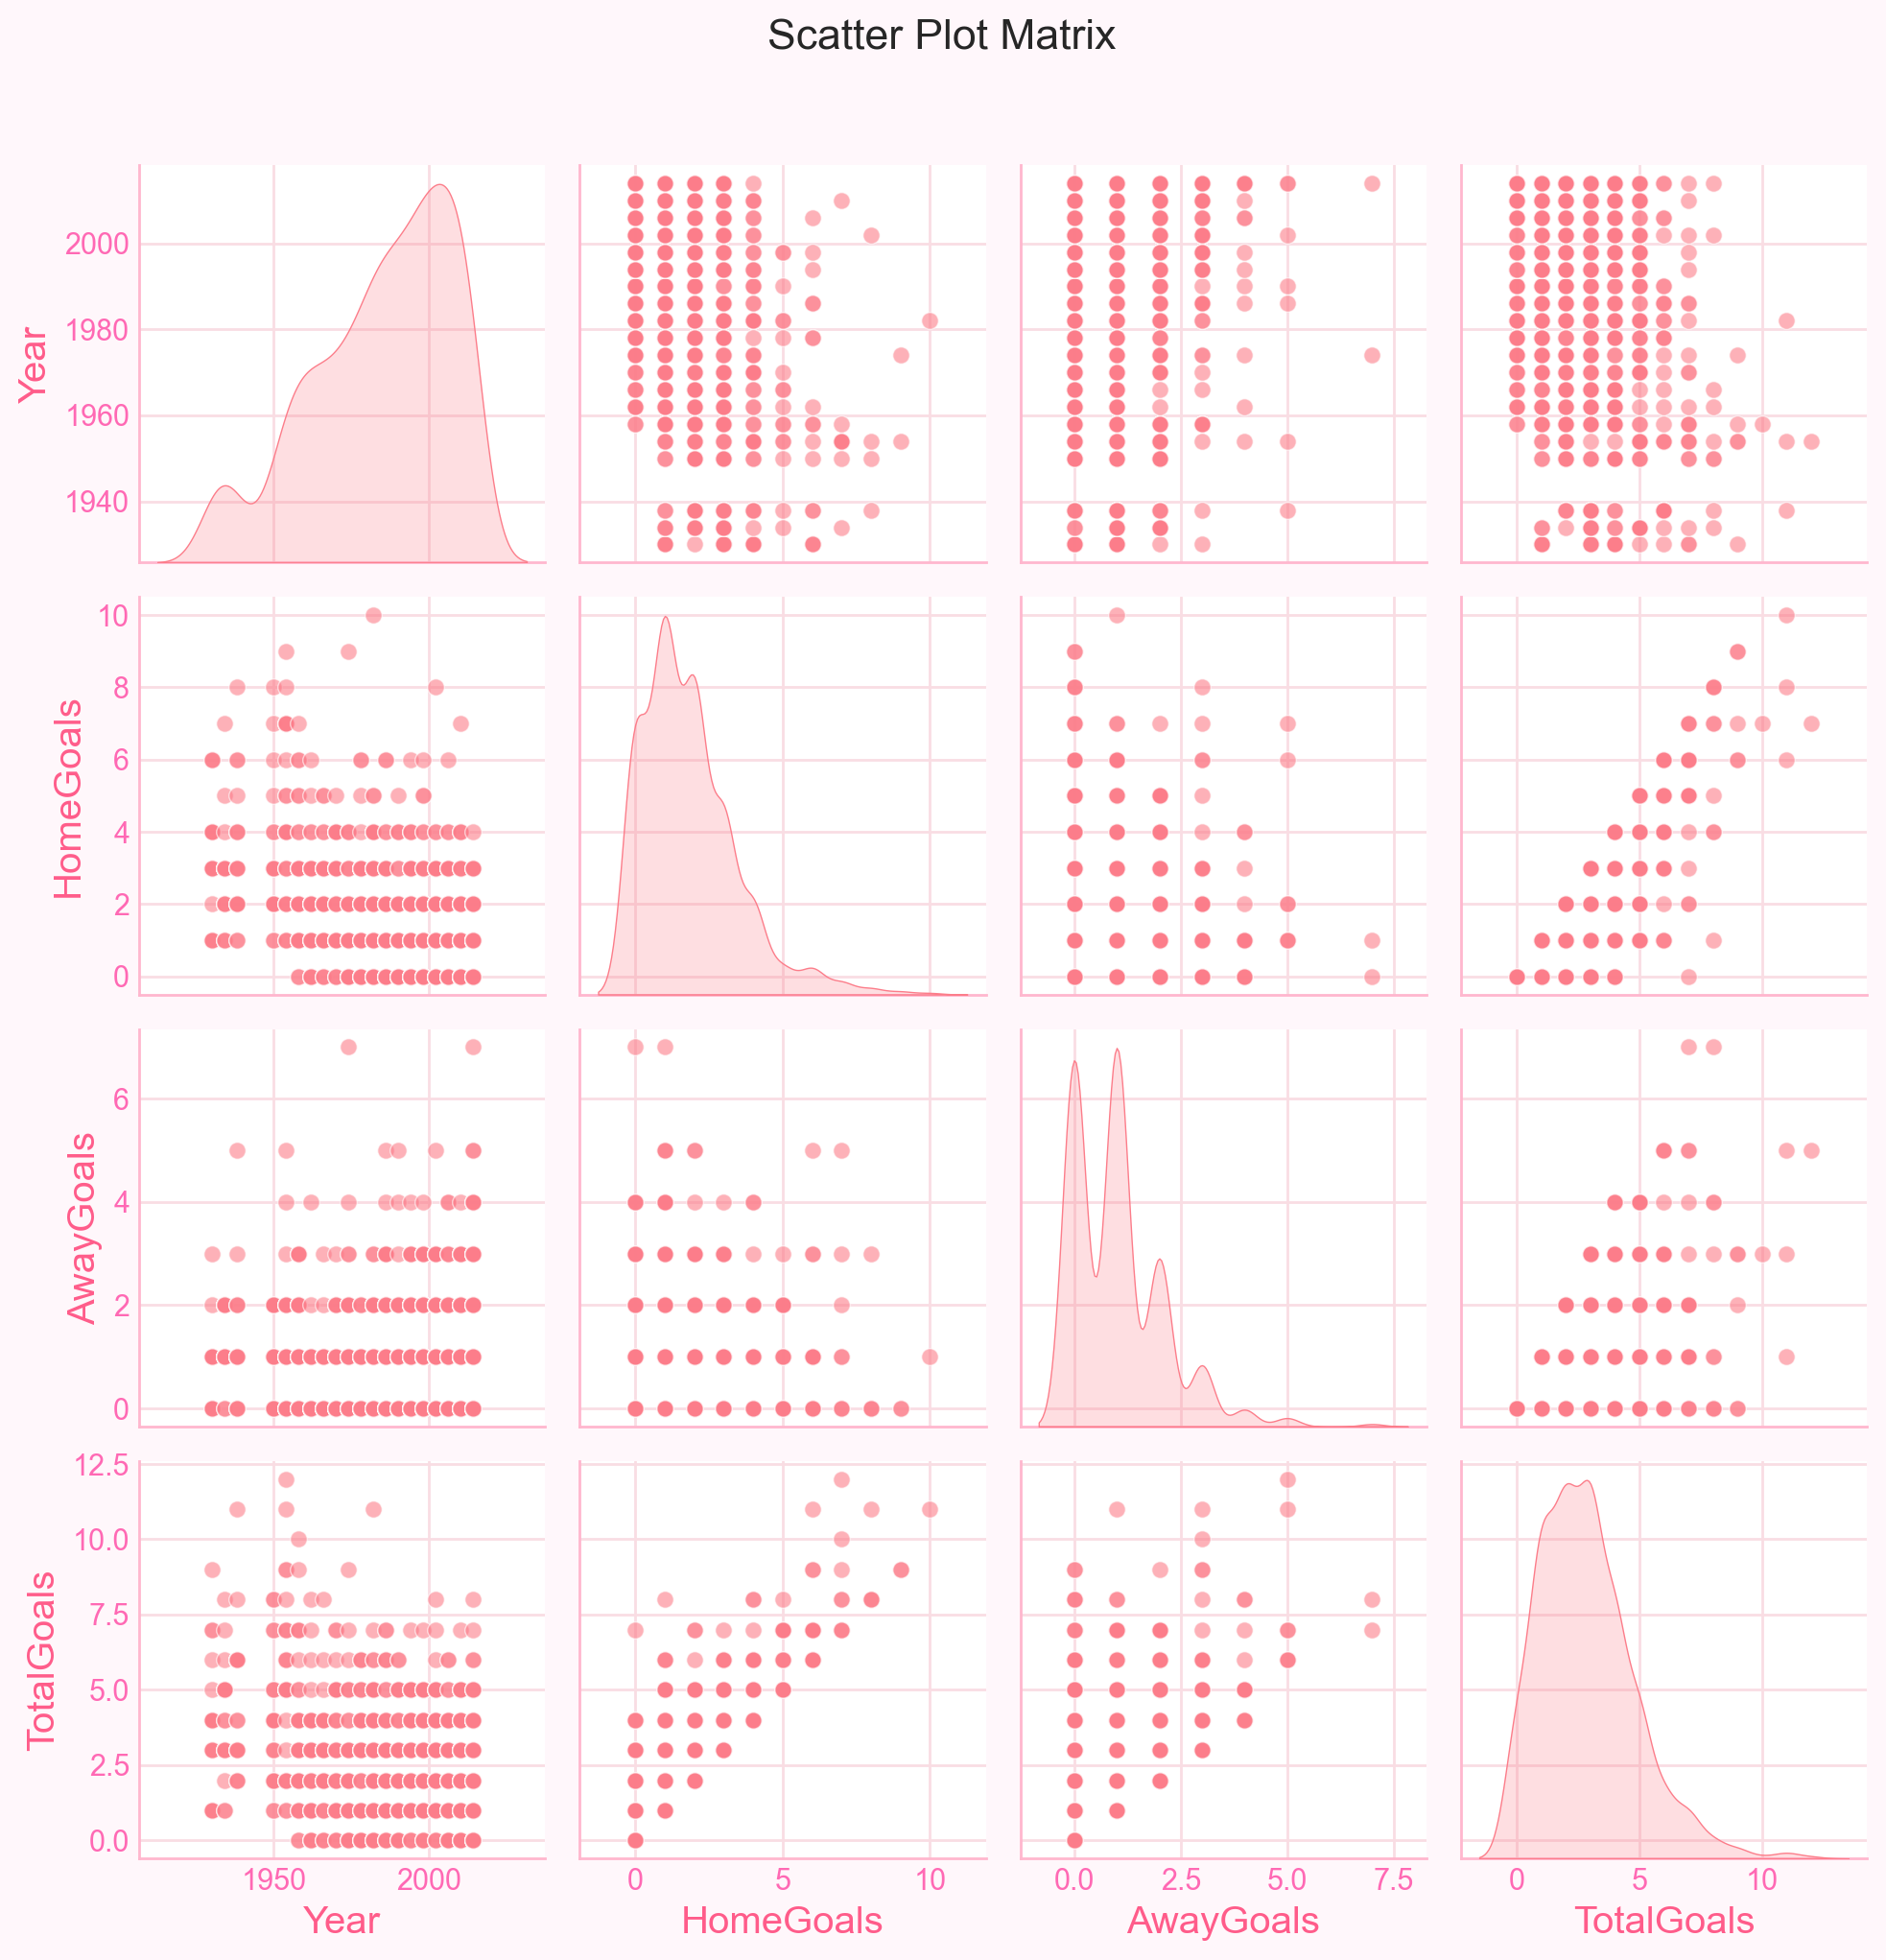

In [28]:
# Scatter plot matrix for numerical columns
sns.pairplot(df[num_cols], diag_kind="kde", kind="scatter",
             plot_kws={"alpha": 0.6, "s": 40})
plt.suptitle("Scatter Plot Matrix", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

### Parallel Coordinates plot

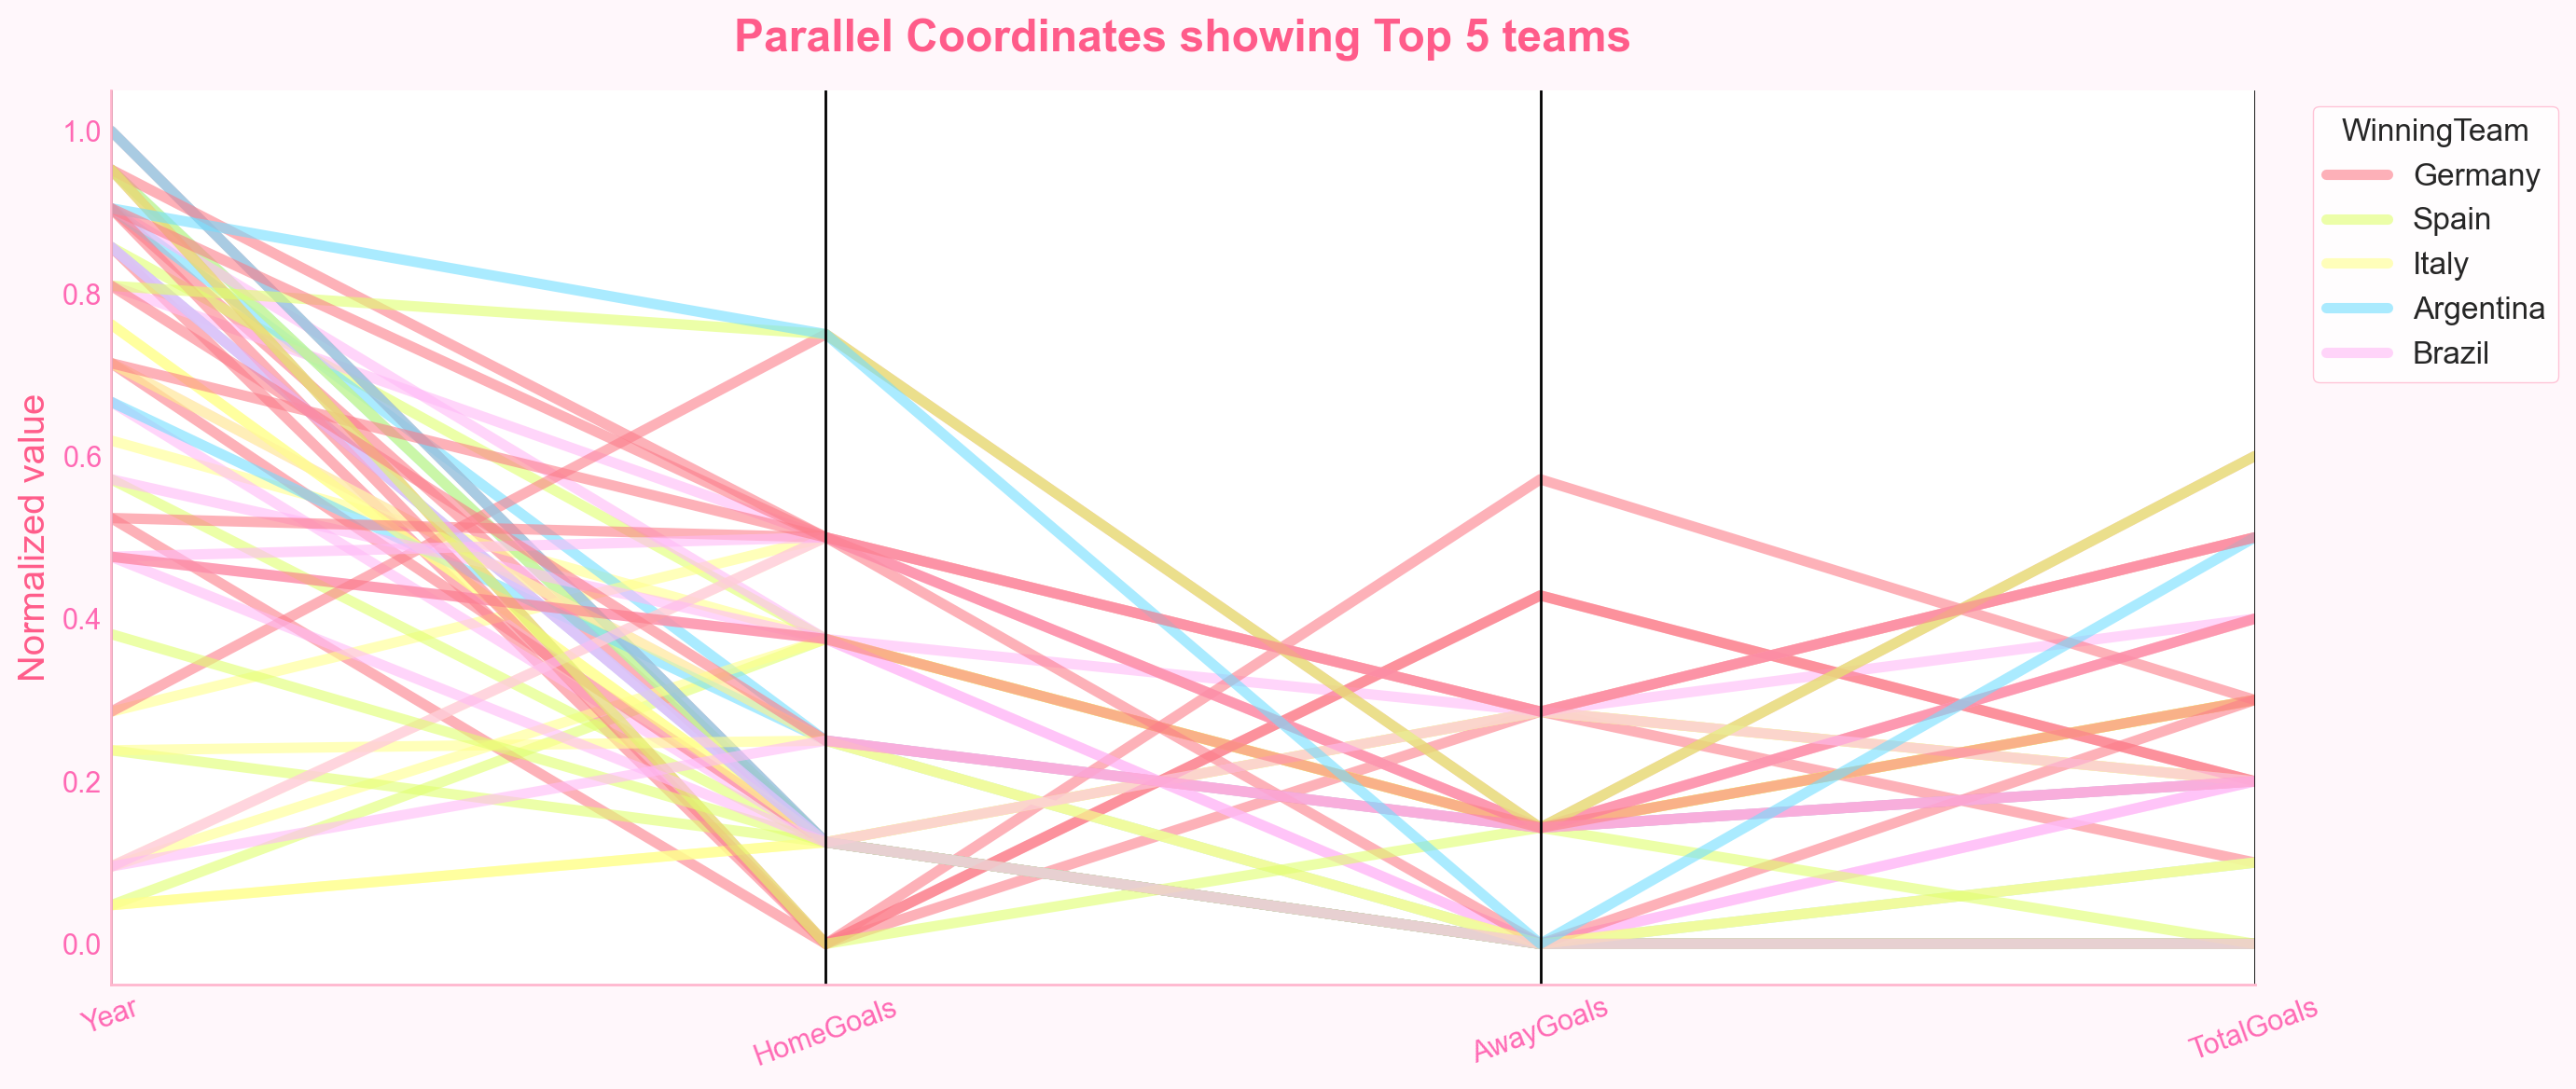

In [29]:
from pandas.plotting import parallel_coordinates


# numeric columns to plot 
cols = list(num_cols)  
class_col = 'WinningTeam'
# pick top 5 teams
top_teams = df[class_col].value_counts().drop(labels=['Draw'], errors='ignore').nlargest(5).index.tolist()

df_pc = df[df[class_col].isin(top_teams)].copy()

# normalize numeric columns to [0,1] so axes are comparable
df_pc_norm = df_pc.copy()
df_pc_norm[cols] = (df_pc_norm[cols] - df_pc_norm[cols].min()) / (df_pc_norm[cols].max() - df_pc_norm[cols].min())

num_of_rows = 50
if len(df_pc_norm) > num_of_rows:
    df_pc_norm = df_pc_norm.sample(num_of_rows, random_state=42).reset_index(drop=True)

plt.figure(figsize=(14, 6))
parallel_coordinates(
    df_pc_norm[[class_col] + cols],
    class_col,
    color=sns.color_palette(kawaii_palette),
    alpha=0.6
)
plt.title("Parallel Coordinates showing Top 5 teams")
plt.ylabel("Normalized value")
plt.xticks(rotation=20)
plt.legend(title=class_col, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Trellis plot

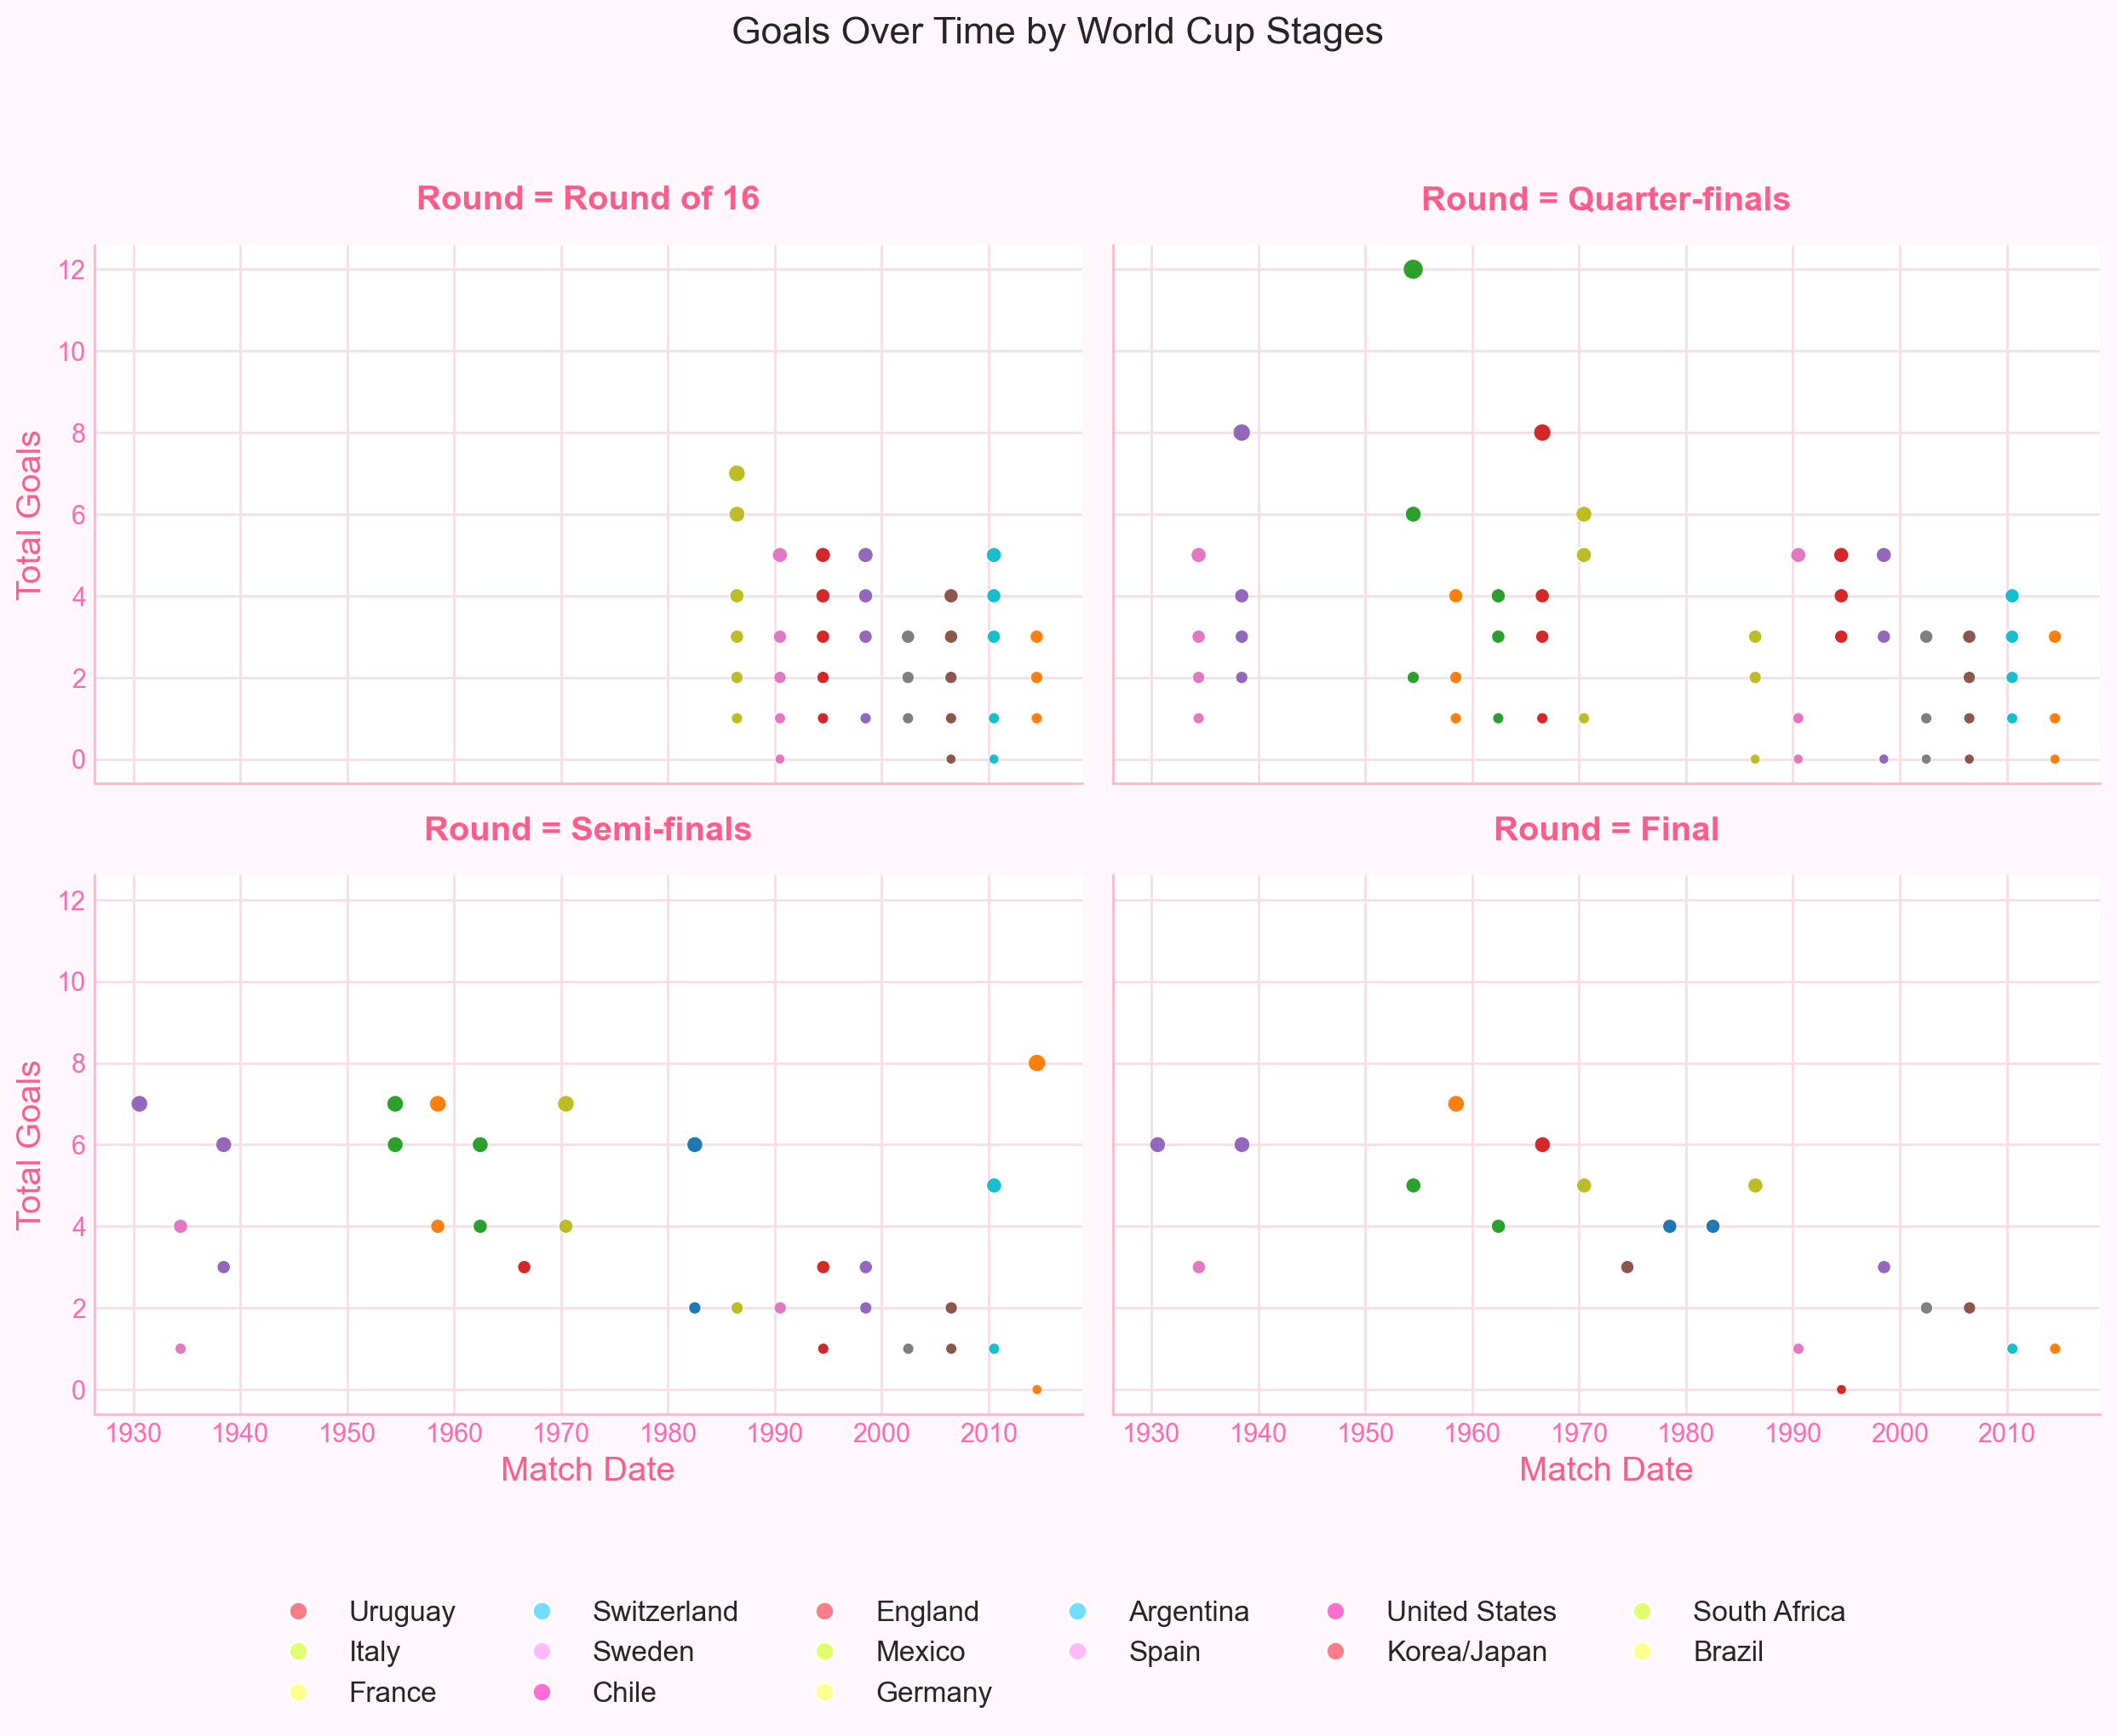

In [30]:
round_order = ['Round of 16', 'Quarter-finals', 'Semi-finals', 'Final']

df_plot = df[df['Round'].isin(round_order)].copy()
df_plot['Round'] = pd.Categorical(df_plot['Round'], categories=round_order, ordered=True)


g = sns.relplot(
    data=df_plot,
    x='Date', y='TotalGoals',
    col='Round', hue='Country',  
    size='TotalGoals',
    col_wrap=2, kind='scatter',
    height=4.2, aspect=1.5,
    palette='tab10', legend=False
)

from matplotlib.lines import Line2D
# order of labels used in legend
hue_labels = df_plot['Country'].dropna().unique().tolist()
palette_colors = sns.color_palette(kawaii_palette, n_colors=len(hue_labels))
proxy_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=8, linestyle='')
    for c in palette_colors
]


g.fig.subplots_adjust(bottom=0.08)          # leave space for legend
ncols = min(6, len(hue_labels))             # columns in legend
g.fig.legend(proxy_handles, hue_labels, loc='lower center',
             ncol=ncols, frameon=False, bbox_to_anchor=(0.5, -0.15))

# Add big title and axis label
g.fig.suptitle("Goals Over Time by World Cup Stages", fontsize=16, y=1.05)
g.set_axis_labels("Match Date", "Total Goals")

plt.tight_layout()
plt.show()


### Heatmap

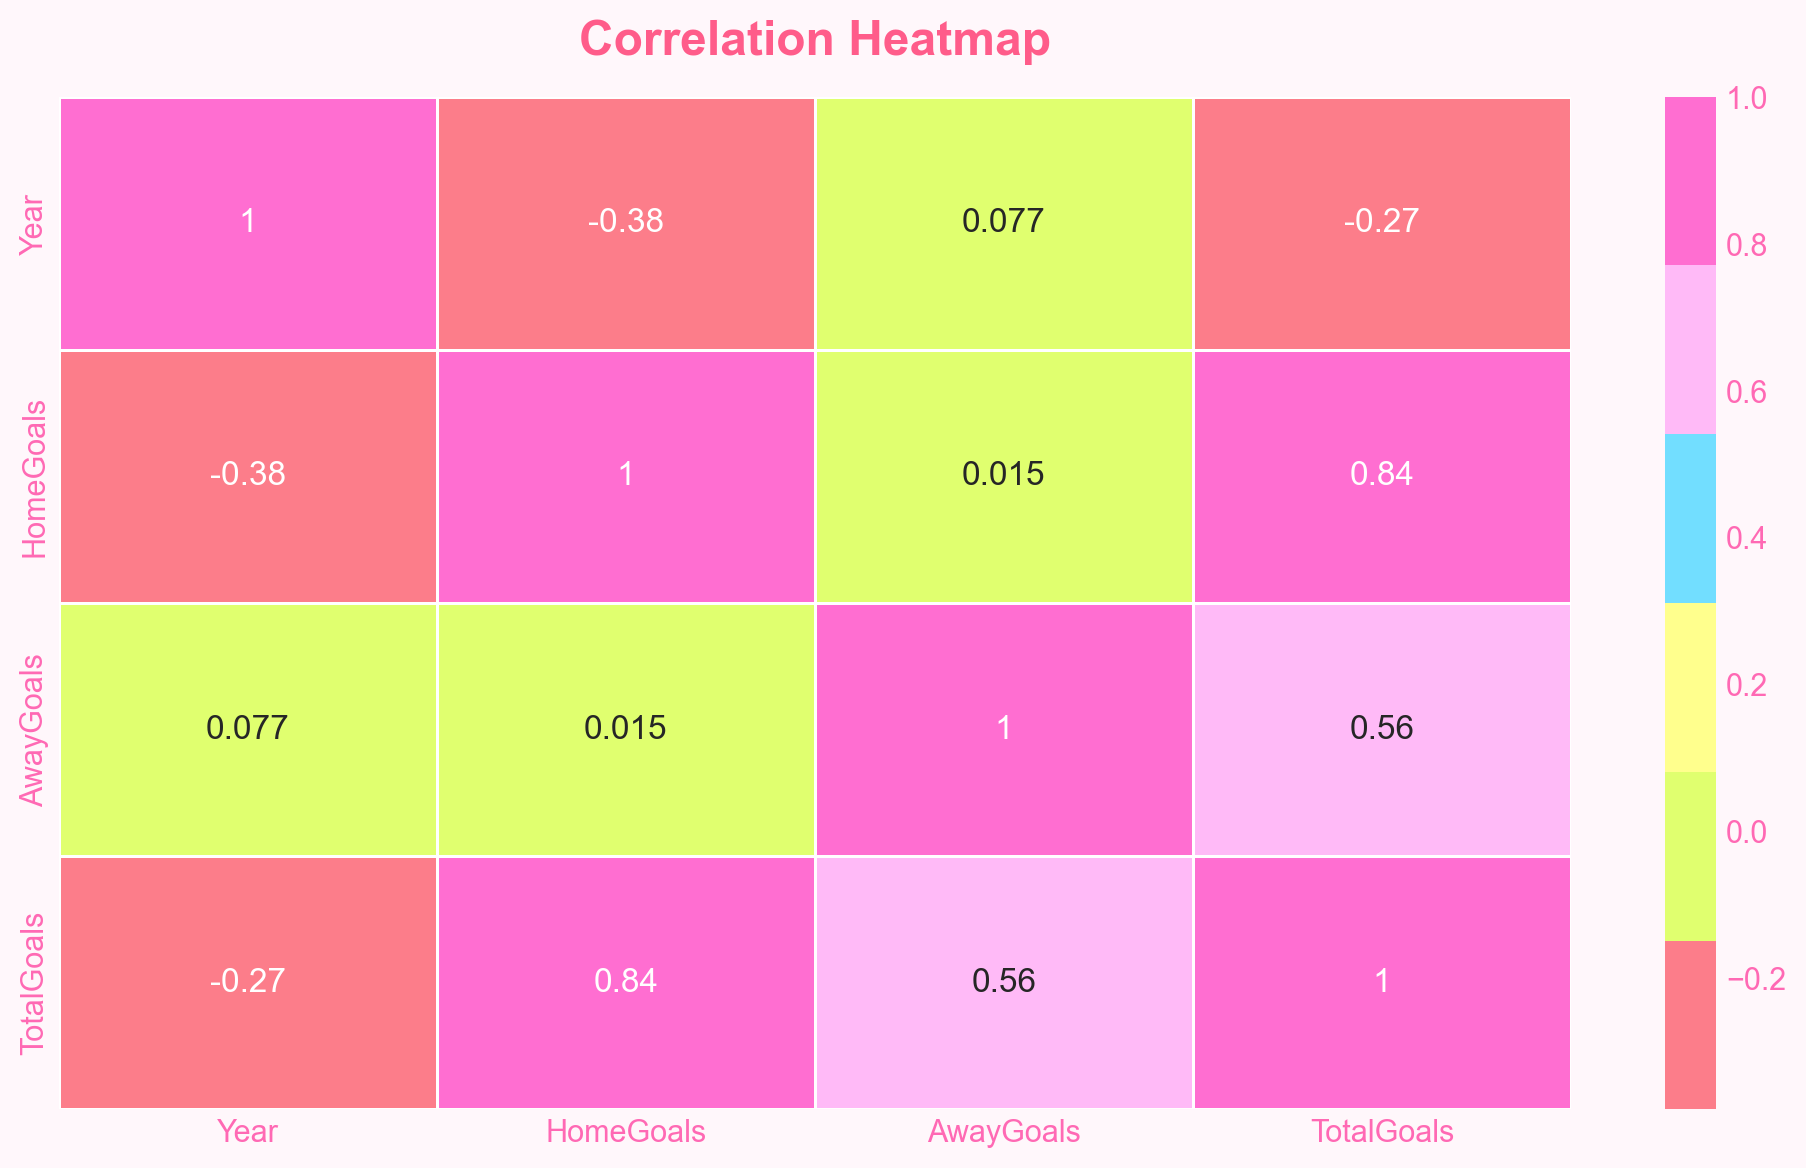

In [31]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap= kawaii_palette, linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

<div class="alert alert-danger">
Find all countries that participated in 2014 and then find their flags

In [32]:
# countries in 2014 in home team and away team
df_2014 = df[df['Year'] == 2014].copy()
countries_2014 = (df_2014['AwayTeam']).unique().tolist()
print(countries_2014)

['Croatia', 'Cameroon', 'Netherlands', 'Australia', 'Greece', 'Costa Rica', 'Italy', 'Japan', 'Ecuador', 'Honduras', 'Bosnia and Herzegovina', 'Portugal', 'Nigeria', 'United States', 'Algeria', 'Mexico', 'South Korea', 'Chile', 'Ivory Coast', 'England', 'France', 'Iran', 'Ghana', 'Russia', 'Spain', 'Brazil', 'Uruguay', 'Colombia', 'Argentina', 'Switzerland', 'Germany', 'Belgium']


In [33]:



df_2014 = df[df['Year'] == 2014].copy()


name_to_code = {
    'Croatia': 'hr',
    'Cameroon': 'cm',
    'Netherlands': 'nl',
    'Australia': 'au',
    'Greece': 'gr',
    'Costa Rica': 'cr',
    'Italy': 'it',
    'Japan': 'jp',
    'Ecuador': 'ec',
    'Honduras': 'hn',
    'Bosnia and Herzegovina': 'ba',
    'Portugal': 'pt',
    'Nigeria': 'ng',
    'United States': 'us',
    'Algeria': 'dz',
    'Mexico': 'mx',
    'South Korea': 'kr',
    'Chile': 'cl',
    'Ivory Coast': 'ci',  
    'England': 'gb',
    'France': 'fr',
    'Iran': 'ir',
    'Ghana': 'gh',
    'Russia': 'ru',
    'Spain': 'es',
    'Brazil': 'br',
    'Uruguay': 'uy',
    'Colombia': 'co',
    'Argentina': 'ar',
    'Switzerland': 'ch',
    'Germany': 'de',
    'Belgium': 'be'
}


def flag_url_for(name):
    code = name_to_code.get(name)
    if code:
        return f"https://flagcdn.com/w80/{code.lower()}.png"
    else:
        cleaned = name.strip().lower().replace(" ", "-")
        return f"https://flagcdn.com/w80/{quote_plus(cleaned)}.png"


# Graph Network World Cup 2014

In [35]:

net = Network(height="920px", width="100%", bgcolor="#ffffff", font_color="black", notebook=True, cdn_resources="in_line")
# Improve layout physics so nodes spread nicely
net.barnes_hut(gravity=-8000, central_gravity=0.2, spring_length=220, spring_strength=0.05)

net.heading = (
    "Football World Cup Matches in 2014"
)


teams = set(df_2014['HomeTeam'].tolist() + df_2014['AwayTeam'].tolist())


for team in teams:
    url = flag_url_for(team)
    net.add_node(
        team,
        color="#ffffff",
        label=team,                 
        shape="circularImage",    
        image=url,                 
        size=36,                   
        title=team 
    )
    

# Add an edge for every match 
for _, row in df_2014.iterrows():
    home = row['HomeTeam']
    away = row['AwayTeam']
    
    
    hover_text = (
        f"Date: {row['Date'].strftime('%Y-%m-%d')}"
        f"\nRound: {row['Round']}"
        f"\nStadium: {row['Stadium']}"
        f"\nCity: {row['City']}"
        f"\nHome: {row['HomeTeam']} ({row['HomeGoals']} goals)"
        f"\nAway: {row['AwayTeam']} ({row['AwayGoals']} goals)"
        f"\nTotal Goals: {row['TotalGoals']}"
        f"\nNotes: {row['Observation']}"
    )

    net.add_edge(home, away, title=hover_text, width=10, color="#2a0a05", smooth=True)

net.set_options("""
var options = {
  "nodes": {
    "font": {"size": 16, "face": "Arial", "strokeWidth": 0},
    "shapeProperties": { "useImageSize": true }
  },
  "edges": {
    "hoverWidth": 6,
    "selectionWidth": 8,
    "smooth": {"enabled": true, "type": "curvedCW"}
  },
  "interaction": {
    "tooltipDelay": 100,
    "hover": true,
    "zoomView": true,
    "dragView": true
  },
  "physics": {
    "barnesHut": {
      "gravitationalConstant": -9000,
      "centralGravity": 0.2,
      "springLength": 300,
      "springConstant": 0.05,
      "damping": 0.09
    }
  }
}
""")

html = net.generate_html()
with open("matches_2014.html", "w", encoding="utf-8") as f:
    f.write(html)


import webbrowser
webbrowser.open("matches_2014.html")


True

## Graph Network 2

In [63]:


# Filter dataset for 2014
df_2014 = df[df['Year'] == 2014]

# Create network
net = Network(height="850px", width="100%", bgcolor="#fff5fb", font_color="black", notebook=True, cdn_resources="in_line")
net.barnes_hut()
net.set_options("""{"nodes": {"shapeProperties": {"useImageSize": false}}}""")

# Football image for nodes
football_icon = "football.png"  # keep your local image
added_nodes = set()
for _, row in df_2014.iterrows():
    home = row['HomeTeam']
    away = row['AwayTeam']

   
    # In loop
    if home not in added_nodes:
        net.add_node(home, label=home, shape="image", image=football_icon,size=30,
                    title=home, font={"size": 2, "color": "black", "face": "arial"})
        added_nodes.add(home)

    if away not in added_nodes:
        net.add_node(away, label=away, shape="image", image=football_icon, size=30,
                    title=away, font={"size": 2, "color": "black", "face": "arial"})
        added_nodes.add(away)


    # Tooltip 
    hover_text = (
        f"Date: {row['Date'].strftime('%Y-%m-%d')}"
        f"\nRound: {row['Round']}"
        f"\nStadium: {row['Stadium']}"
        f"\nCity: {row['City']}"
        f"\nCountry: {row['Country']}"
        f"\nHome: {row['HomeTeam']} ({row['HomeGoals']} goals)"
        f"\nAway: {row['AwayTeam']} ({row['AwayGoals']} goals)"
        f"\nTotal Goals: {row['TotalGoals']}"
        f"\nNotes: {row['Observation']}"
    )


    net.add_edge(
        home, away, title=hover_text, width=8, color="#d76da2", smooth=True
    )

html = net.generate_html()
with open("matches_2014_football.html", "w", encoding="utf-8") as f:
    f.write(html)


import webbrowser
webbrowser.open("matches_2014_football.html")



True

# AirBnB Dataset

## Introduction

<div class="alert alert-danger">

Airbnb is a popular online marketplace for short-term lodging and vacation rentals. 


This dataset contains real-world Airbnb listing information, including location, price, property type, number of bedrooms, host details, reviews, and availability. The goal of this analysis is to explore pricing patterns, host behavior, and property characteristics using descriptive statistics and data visualizations.



.

I begin by cleaning the dataset, correcting data types, handling missing values, and engineering new features for deeper insight. Then, I perform univariate, bivariate, and multivariate analysis to explore relationships between price, property attributes, and guest engagement.

``` Hypothesis: listings with higher review ratings tend to have higher prices, as better-rated properties are perceived to offer higher value or better service.```

This analysis provides insight into how pricing varies across property types, room types, and listing features, helping to understand patterns in the Airbnb rental market.

## <a id='toc2_2_'></a>[Data Loading](#toc0_)

In [ ]:
# read excel file
df2 = pd.read_excel('airbnb_listings.xlsx')


---

## <a id='toc2_3_'></a>[Basic Data Exploration](#toc0_)

In [ ]:
# Show rows and columns count
print(f"Total Rows: {df2.shape[0]}\nTotal Columns: {df2.shape[1]}")

Total Rows: 30478
Total Columns: 13


<div class="alert alert-danger">
check head and tail

In [ ]:
## check head
df2.head()

,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
0,5162530,NaT,1 Bedroom in Prime Williamsburg,Brooklyn,Apartment,NaN,Entire home/apt,"11,249.000",1.000,1,0,145,NaN
1,33134899,NaT,"Sunny, Private room in Bushwick",Brooklyn,Apartment,NaN,Private room,"11,206.000",1.000,1,1,37,NaN
2,39608626,NaT,Sunny Room in Harlem,Manhattan,Apartment,NaN,Private room,"10,032.000",1.000,1,1,28,NaN
3,500,2008-06-26,Gorgeous 1 BR with Private Balcony,Manhattan,Apartment,NaN,Entire home/apt,"10,024.000",3.000,1,0,199,NaN
4,500,2008-06-26,Trendy Times Square Loft,Manhattan,Apartment,95.000,Private room,"10,036.000",3.000,1,39,549,96.000


In [ ]:
df2.tail()

,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
30473,43022976,2015-08-31,10 Mins to Time Square/two floors,Queens,Apartment,NaN,Entire home/apt,"11,101.000",5.000,1,0,300,NaN
30474,42993382,2015-08-31,"1BR ocean view & F,Q train st",Brooklyn,Apartment,NaN,Private room,"11,224.000",2.000,1,0,125,NaN
30475,43033067,2015-08-31,Amazing Private Room,Brooklyn,Other,NaN,Private room,"11,206.000",1.000,1,0,80,NaN
30476,43000991,2015-08-31,Charming private female room: UWS,Manhattan,Apartment,NaN,Private room,"10,025.000",1.000,1,0,35,NaN
30477,42999189,2015-08-31,Huge Beautiful Bedroom - Astoria,Queens,House,NaN,Private room,"11,105.000",1.000,1,0,80,NaN



### <a id='toc2_3_1_'></a>[Check data types](#toc0_)

In [ ]:
# Show data types
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30478 entries, 0 to 30477
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Host Id                     30478 non-null  int64         
 1   Host Since                  30475 non-null  datetime64[ns]
 2   Name                        30478 non-null  object        
 3   Neighbourhood               30478 non-null  object        
 4   Property Type               30475 non-null  object        
 5   Review Scores Rating (bin)  22155 non-null  float64       
 6   Room Type                   30478 non-null  object        
 7   Zipcode                     30344 non-null  float64       
 8   Beds                        30393 non-null  float64       
 9   Number of Records           30478 non-null  int64         
 10  Number Of Reviews           30478 non-null  int64         
 11  Price                       30478 non-null  int64     

### <a id='toc2_3_2_'></a>[Check for Missing Values](#toc0_)

In [ ]:
# Print percentage of missing values
missing_percent = df2.isna().mean().sort_values(ascending=False)
print('---- Percentage of Missing Values (%) -----')
if missing_percent.sum():
    print(missing_percent[missing_percent > 0] * 100)
else:
    print('None')

---- Percentage of Missing Values (%) -----
Review Scores Rating (bin)   27.308
Review Scores Rating         27.308
Zipcode                       0.440
Beds                          0.279
Host Since                    0.010
Property Type                 0.010
dtype: float64


### <a id='toc2_3_3_'></a>[Check for Duplicate Rows](#toc0_)

In [ ]:
# Show duplicated rows
print(f"No. of entirely duplicated rows: {df2.duplicated().sum()}")
df2[df2.duplicated()]

No. of entirely duplicated rows: 17


,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
31,3867,2008-10-29,Share a bedroom in a huge Apartment,Manhattan,Apartment,NaN,Shared room,"10,038.000",1.000,1,0,99,NaN
6313,2053408,2012-04-02,Semi-Private Room near Central Park,Manhattan,Apartment,NaN,Shared room,"10,029.000",1.000,1,0,49,NaN
8571,3240890,2012-08-13,$60 Cozy fully furnished room,Brooklyn,Apartment,NaN,Private room,"11,237.000",1.000,1,0,60,NaN
21337,18163232,2014-07-15,Your room in sun drenched duplex,Brooklyn,Apartment,100.000,Private room,"11,238.000",1.000,1,1,50,100.000
21702,19068554,2014-07-28,Charming West Village Apartment!,Manhattan,Apartment,NaN,Entire home/apt,"10,014.000",1.000,1,0,250,NaN
22557,20780082,2014-08-31,Wen Xin Hostel (35),Brooklyn,Apartment,NaN,Private room,"11,220.000",1.000,1,0,35,NaN
22558,20780082,2014-08-31,Wen Xin Hostel (35),Brooklyn,Apartment,NaN,Private room,"11,220.000",1.000,1,0,35,NaN
22568,20780082,2014-08-31,Wen Xin Hostel (80),Brooklyn,Apartment,NaN,Private room,"11,220.000",1.000,1,0,80,NaN
23764,22964323,2014-10-25,Bushwick 1 or 2 Rooms available.,Queens,Apartment,NaN,Private room,"11,385.000",1.000,1,0,45,NaN
23858,23120620,2014-10-29,Beachfront Queen Room at townhouse,Queens,House,NaN,Private room,"11,692.000",1.000,1,0,65,NaN


### <a id='toc2_3_4_'></a>[Check for Uniqueness](#toc0_)

In [ ]:

# check for percentage of uniqueness
uniqueness = df2.nunique() / df.shape[0] * 100
print('Percentage of Uniqueness')
if uniqueness.sum():
    print(uniqueness.sort_values(ascending=True))
else:
    print('None')


Percentage of Uniqueness
Number of Records                0.120
Room Type                        0.359
Neighbourhood                    0.598
Beds                             1.675
Review Scores Rating (bin)       1.794
Property Type                    2.273
Review Scores Rating             6.100
Zipcode                         22.488
Number Of Reviews               24.522
Price                           61.124
Host Since                     267.943
Host Id                      2,921.172
Name                         3,518.660
dtype: float64


### <a id='toc2_3_5_'></a>[Summary Statistics](#toc0_)

In [ ]:
# Print summary statistics
df2.describe(include='all')
skim(df2)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 30478  │ │ int64       │ 4     │                                                          │
│ │ Number of columns │ 12     │ │ float64     │ 4     │                                                          │
│ └───────────────────┴────────┘ │ string      │ 3     │                                                          │
│                                │ datetime64  │ 1     │                                                          │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┓  │
│ ┃ column   ┃ NA   ┃ NA %     ┃ mean     ┃ sd       ┃ p0   ┃ p25     ┃ p50     ┃ p75      ┃ p100     ┃ hist   ┃  │
│ ┡━━━━━━━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━┩  │
│ │ Host Id  │    0 │        0 │ 12730000 │ 11900000 │  500 │ 2701000 │ 8552000 │ 21210000 │ 43030000 │ ▇▃▂▂▁▁ │  │
│ │ Review   │ 8323 │ 27.30822 │    90.74 │     9.06 │   20 │      85 │      90 │      100 │      100 │     ▃▇ │  │
│ │ Scores   │      │ 23242994 │          │          │      │         │         │          │          │        │  │
│ │ Rating   │      │       96 │          │          │      │         │         │          │          │        │  │
│ │ (bin)    │      │          │          │          │      │         │         │          │          │        │  │
│ │ Zipcode  │  134 │ 0.439661 │    10580 │    921.3 │ 1003 │   10020 │   10060 │    11220 │    99140 │   ▇    │  │
│ │          │      │ 39510466 │          │          │      │         │         │          │          │        │  │
│ │          │      │       57 │          │          │      │         │         │          │          │        │  │
│ │ Beds     │   85 │ 0.278889 │     1.53 │    1.015 │    0 │       1 │       1 │        2 │       16 │   ▇▁   │  │
│ │          │      │ 69092460 │          │          │      │         │         │          │          │        │  │
│ │          │      │      136 │          │          │      │         │         │          │          │        │  │
│ │ Number   │    0 │        0 │        1 │        0 │    1 │       1 │       1 │        1 │        1 │     ▇  │  │
│ │ of       │      │          │          │          │      │         │         │          │          │        │  │
│ │ Records  │      │          │          │          │      │         │         │          │          │        │  │
│ │ Number   │    0 │        0 │    12.02 │    21.98 │    0 │       0 │       3 │       13 │      257 │   ▇▁   │  │
│ │ Of       │      │          │          │          │      │         │         │          │          │        │  │
│ │ Reviews  │      │          │          │          │      │         │         │          │          │        │  │
│ │ Price    │    0 │        0 │    163.6 │    197.8 │   10 │      80 │     125 │      195 │    10000 │   ▇    │  │
│ │ Review   │ 8323 │ 27.30822 │    91.99 │     8.85 │   20 │      89 │      94 │      100 │      100 │     ▁▇ │  │
│ │ Scores   │      │ 23242994 │          │          │      │         │         │          │          │        │  │
│ │ Rating   │      │       96 │          │          │  

---

## <a id='toc2_4_'></a>[Data Preprocessing](#toc0_)


### <a id='toc2_4_1_'></a>[Change Attribute Names](#toc0_)

In [ ]:
# change column name from Neighbourhood to Neighbour 
df2 = df2.rename(columns={'Neighbourhood ': 'Neighbourhood'})

### <a id='toc2_4_2_'></a>[Correcting Data Types](#toc0_)


In [ ]:
# convert all object types to strings
for col in df2.select_dtypes(include='object').columns:
    df2[col] = df2[col].astype('string')


categorical_cols = ['Room Type', 'Neighbourhood', 'Property Type', 'Name']
for col in categorical_cols:
    if col in df2.columns:
        df2[col] = df2[col].astype('category')
    else:
        print(f"Column '{col}' not found in df2 so skipping.")
    



### <a id='toc2_4_3_'></a>[Handling Missing Values](#toc0_)


In [ ]:
# remove missing values in beds by replacing with median
median_beds = df2['Beds'].median()
df2['Beds'] = df2['Beds'].fillna(median_beds)


### <a id='toc2_4_4_'></a>[Drop Attribute](#toc0_)

In [ ]:

# drop number of records column
df2 = df2.dropna(subset=['Number of Records'])

### <a id='toc2_4_5_'></a>[Handling Duplicates](#toc0_)


In [ ]:
# remove duplicated rows
df2 = df2.drop_duplicates().reset_index(drop=True)

### <a id='toc2_4_6_'></a>[Aggregating Data](#toc0_)

In [ ]:
# new column 'Price_per_Bedroom'
df2['Price_per_Bedroom'] = df2['Price'] / df2['Beds']

---


## <a id='toc2_5_'></a>[Univariate Analysis](#toc0_)


In [ ]:
numerical_cols_df2 = [ 'Number Of Reviews', 'Beds', 'Price', 'Review Scores Rating' , 'Price_per_Bedroom'] 

### <a id='toc2_5_1_'></a>[Histograms](#toc0_)


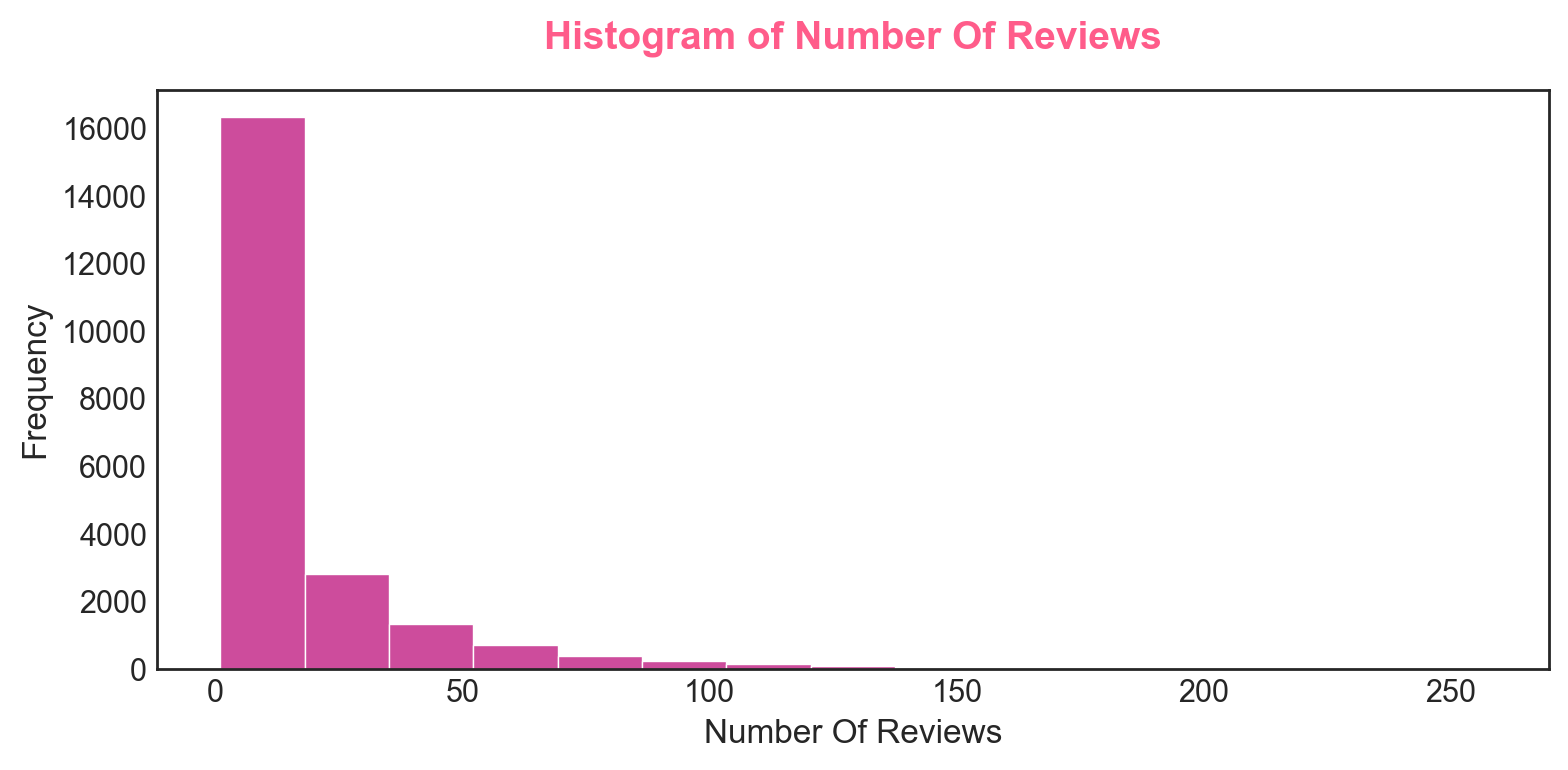

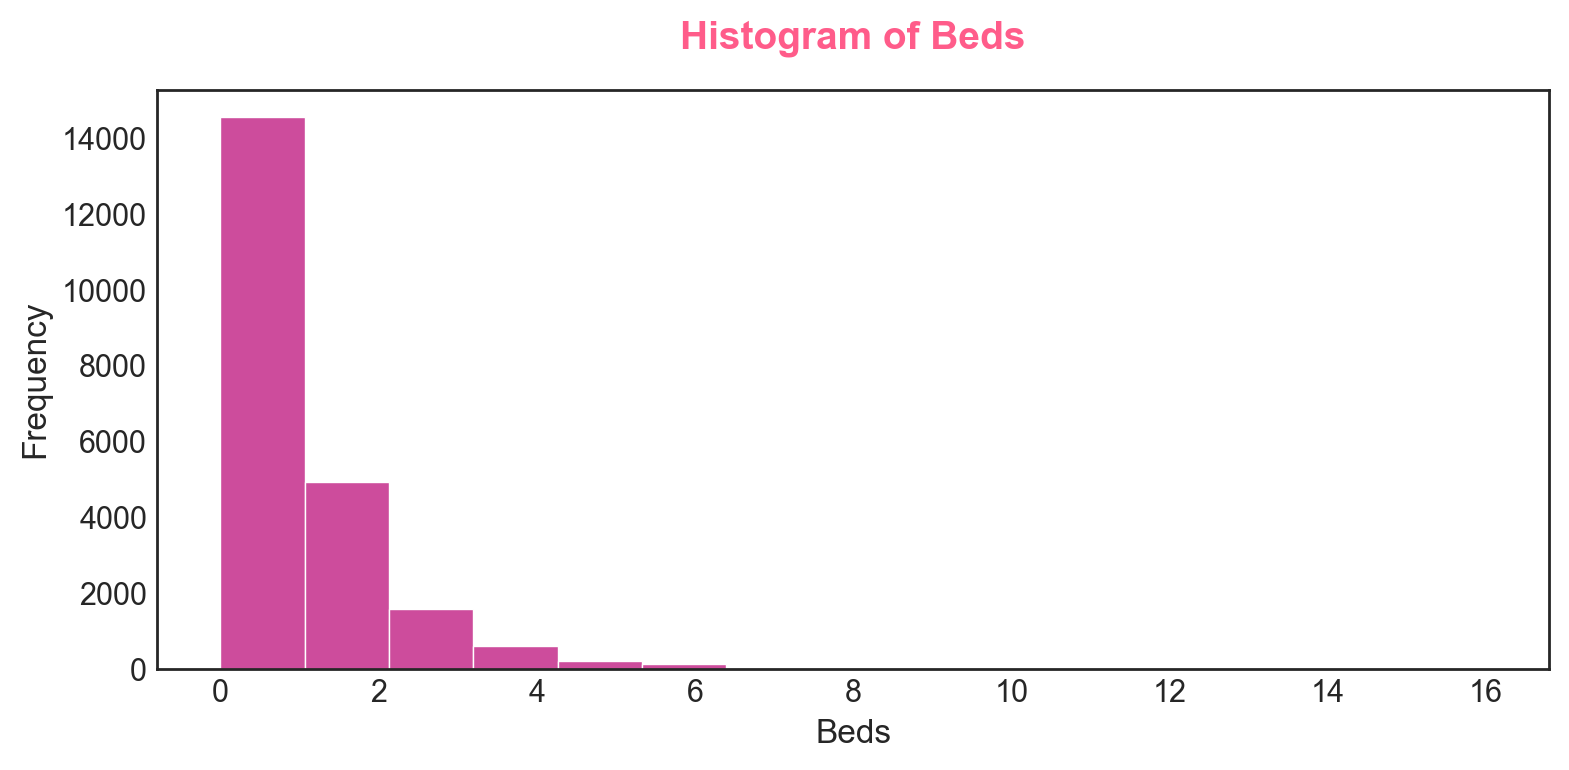

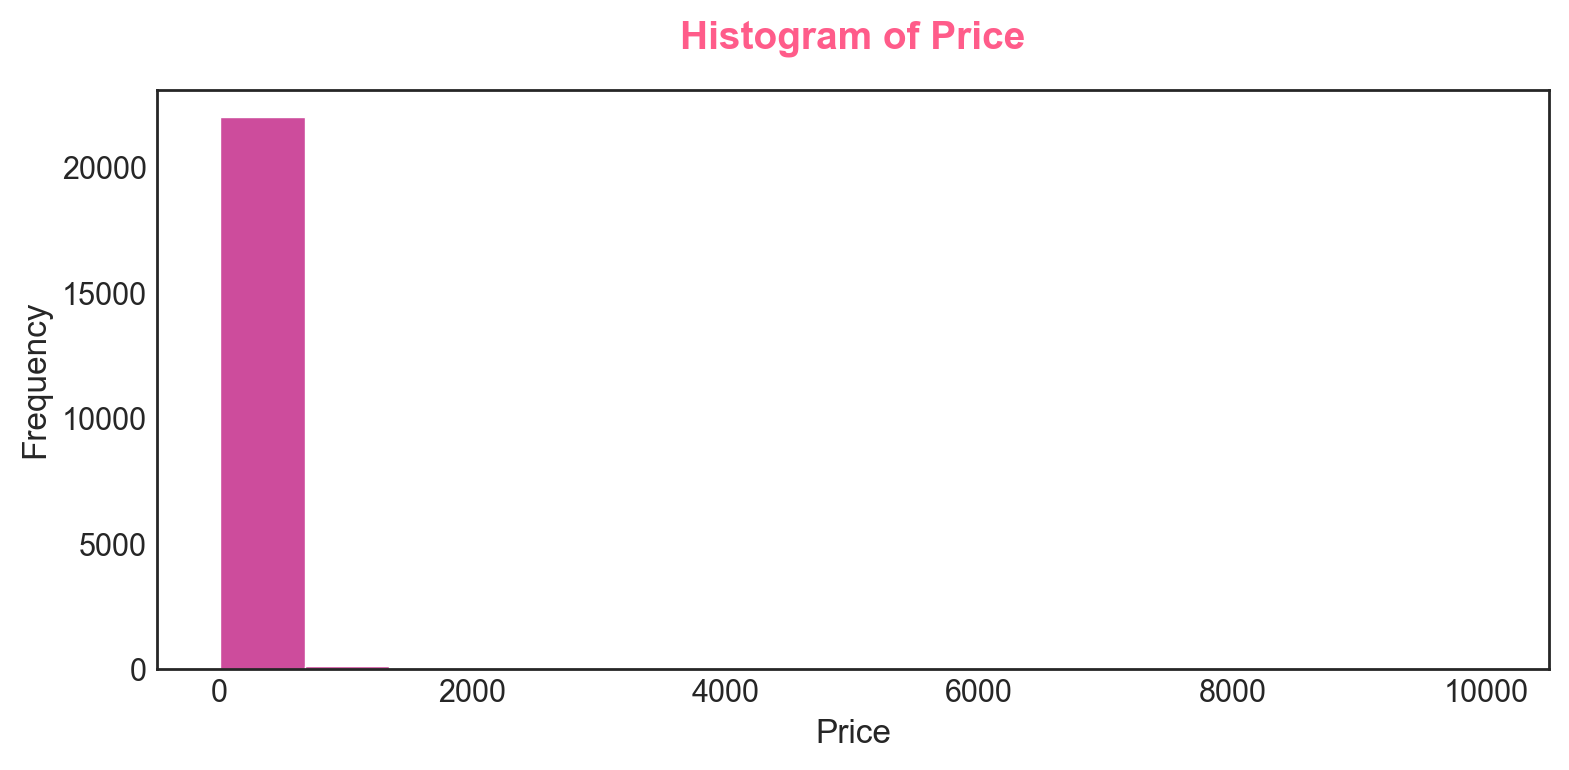

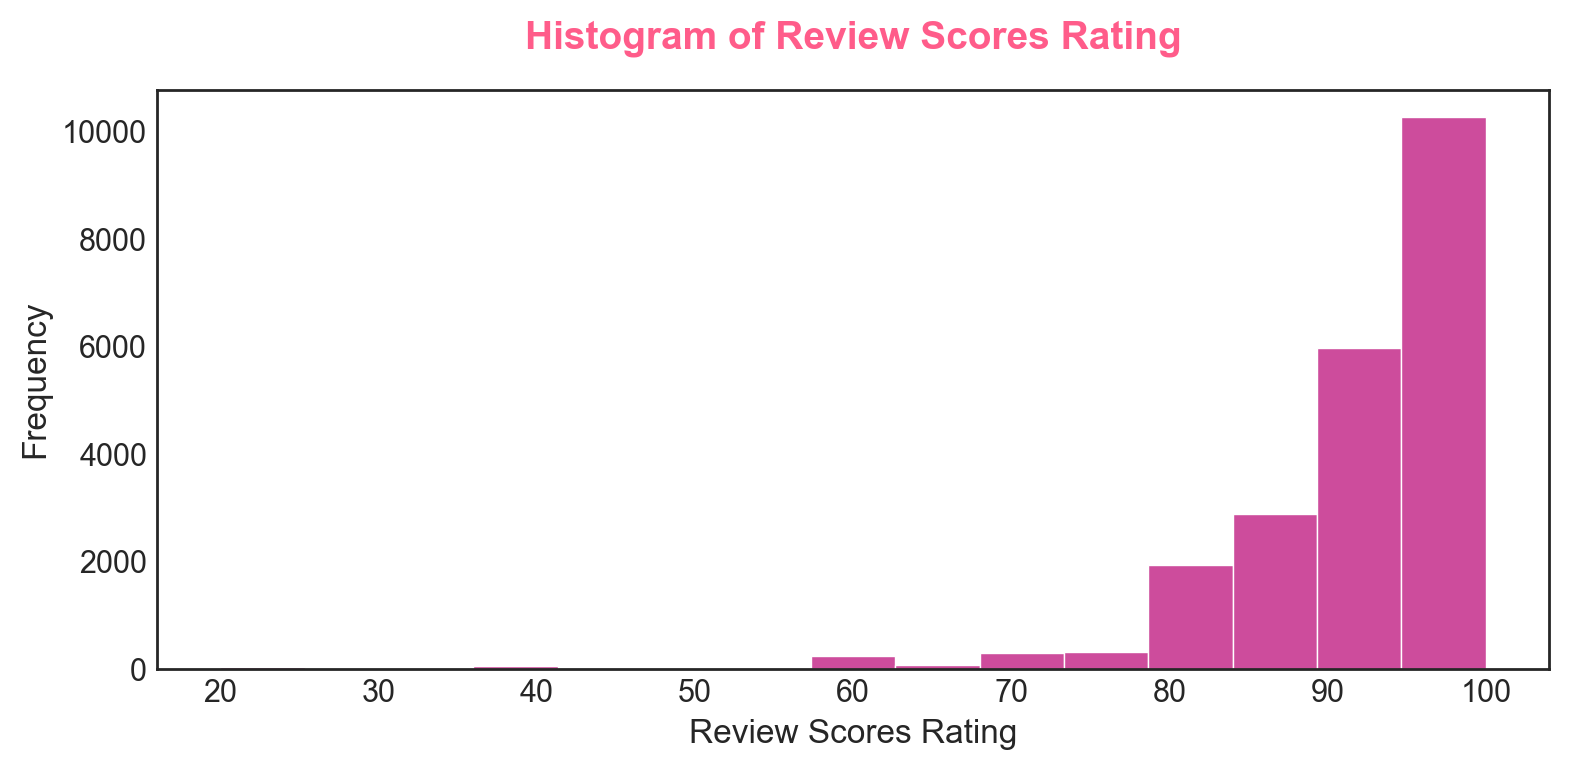

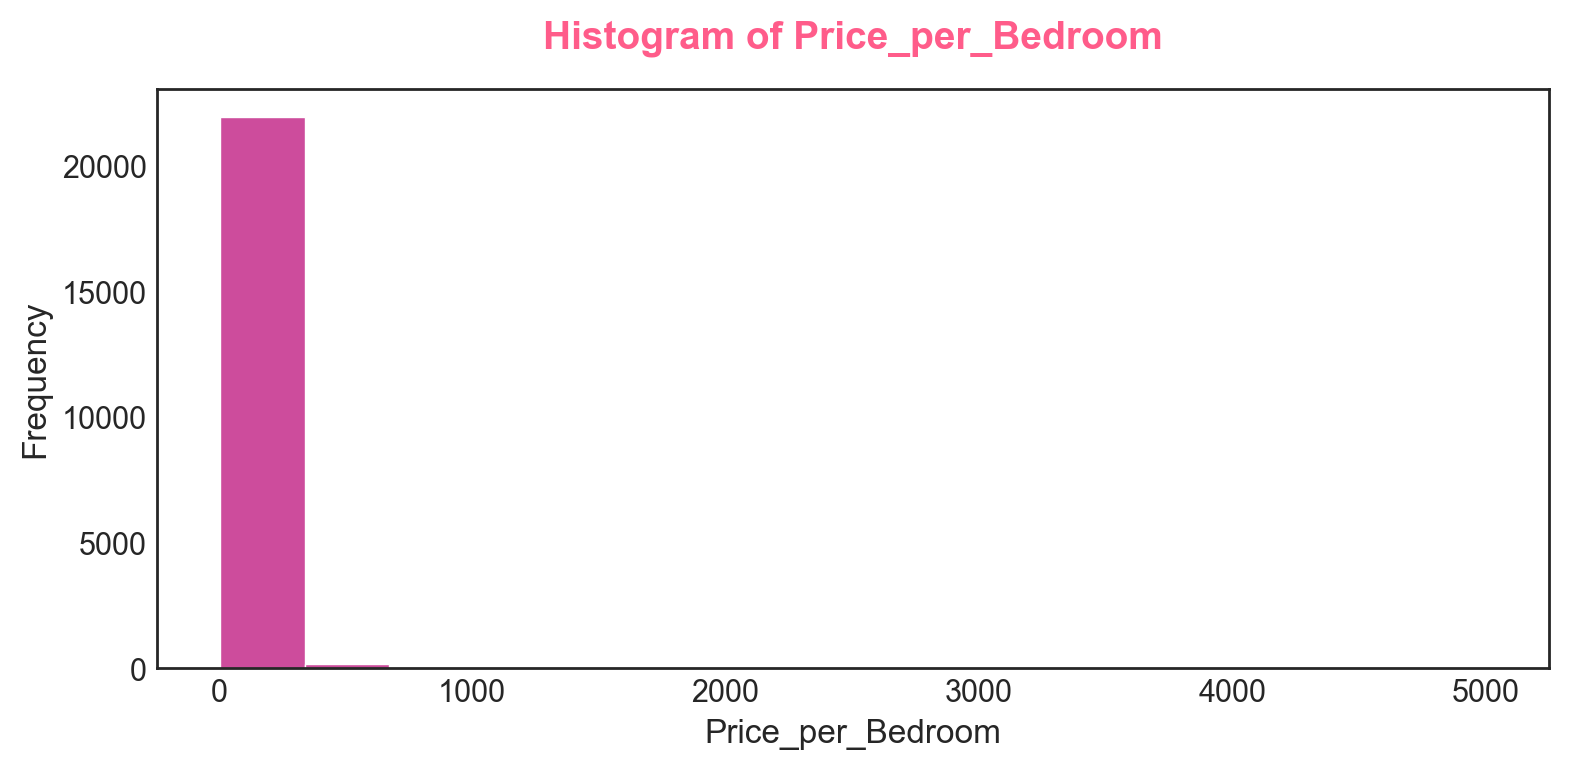

In [ ]:
# histograms of all numerical columns
for col in numerical_cols_df2:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df2, x=col, bins=15, kde=False, color="#b90072", alpha=0.7)
    plt.title(f'Histogram of {col}', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.grid(False)
    plt.tight_layout()
    plt.show()

### <a id='toc2_5_2_'></a>[Density Plots](#toc0_)


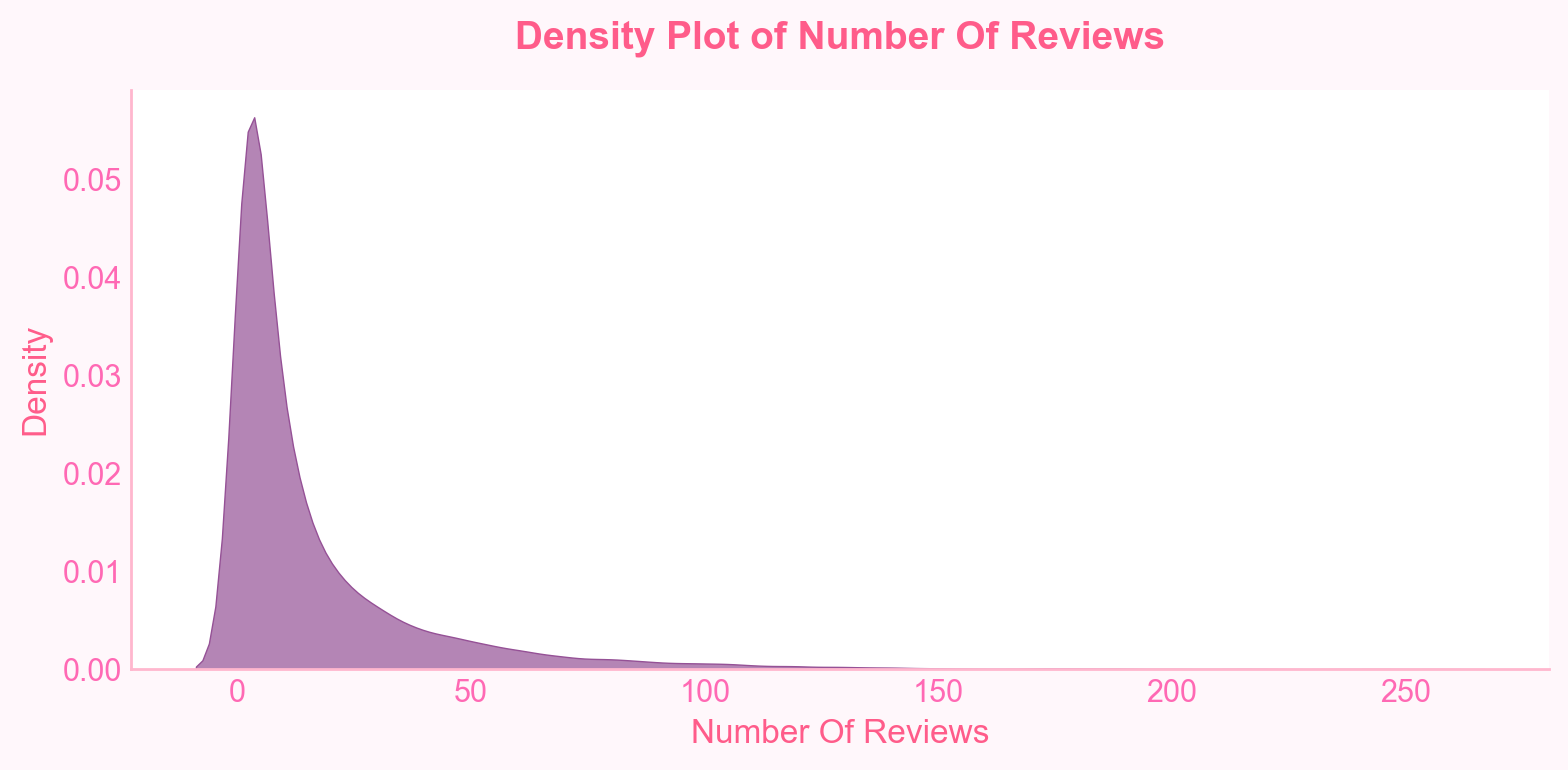

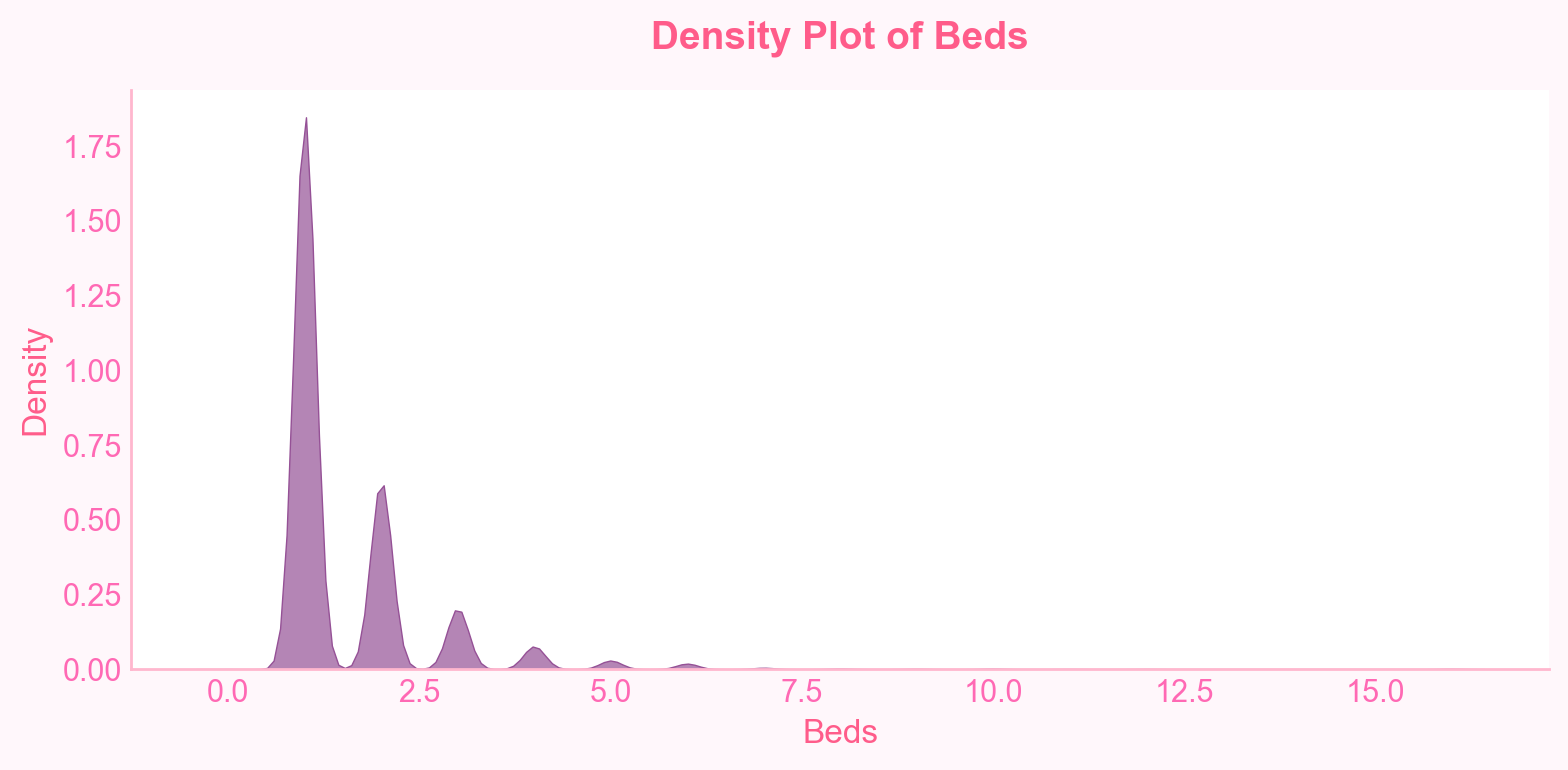

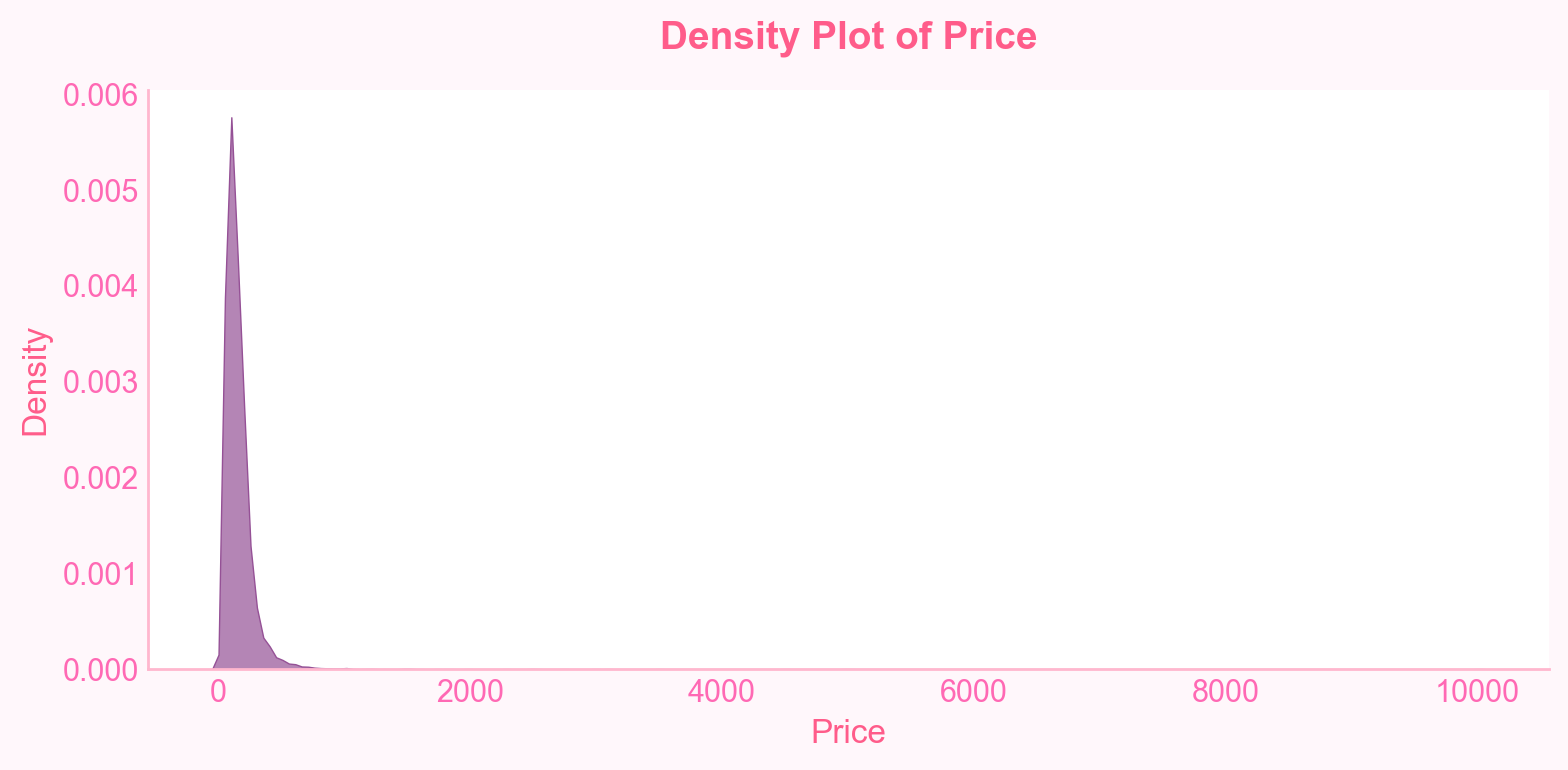

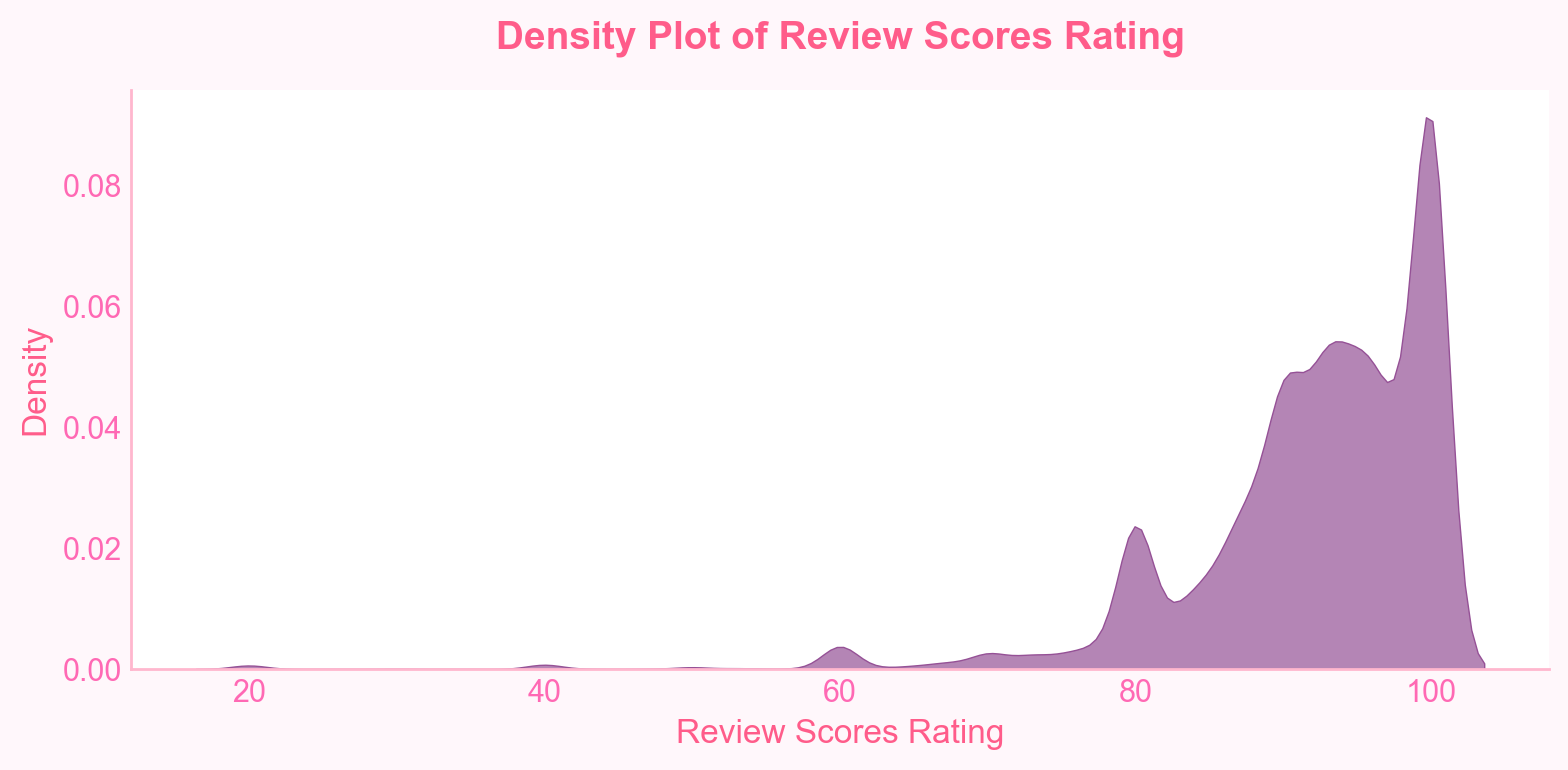

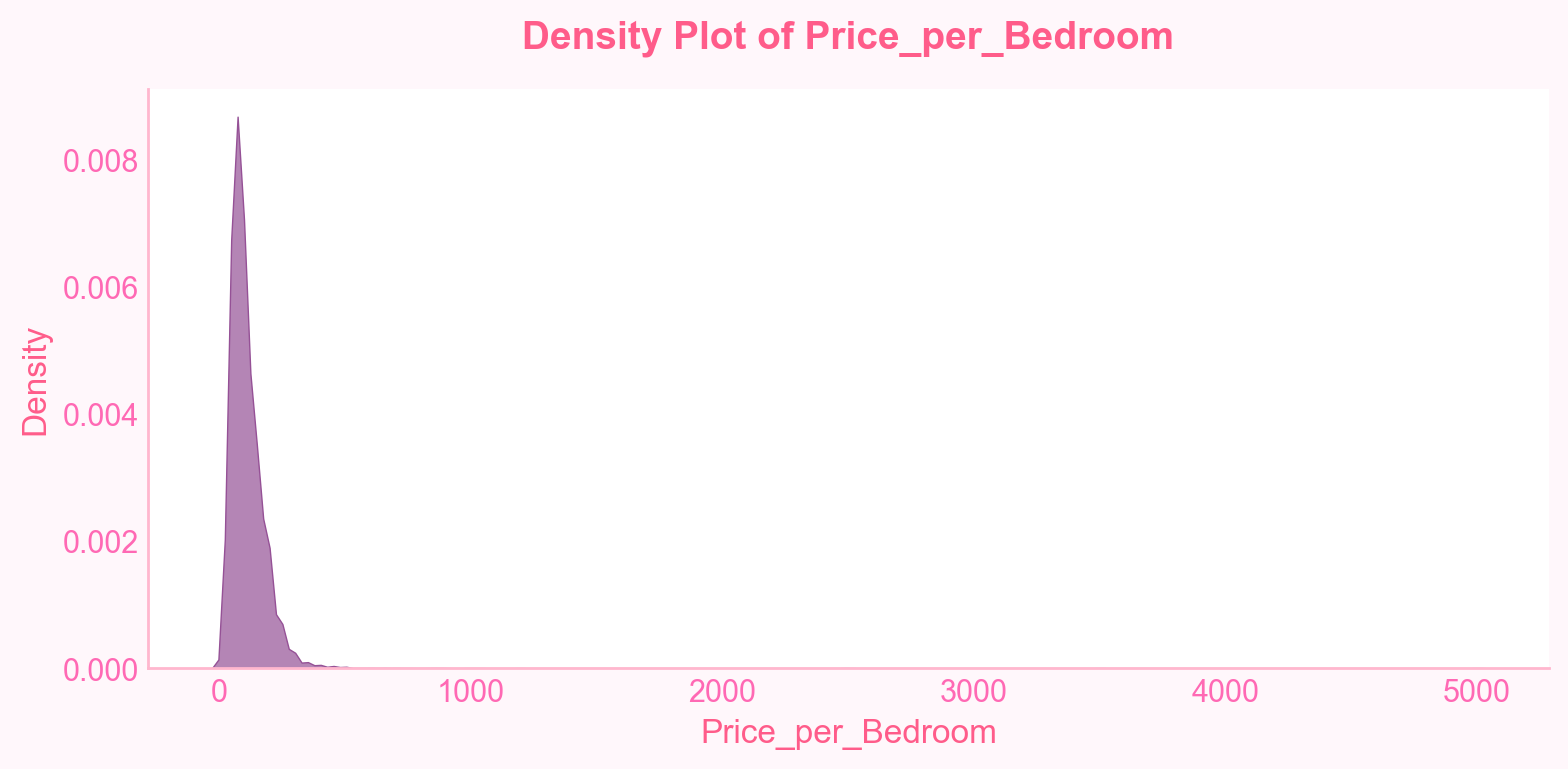

In [ ]:
# kde plots for numerical columns in df2
for col in numerical_cols_df2:
    plt.figure(figsize=(8, 4))
    sns.kdeplot(data=df2, x=col, fill=True, color='#955196', alpha=0.7)
    plt.title(f'Density Plot of {col}', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.grid(False)
    plt.tight_layout()
    plt.show()
    

### <a id='toc2_5_3_'></a>[Box Plots](#toc0_)


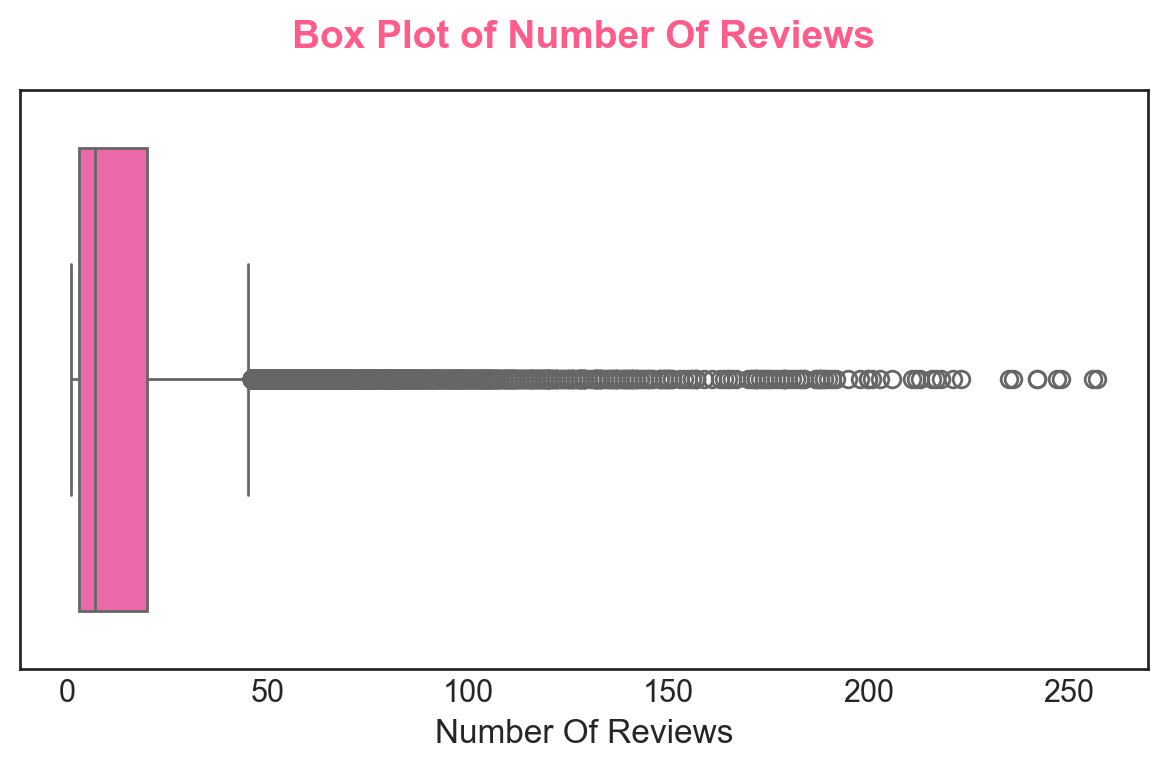

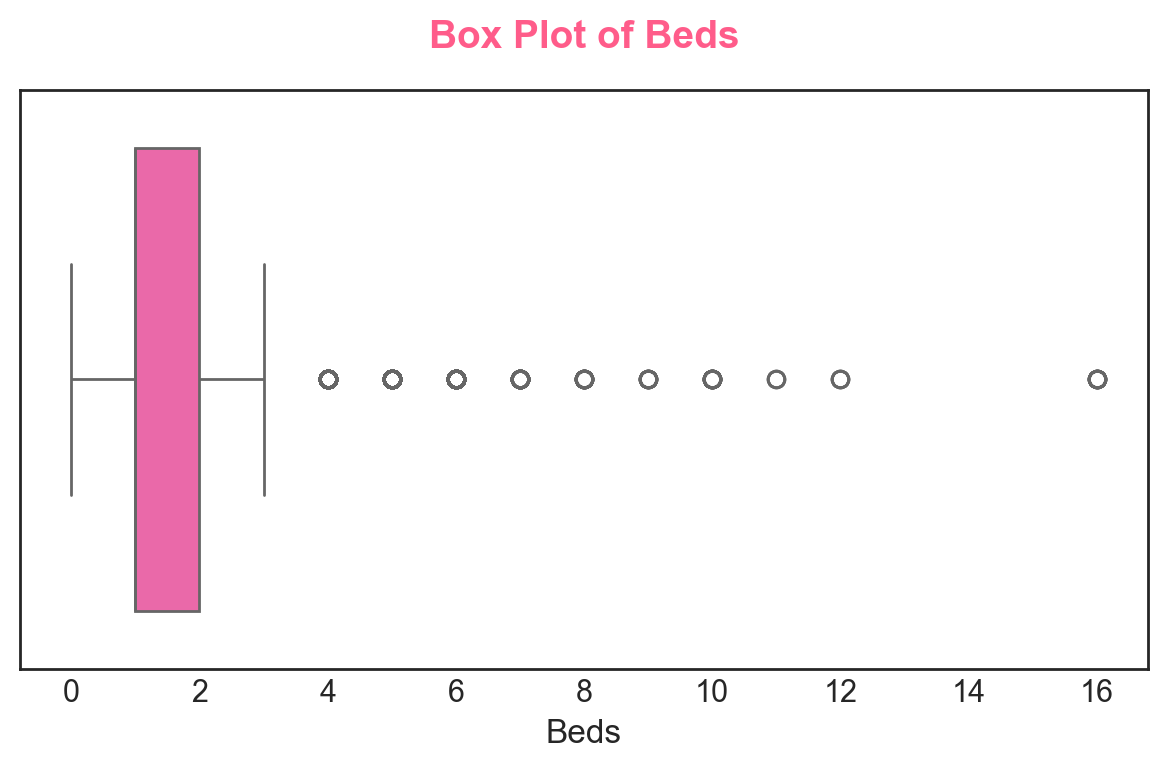

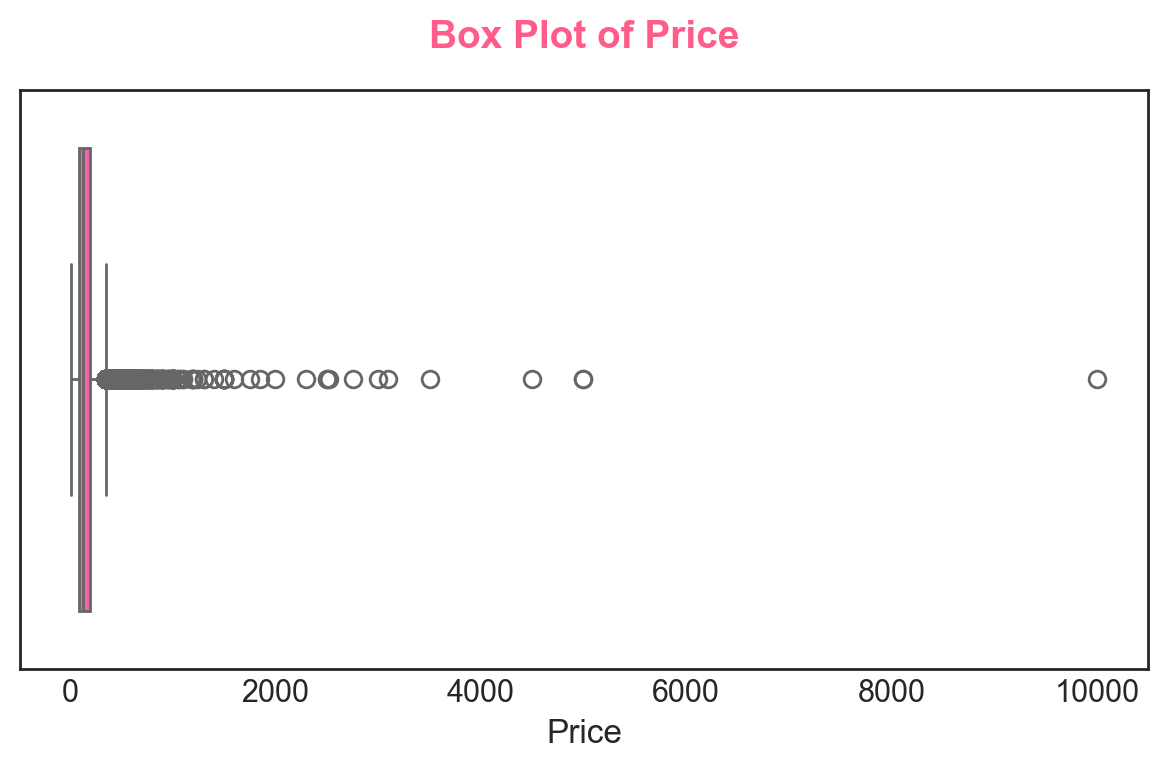

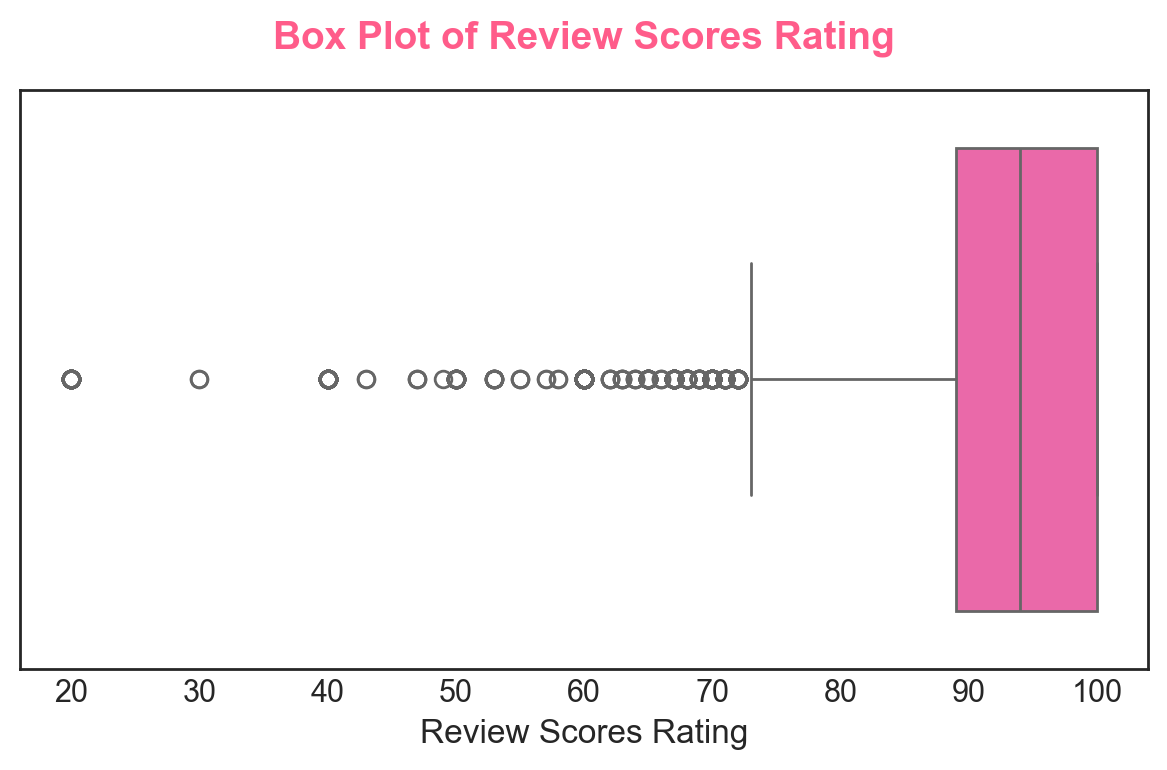

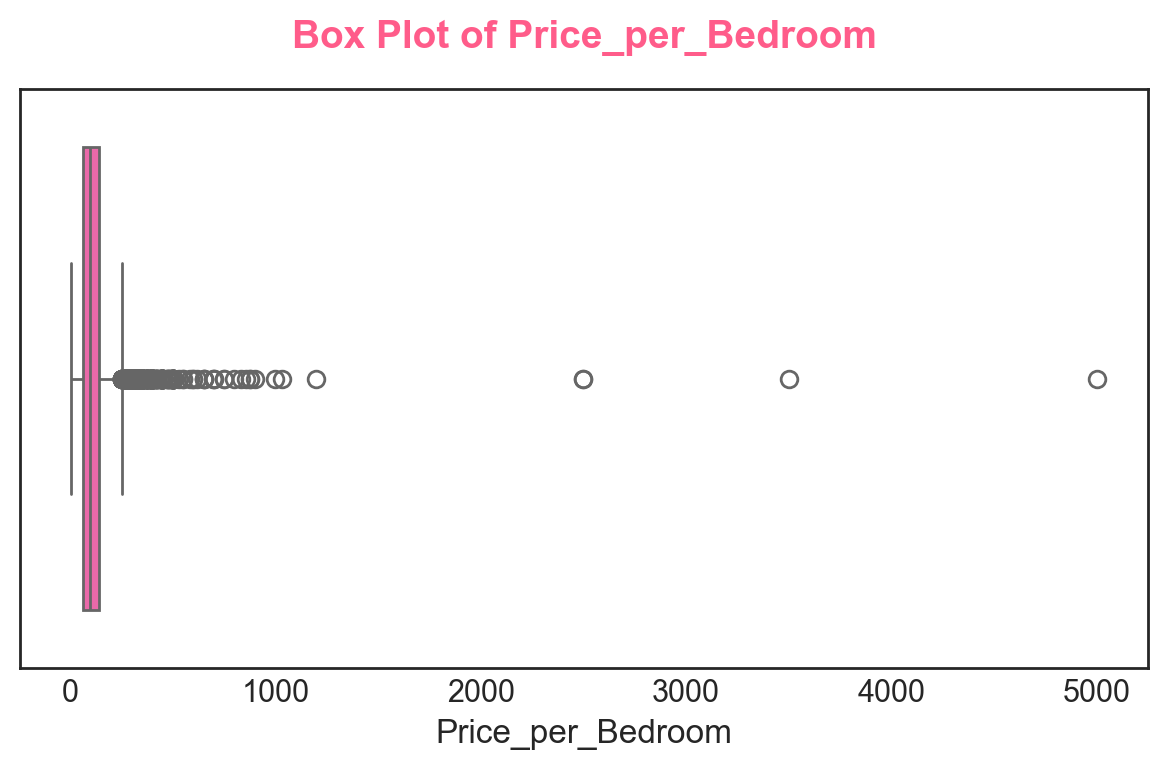

In [ ]:
# boxplots for numerical columns in df2
for col in numerical_cols_df2:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df2[col], color="#FF54A9")
    plt.title(f'Box Plot of {col}', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.grid(False)
    plt.tight_layout()
    plt.show()

---

## <a id='toc2_6_'></a>[Bivariate Analysis](#toc0_)


### <a id='toc2_6_1_'></a>[Scatterplots](#toc0_)


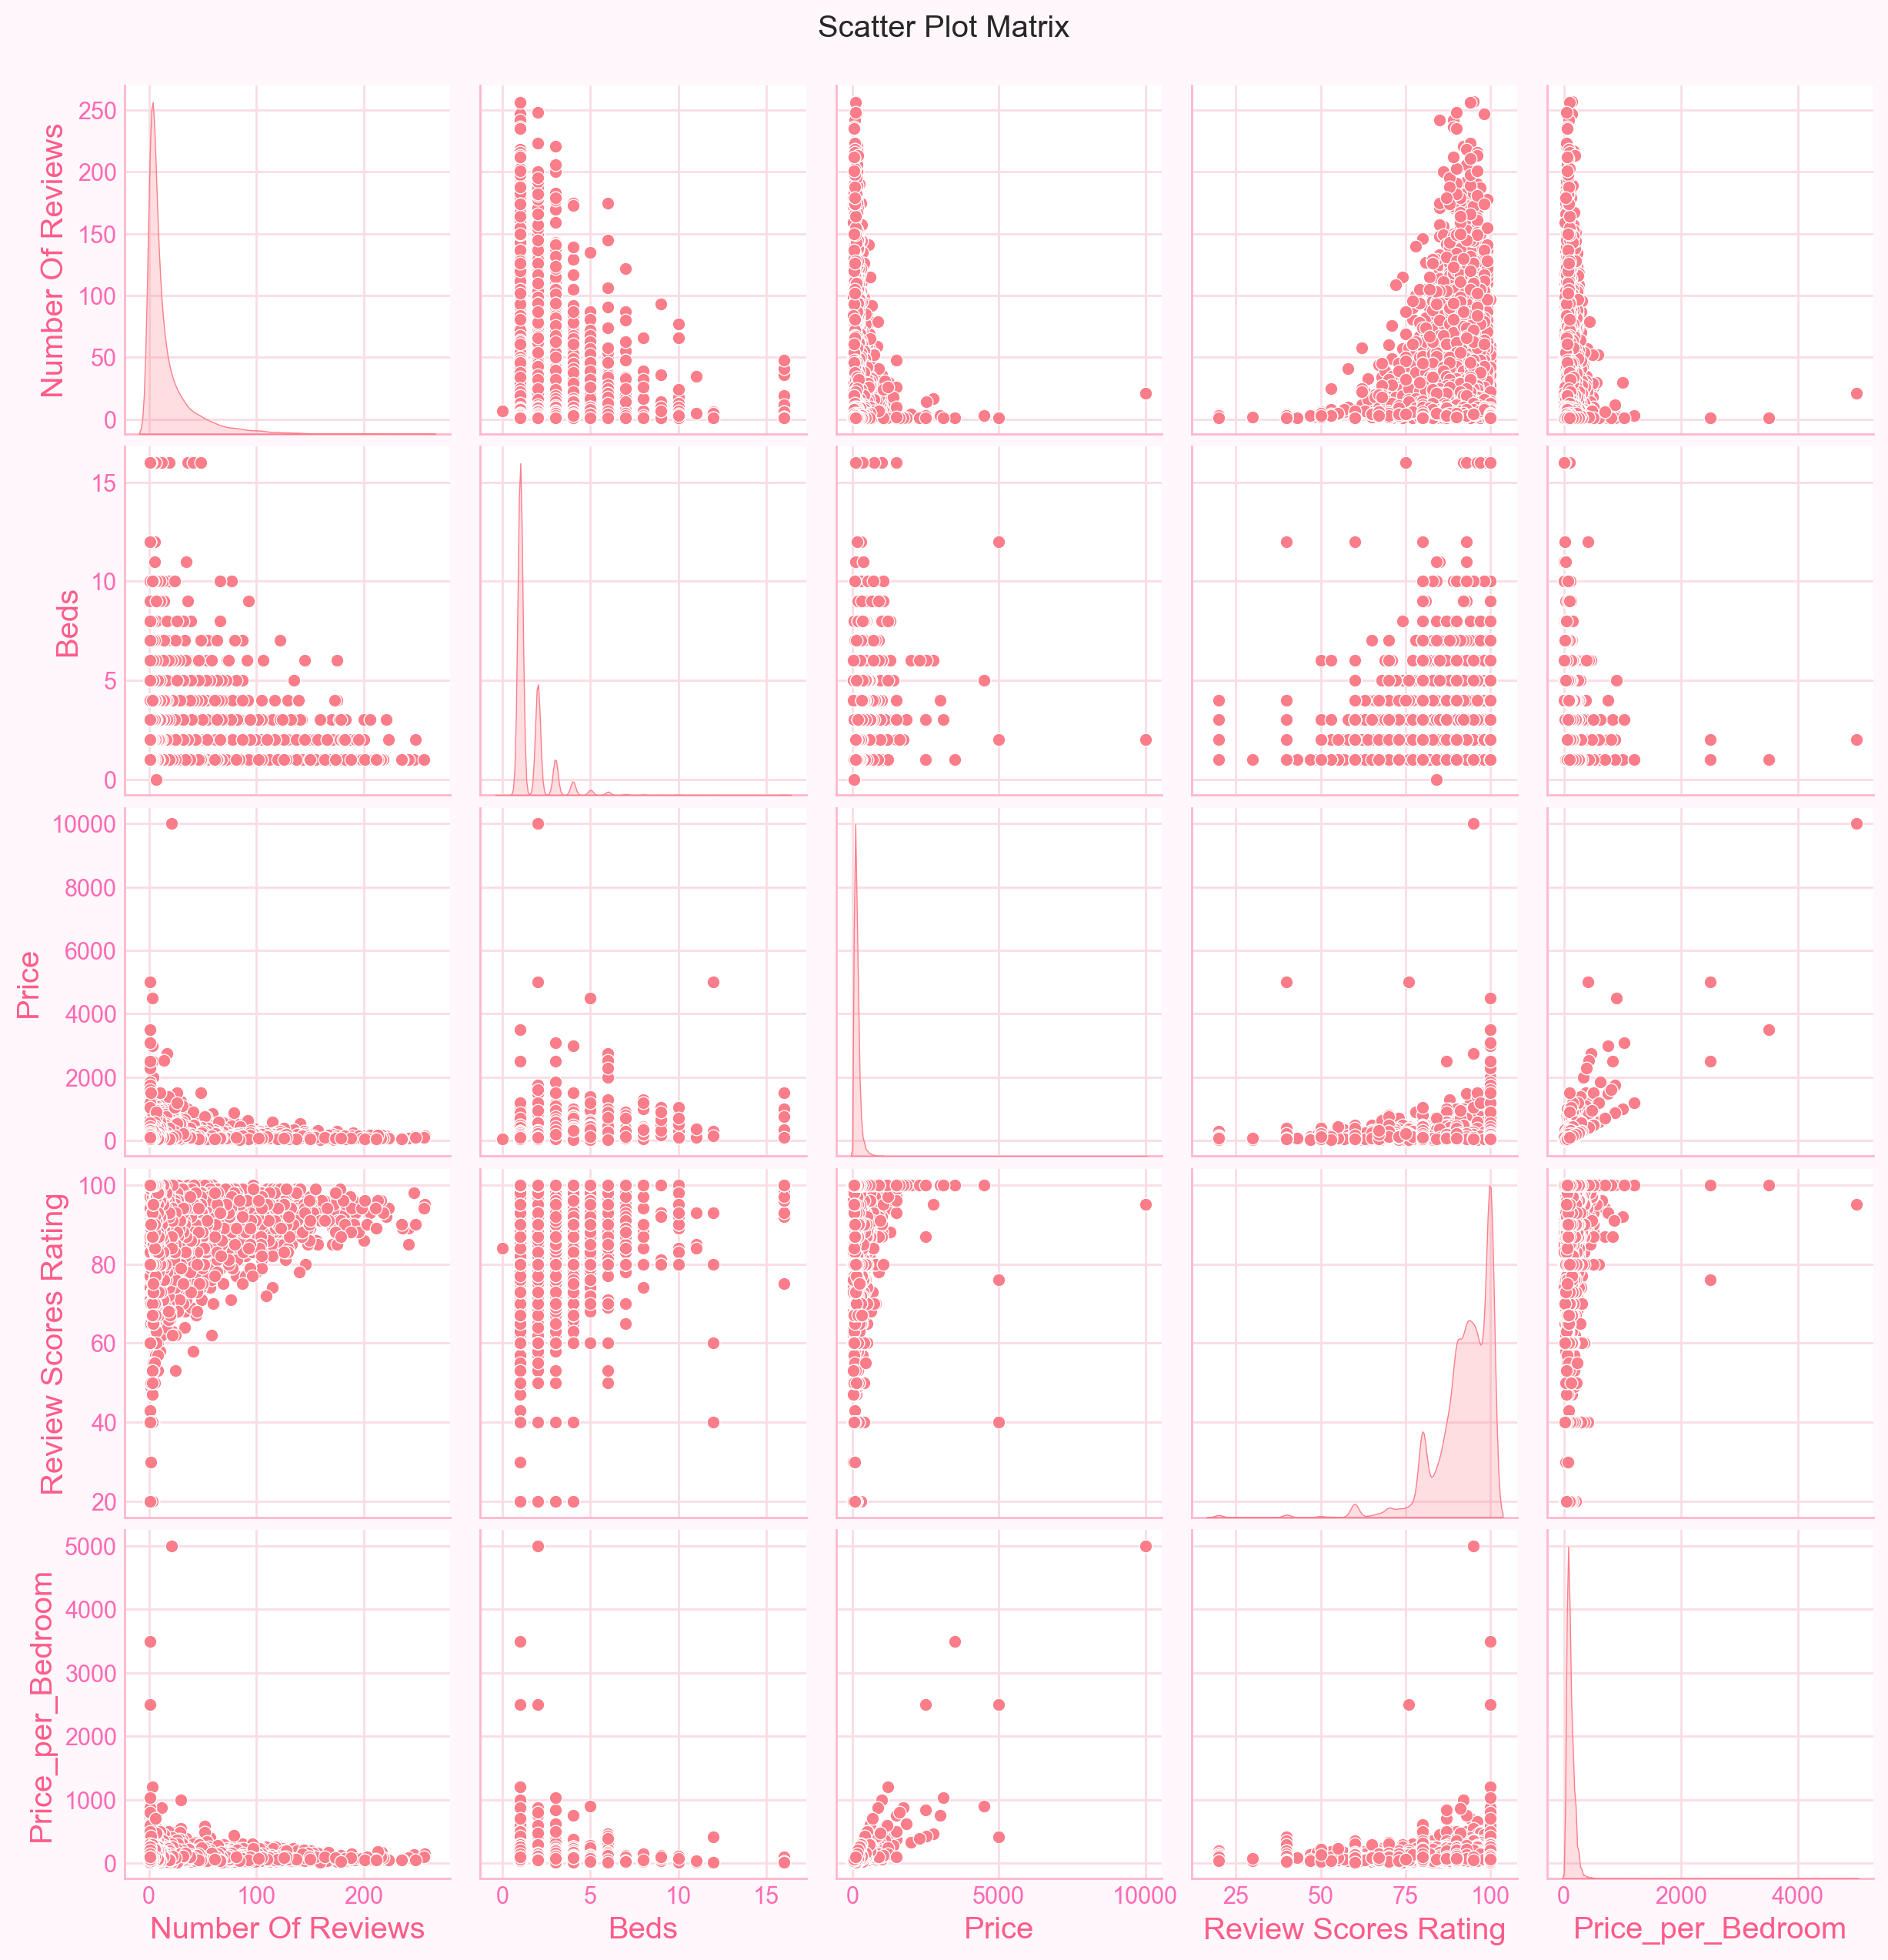

In [ ]:
sns.pairplot(df2[numerical_cols_df2], diag_kind="kde", kind="scatter")
plt.suptitle("Scatter Plot Matrix", y=1.02)
plt.show()

### <a id='toc2_6_2_'></a>[Correlation Matrix](#toc0_)


In [ ]:
corr = df2[numerical_cols_df2].corr()
print(corr)

                      Number Of Reviews   Beds  Price  Review Scores Rating  \
Number Of Reviews                 1.000  0.038 -0.027                -0.015   
Beds                              0.038  1.000  0.368                -0.071   
Price                            -0.027  0.368  1.000                 0.061   
Review Scores Rating             -0.015 -0.071  0.061                 1.000   
Price_per_Bedroom                -0.054 -0.203  0.707                 0.132   

                      Price_per_Bedroom  
Number Of Reviews                -0.054  
Beds                             -0.203  
Price                             0.707  
Review Scores Rating              0.132  
Price_per_Bedroom                 1.000  


### <a id='toc2_6_3_'></a>[Bar charts](#toc0_)

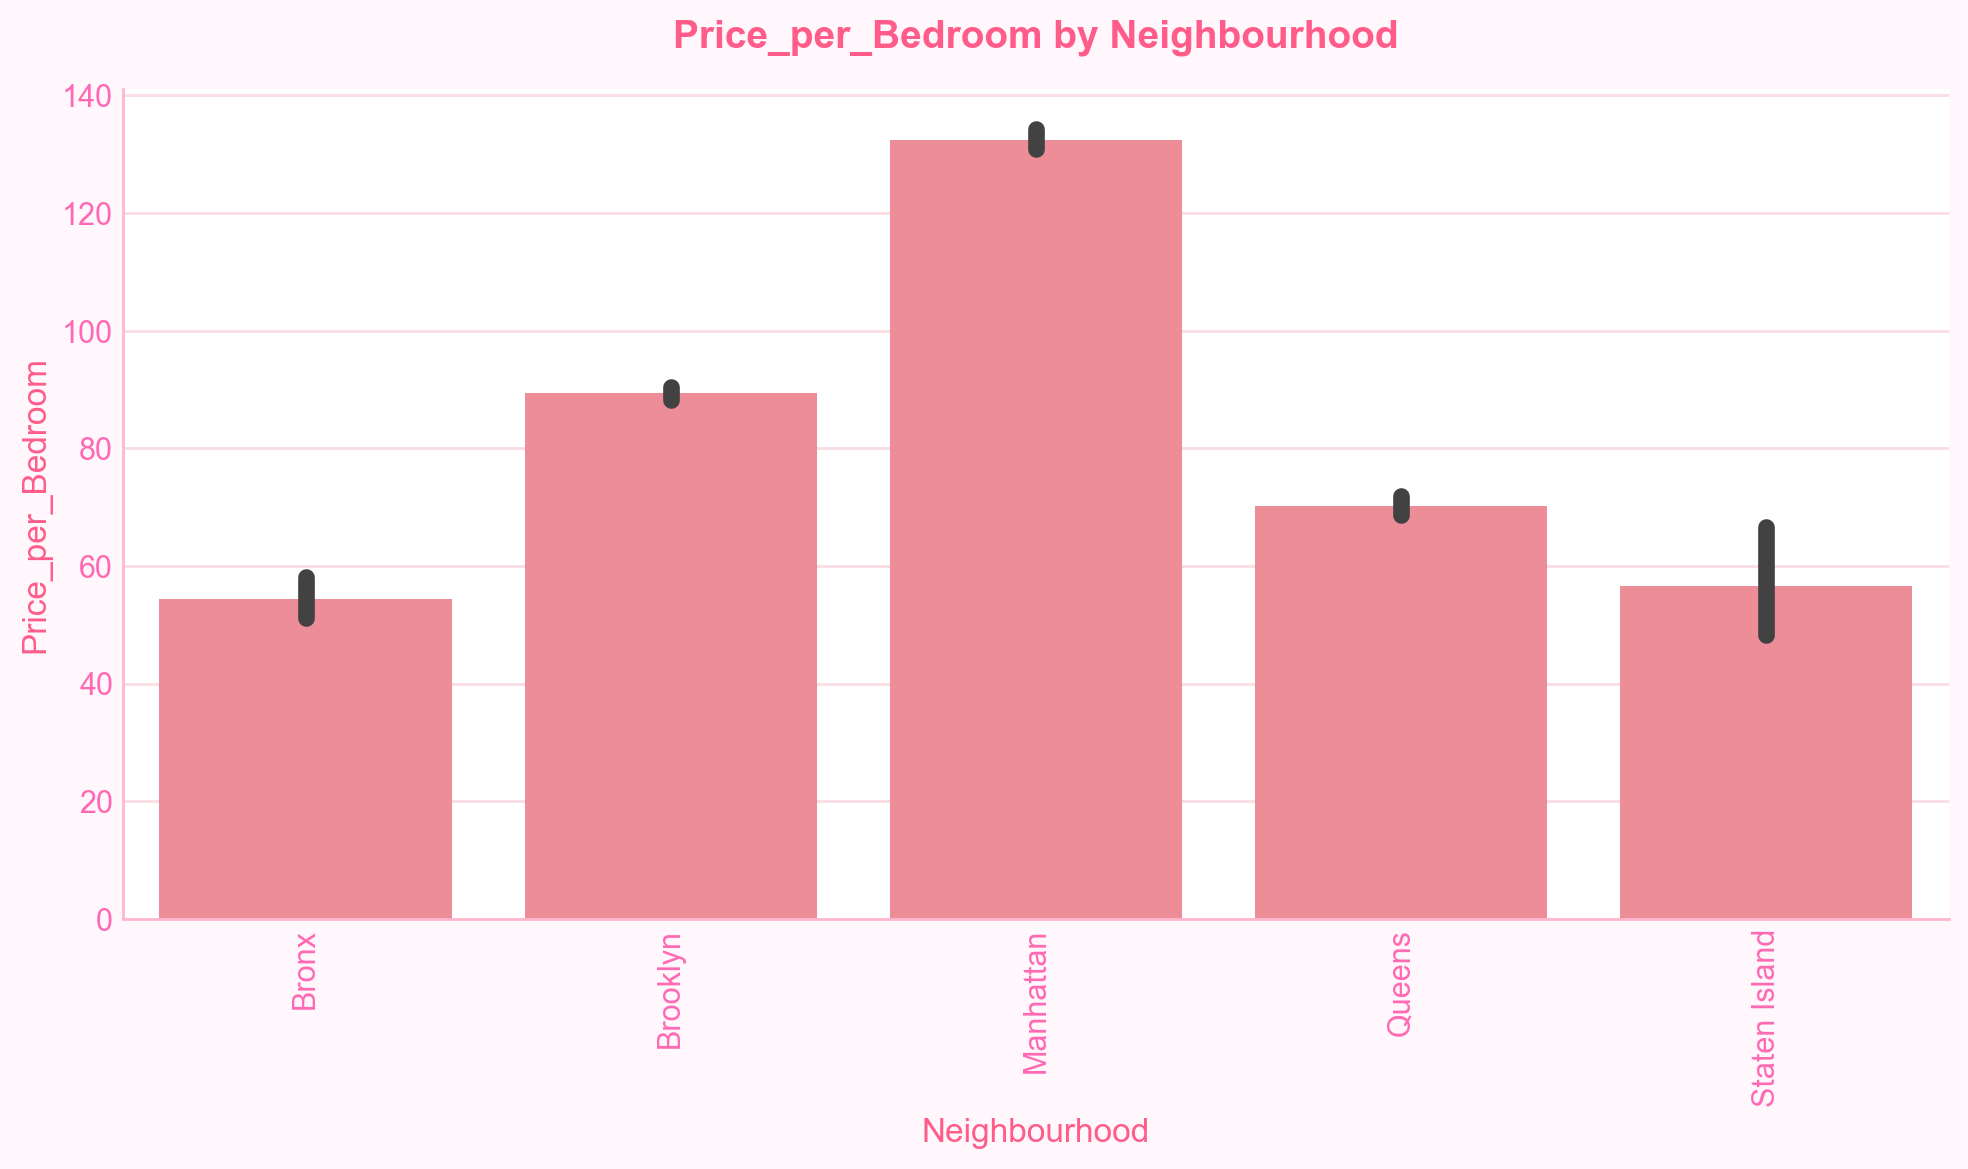

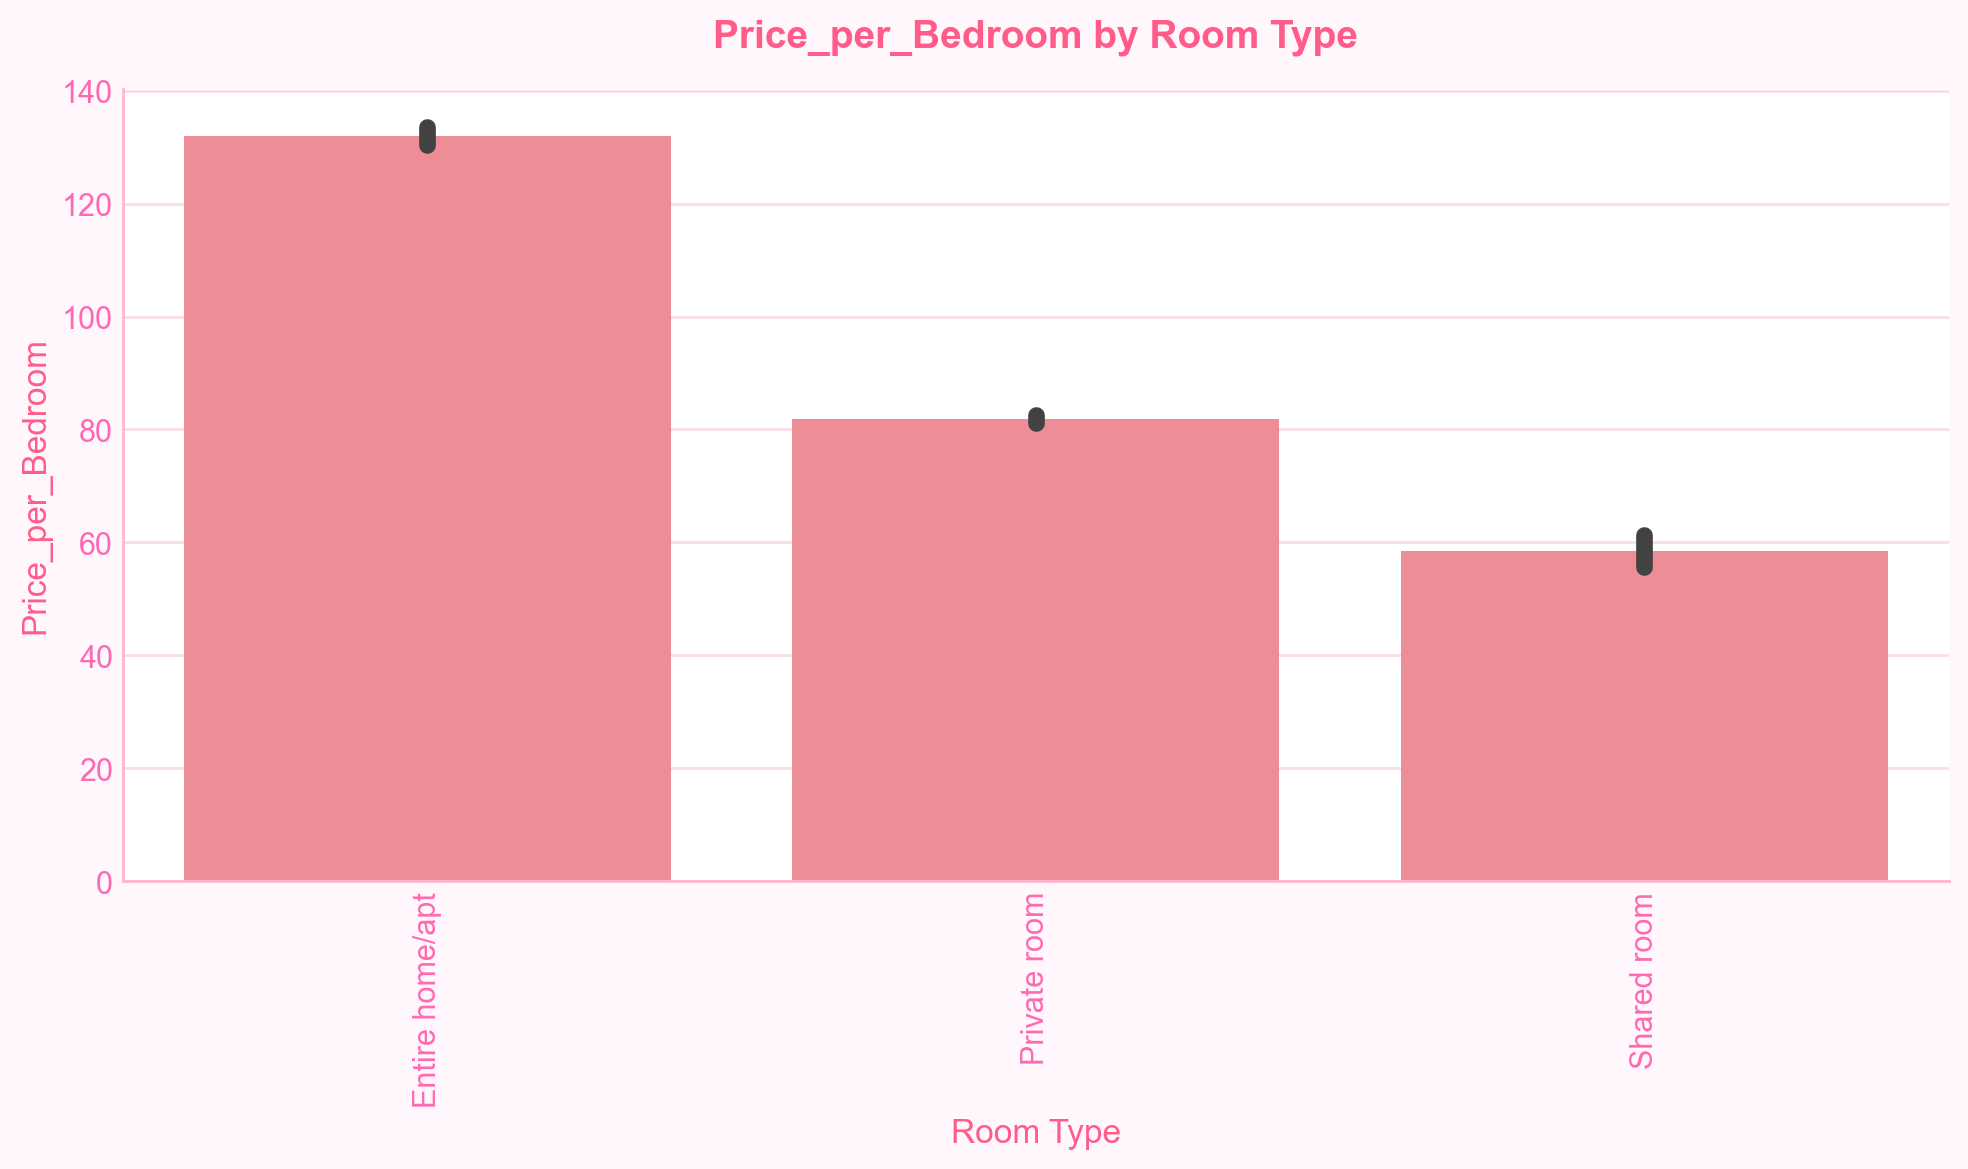

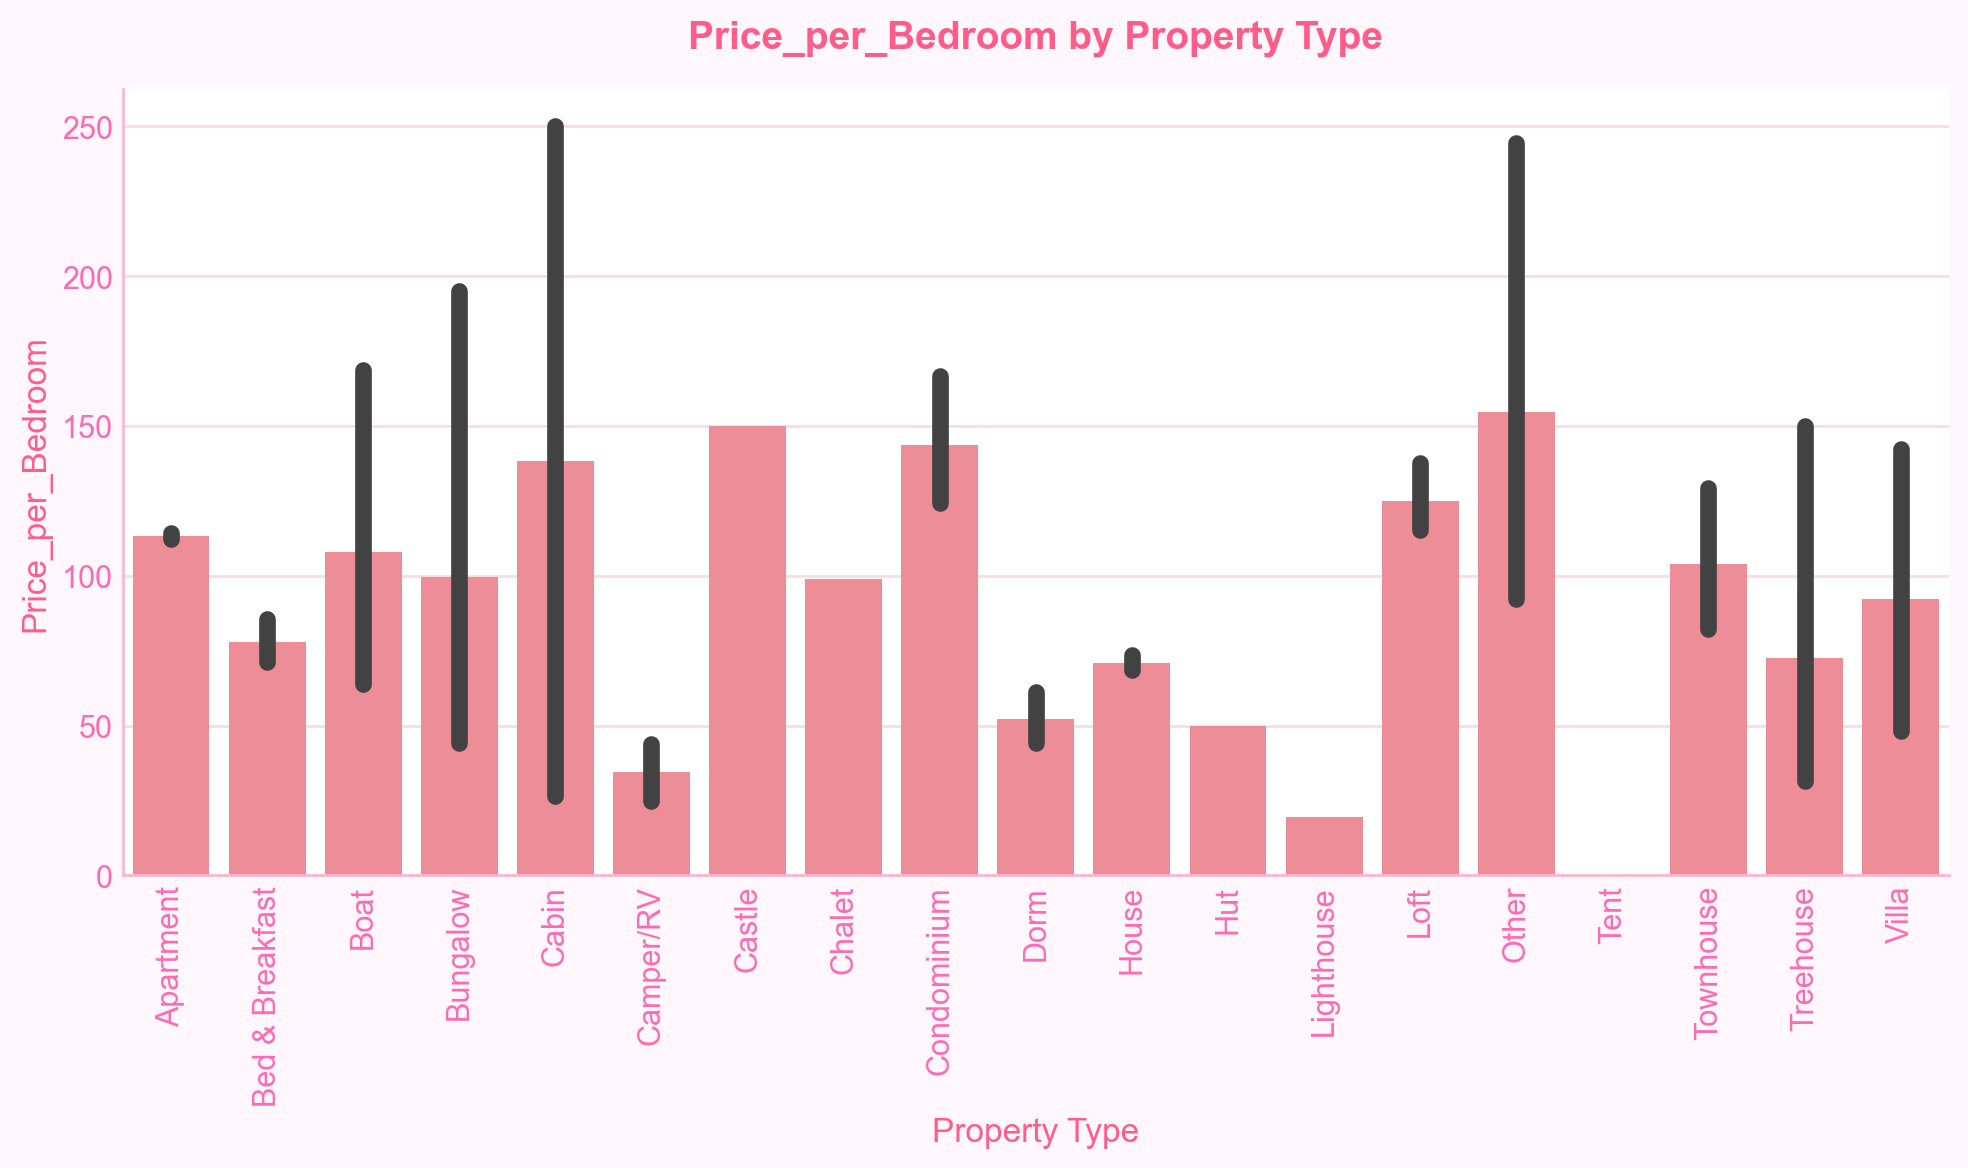

In [ ]:
categorical_cols_barchart_df2 = ['Neighbourhood', 'Room Type', 'Property Type']
num_col_bargraph = 'Price_per_Bedroom'
# bar graphs for categorical columns in df2
for col in categorical_cols_barchart_df2:
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df2, x=col, y=num_col_bargraph)
    plt.title(f'{num_col_bargraph} by {col}', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel(num_col_bargraph, fontsize=12)
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

---

## <a id='toc2_7_'></a>[Multivariate Analysis](#toc0_)


### <a id='toc2_7_1_'></a>[Heatmap](#toc0_)

Text(0.5, 1.0, 'Correlation Heatmap for df2')

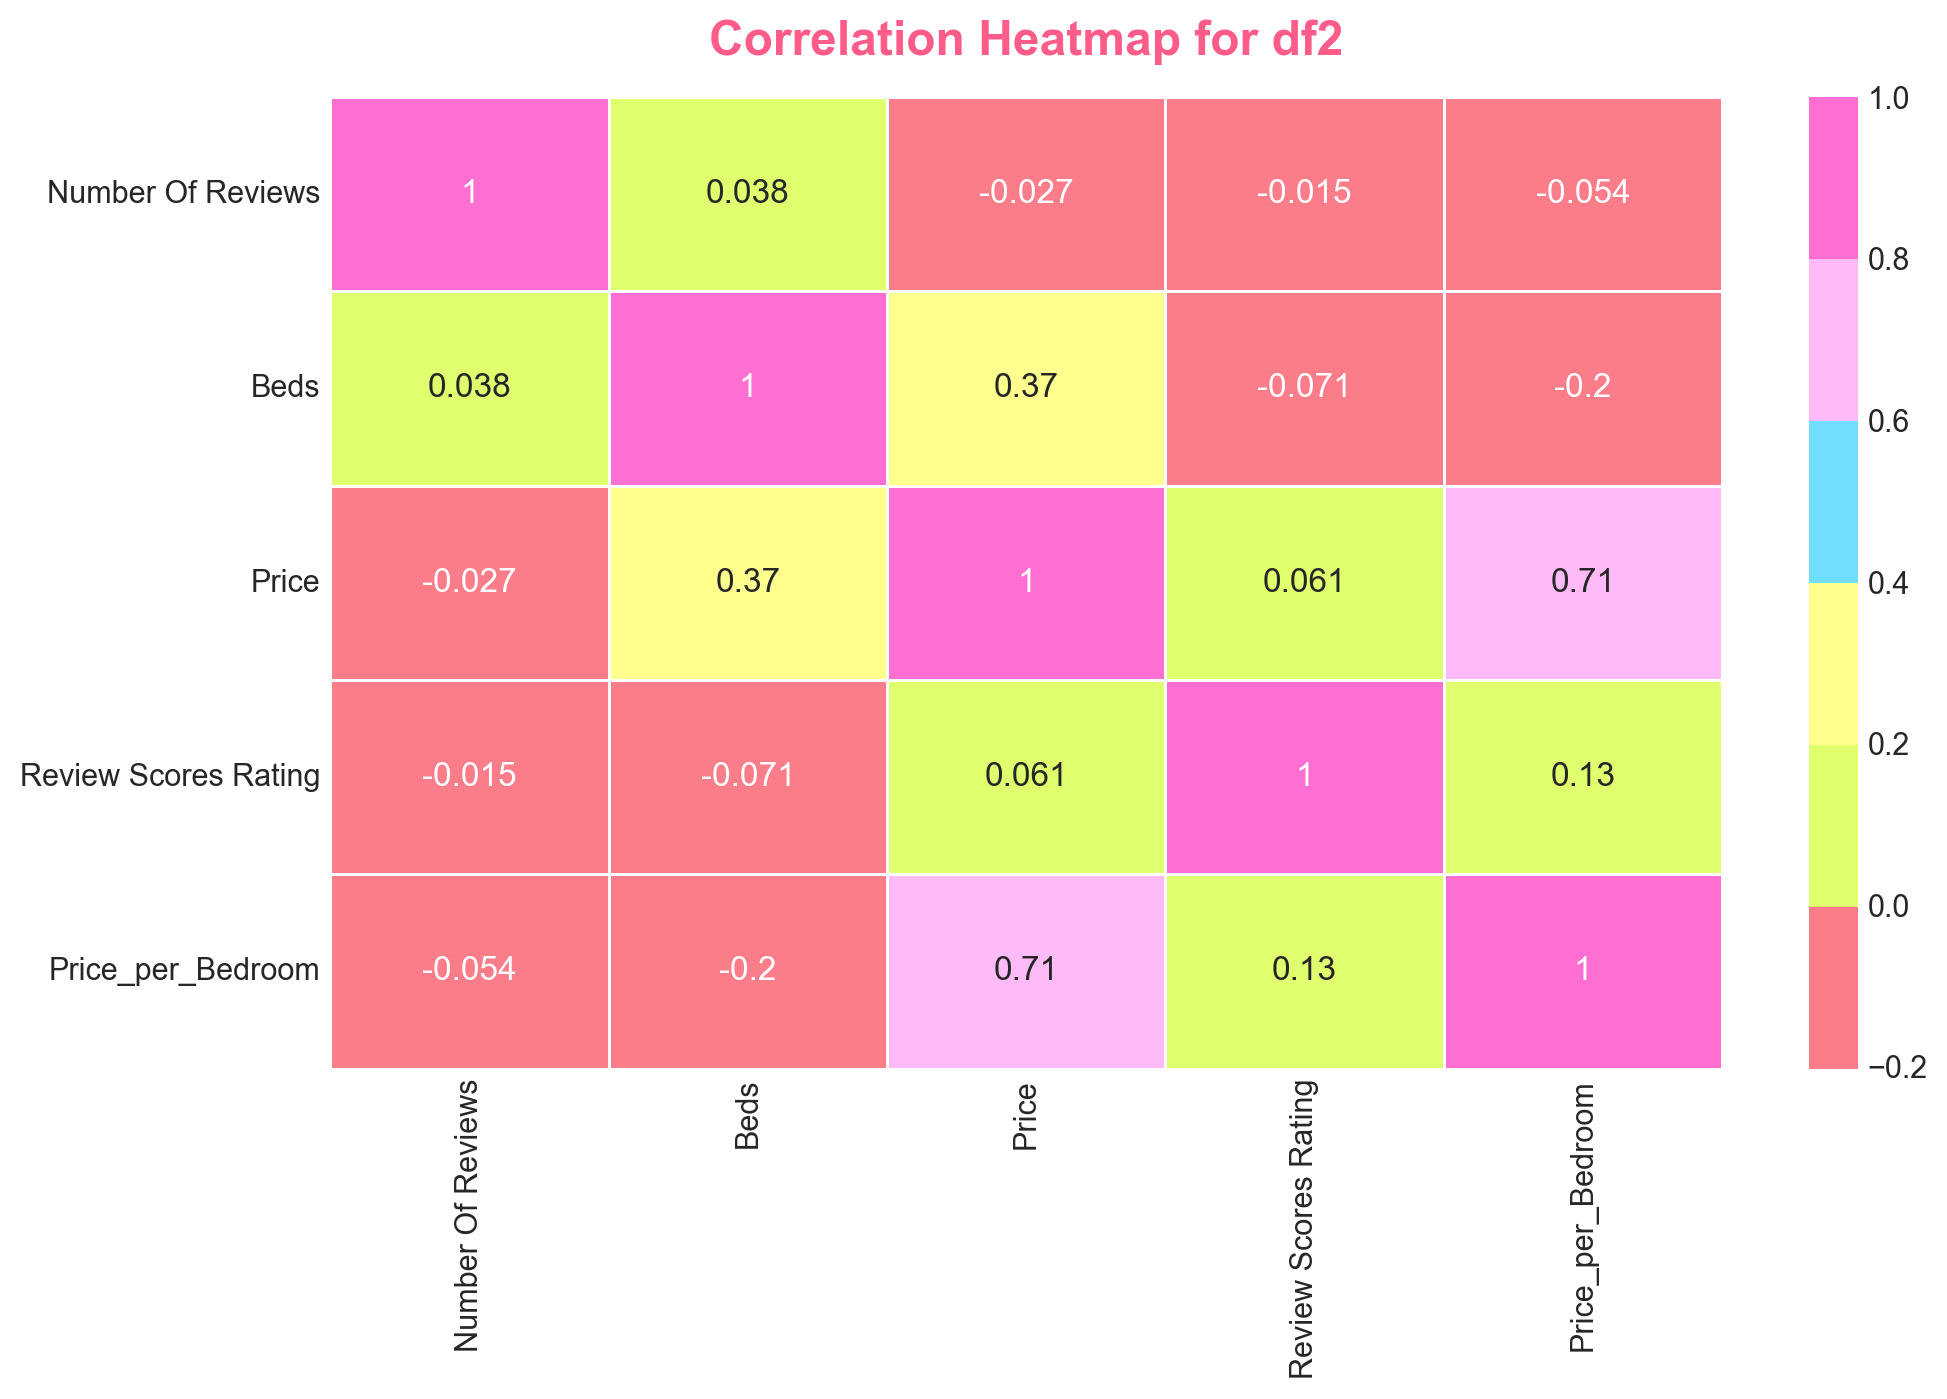

In [ ]:
# heatmap for df2
plt.figure(figsize=(10, 6))
sns.heatmap(corr, cmap = kawaii_palette,annot=True,linewidths=0.5)
plt.title("Correlation Heatmap for df2")

### <a id='toc2_7_2_'></a>[Scatter Plot Matrix](#toc0_)


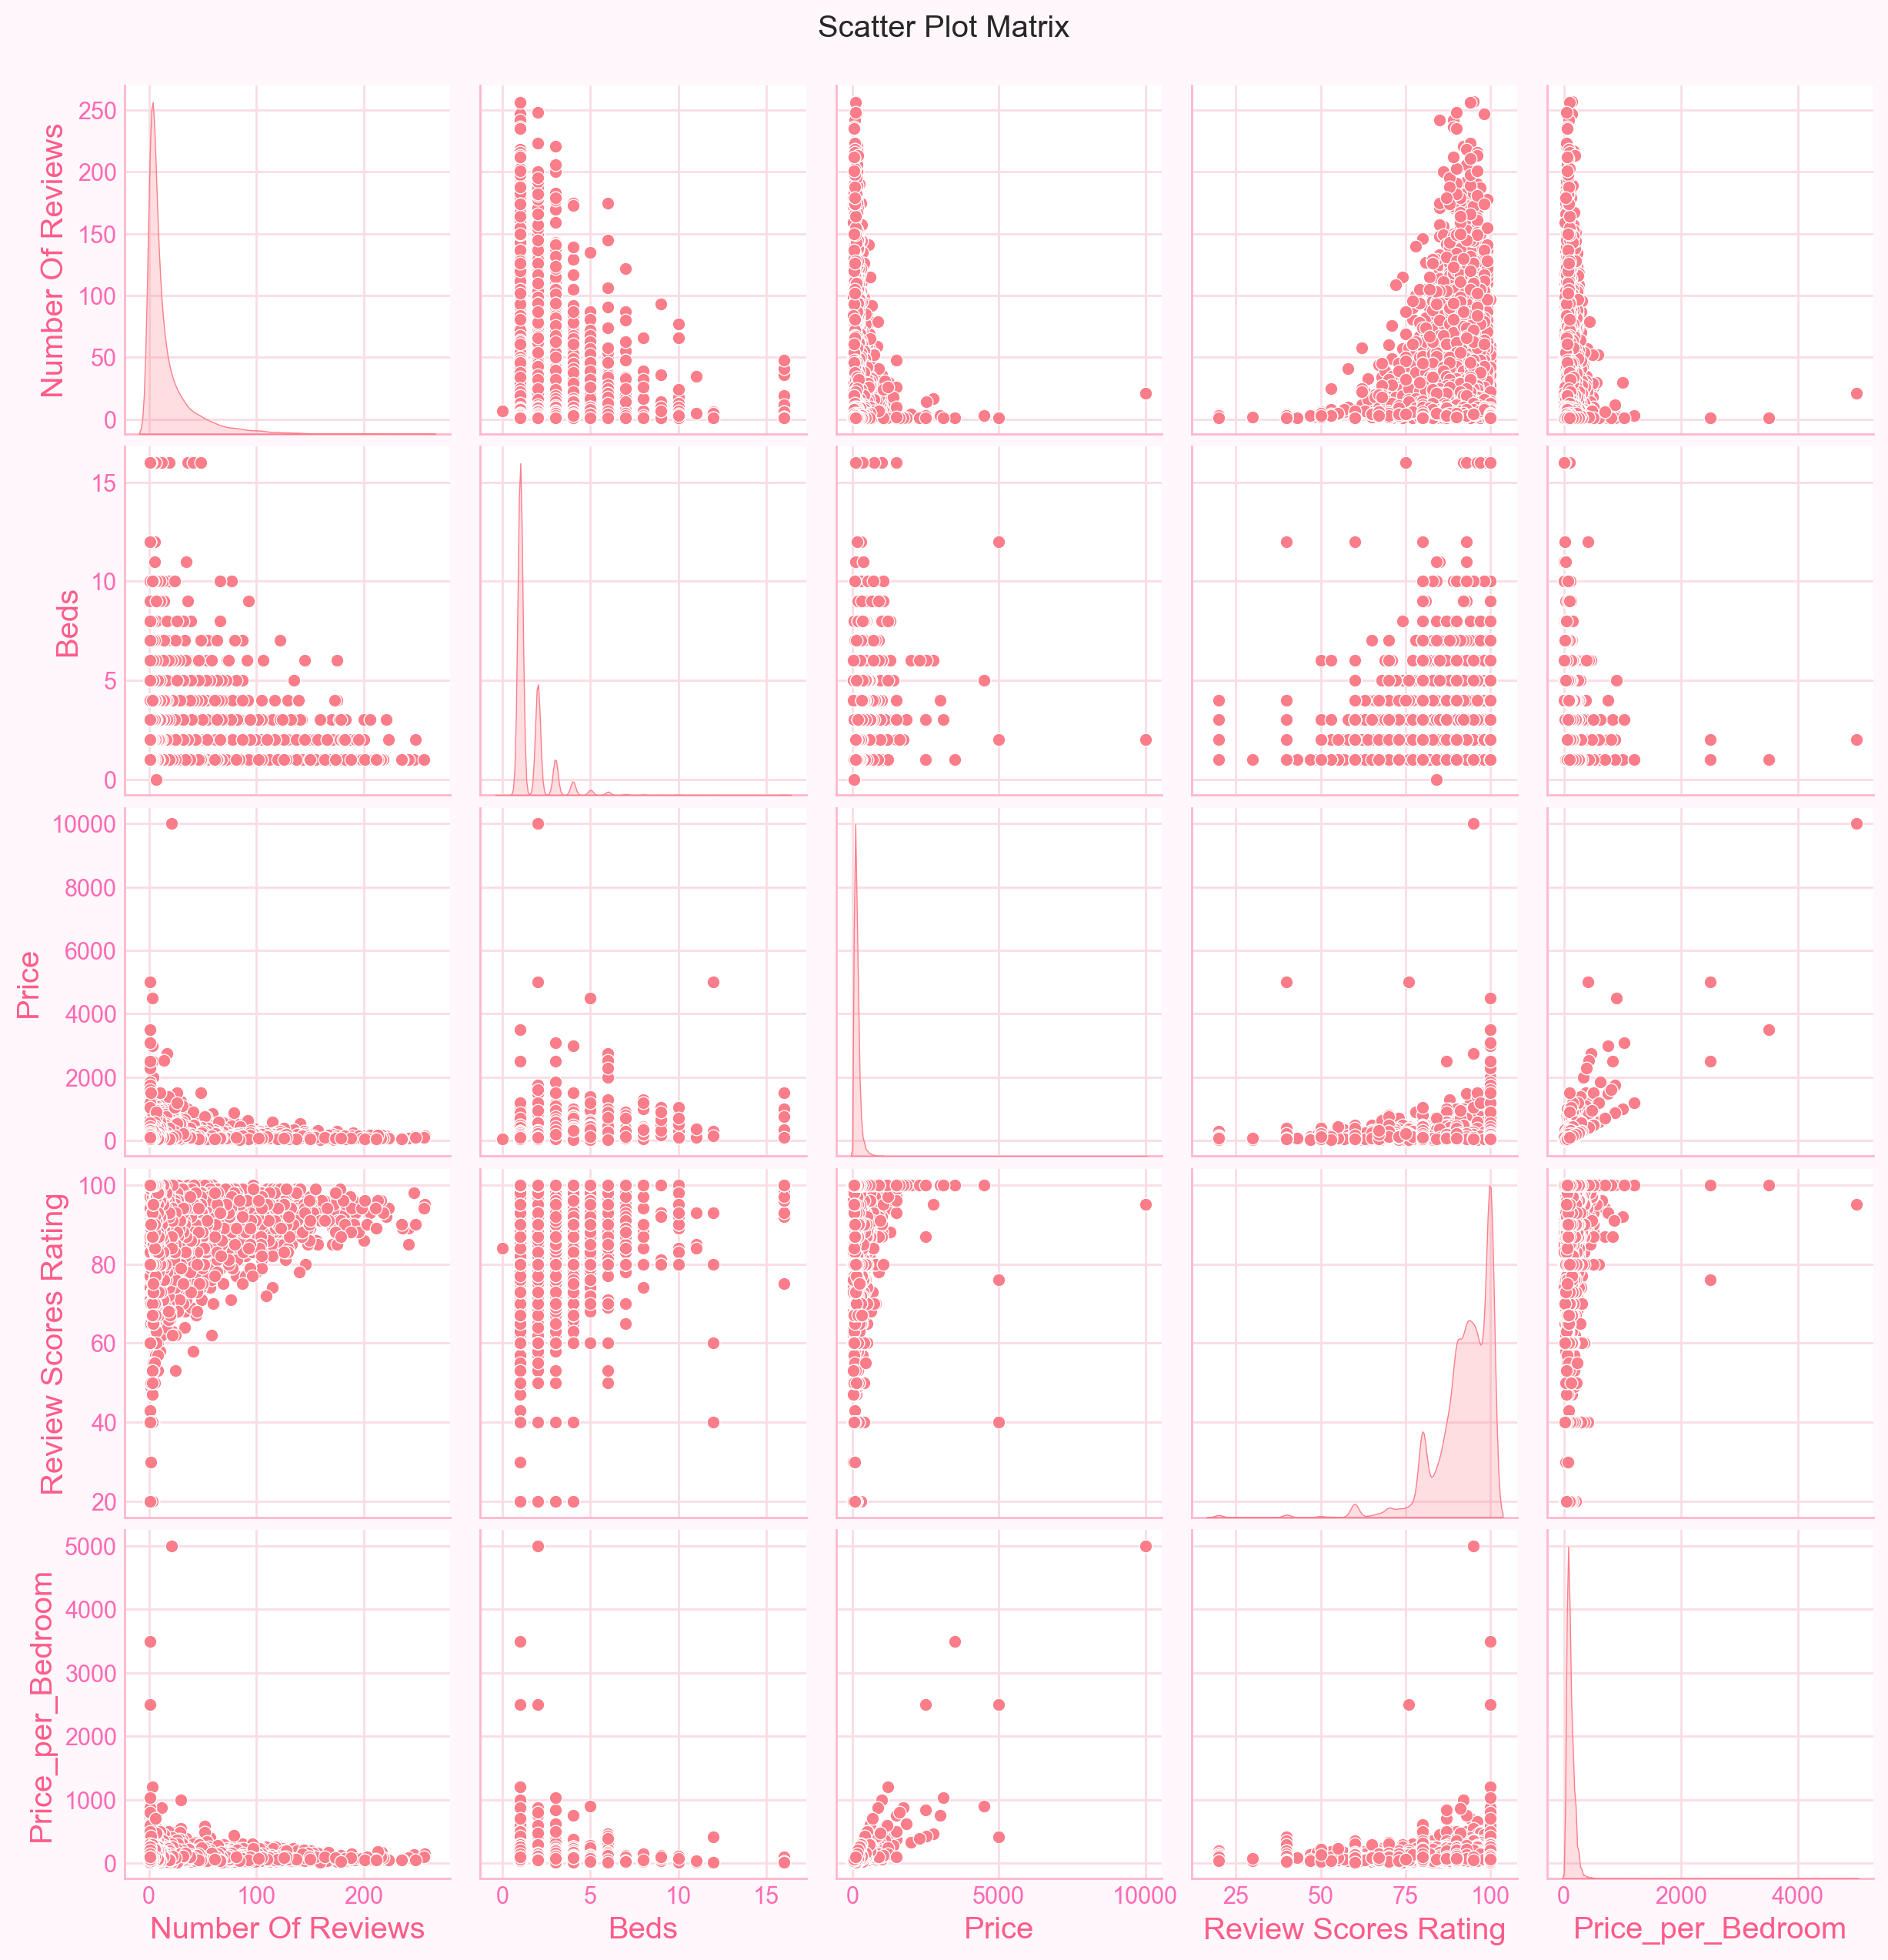

In [ ]:
#scatter plot matrix 
sns.pairplot(df2[numerical_cols_df2], diag_kind="kde", kind="scatter")
plt.suptitle("Scatter Plot Matrix", y=1.02)
plt.show()

### <a id='toc2_7_3_'></a>[Parallel Coordinate Plot](#toc0_)


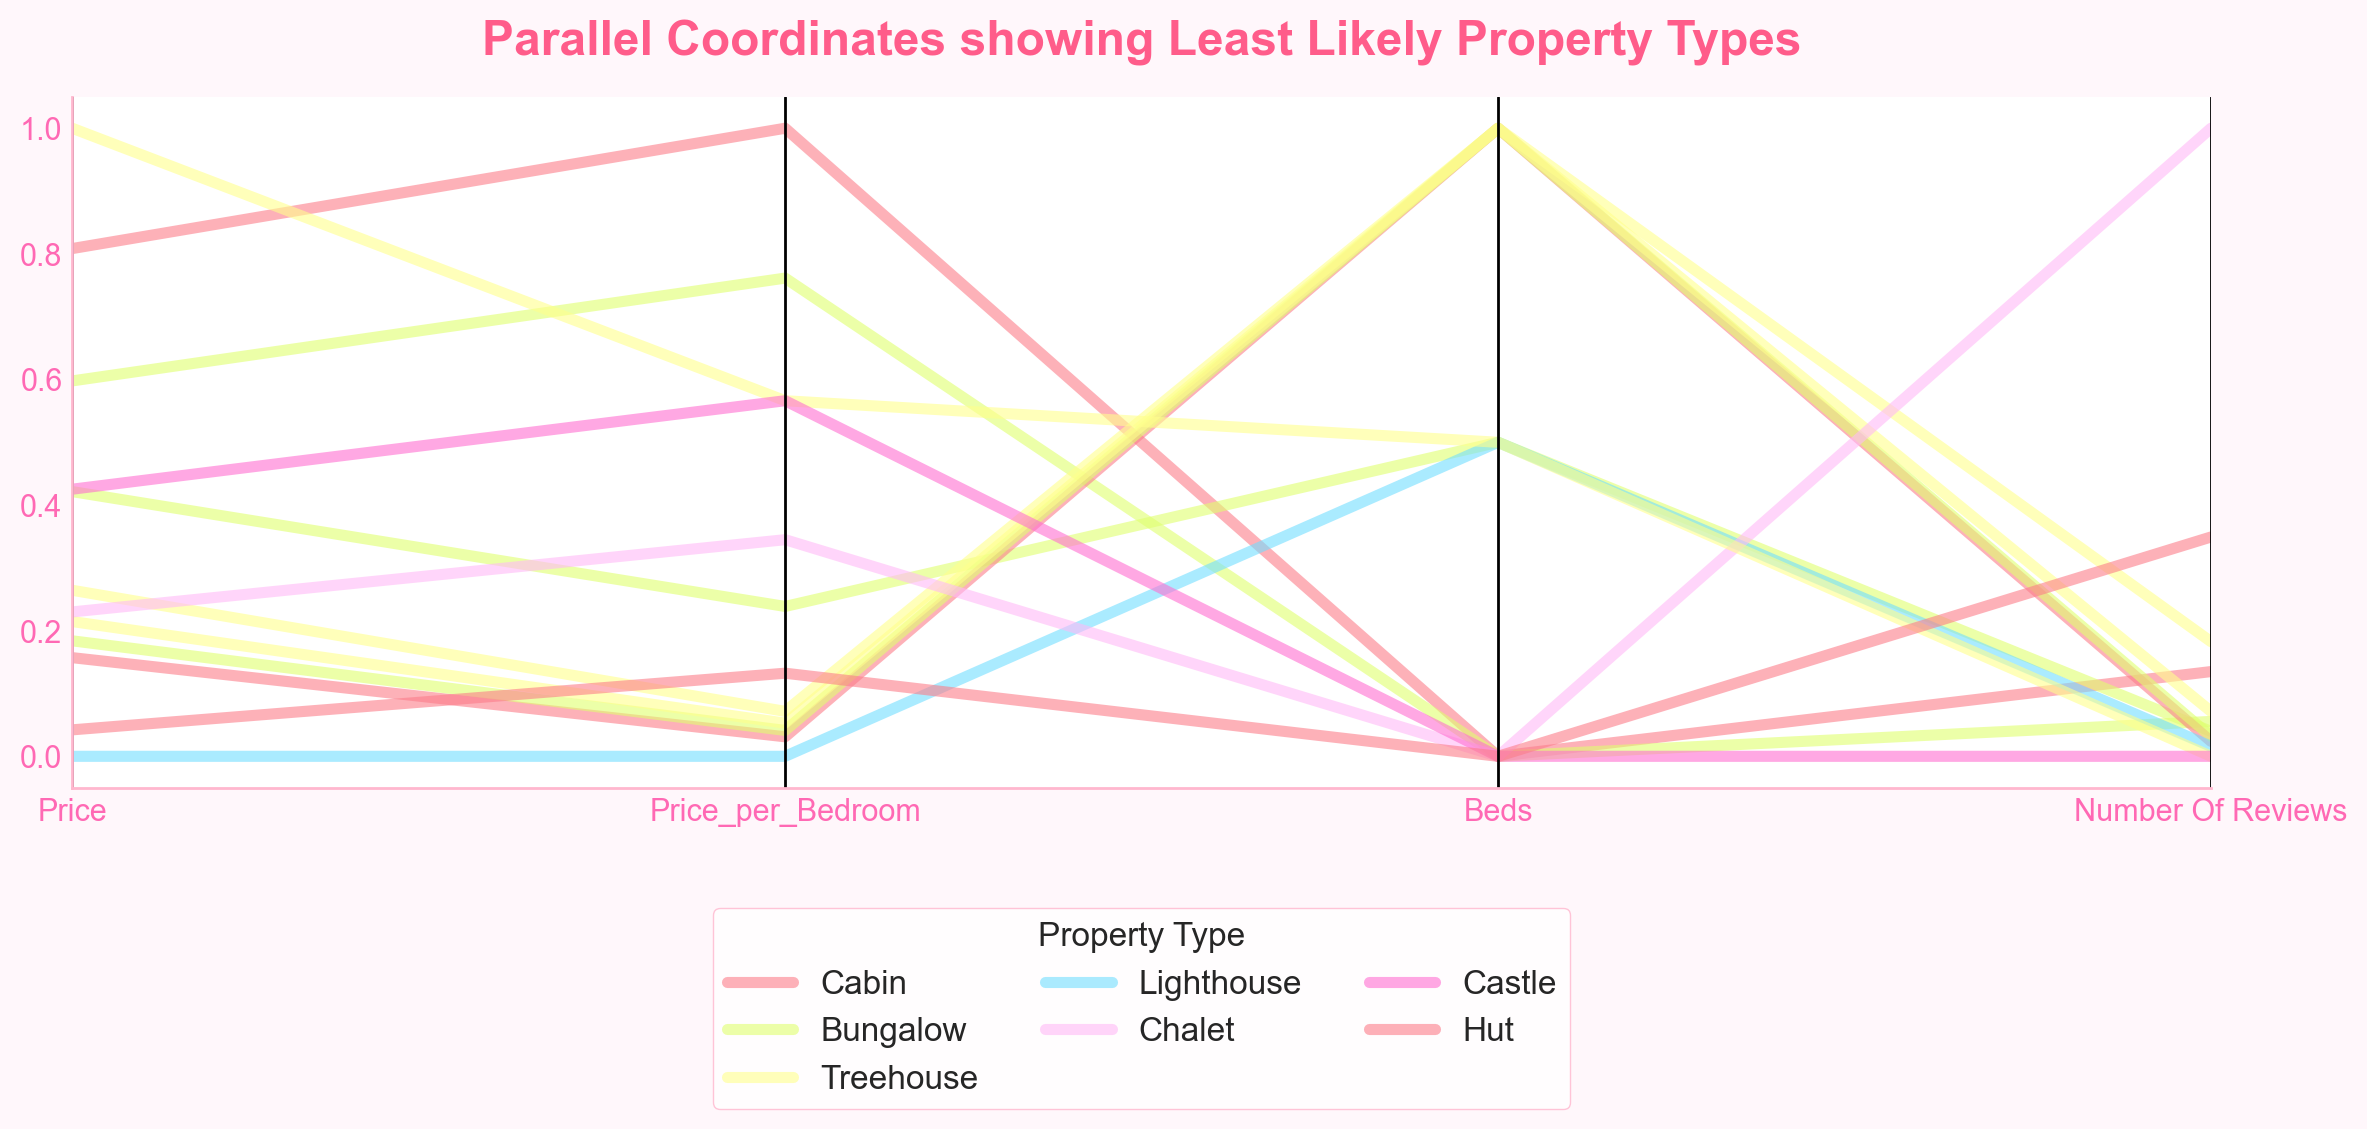

In [ ]:

cols = ['Price', 'Price_per_Bedroom', 'Beds', 'Number Of Reviews']
group_col = 'Property Type'

# filter top groups and drop rows with missing value
top_groups = df2[group_col].value_counts().nsmallest(8).index.tolist()

df_pc = df2[df2[group_col].isin(top_groups)][cols + [group_col]].dropna()

# normalize numeric columns so axes are comparable
df_norm = df_pc.copy()
df_norm[cols] = (df_norm[cols] - df_norm[cols].min()) / (df_norm[cols].max() - df_norm[cols].min())

# sample if too many rows
max_rows = 200
if len(df_norm) > max_rows:
    df_norm = df_norm.sample(max_rows, random_state=42)


plt.figure(figsize=(12, 6))
parallel_coordinates(df_norm[[group_col] + cols], class_column=group_col, color=kawaii_palette, alpha=0.6)
plt.title('Parallel Coordinates showing Least Likely Property Types')
plt.legend(title=group_col, bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=3)
plt.tight_layout()
plt.show()

### <a id='toc2_7_4_'></a>[Trellis Plot](#toc0_)

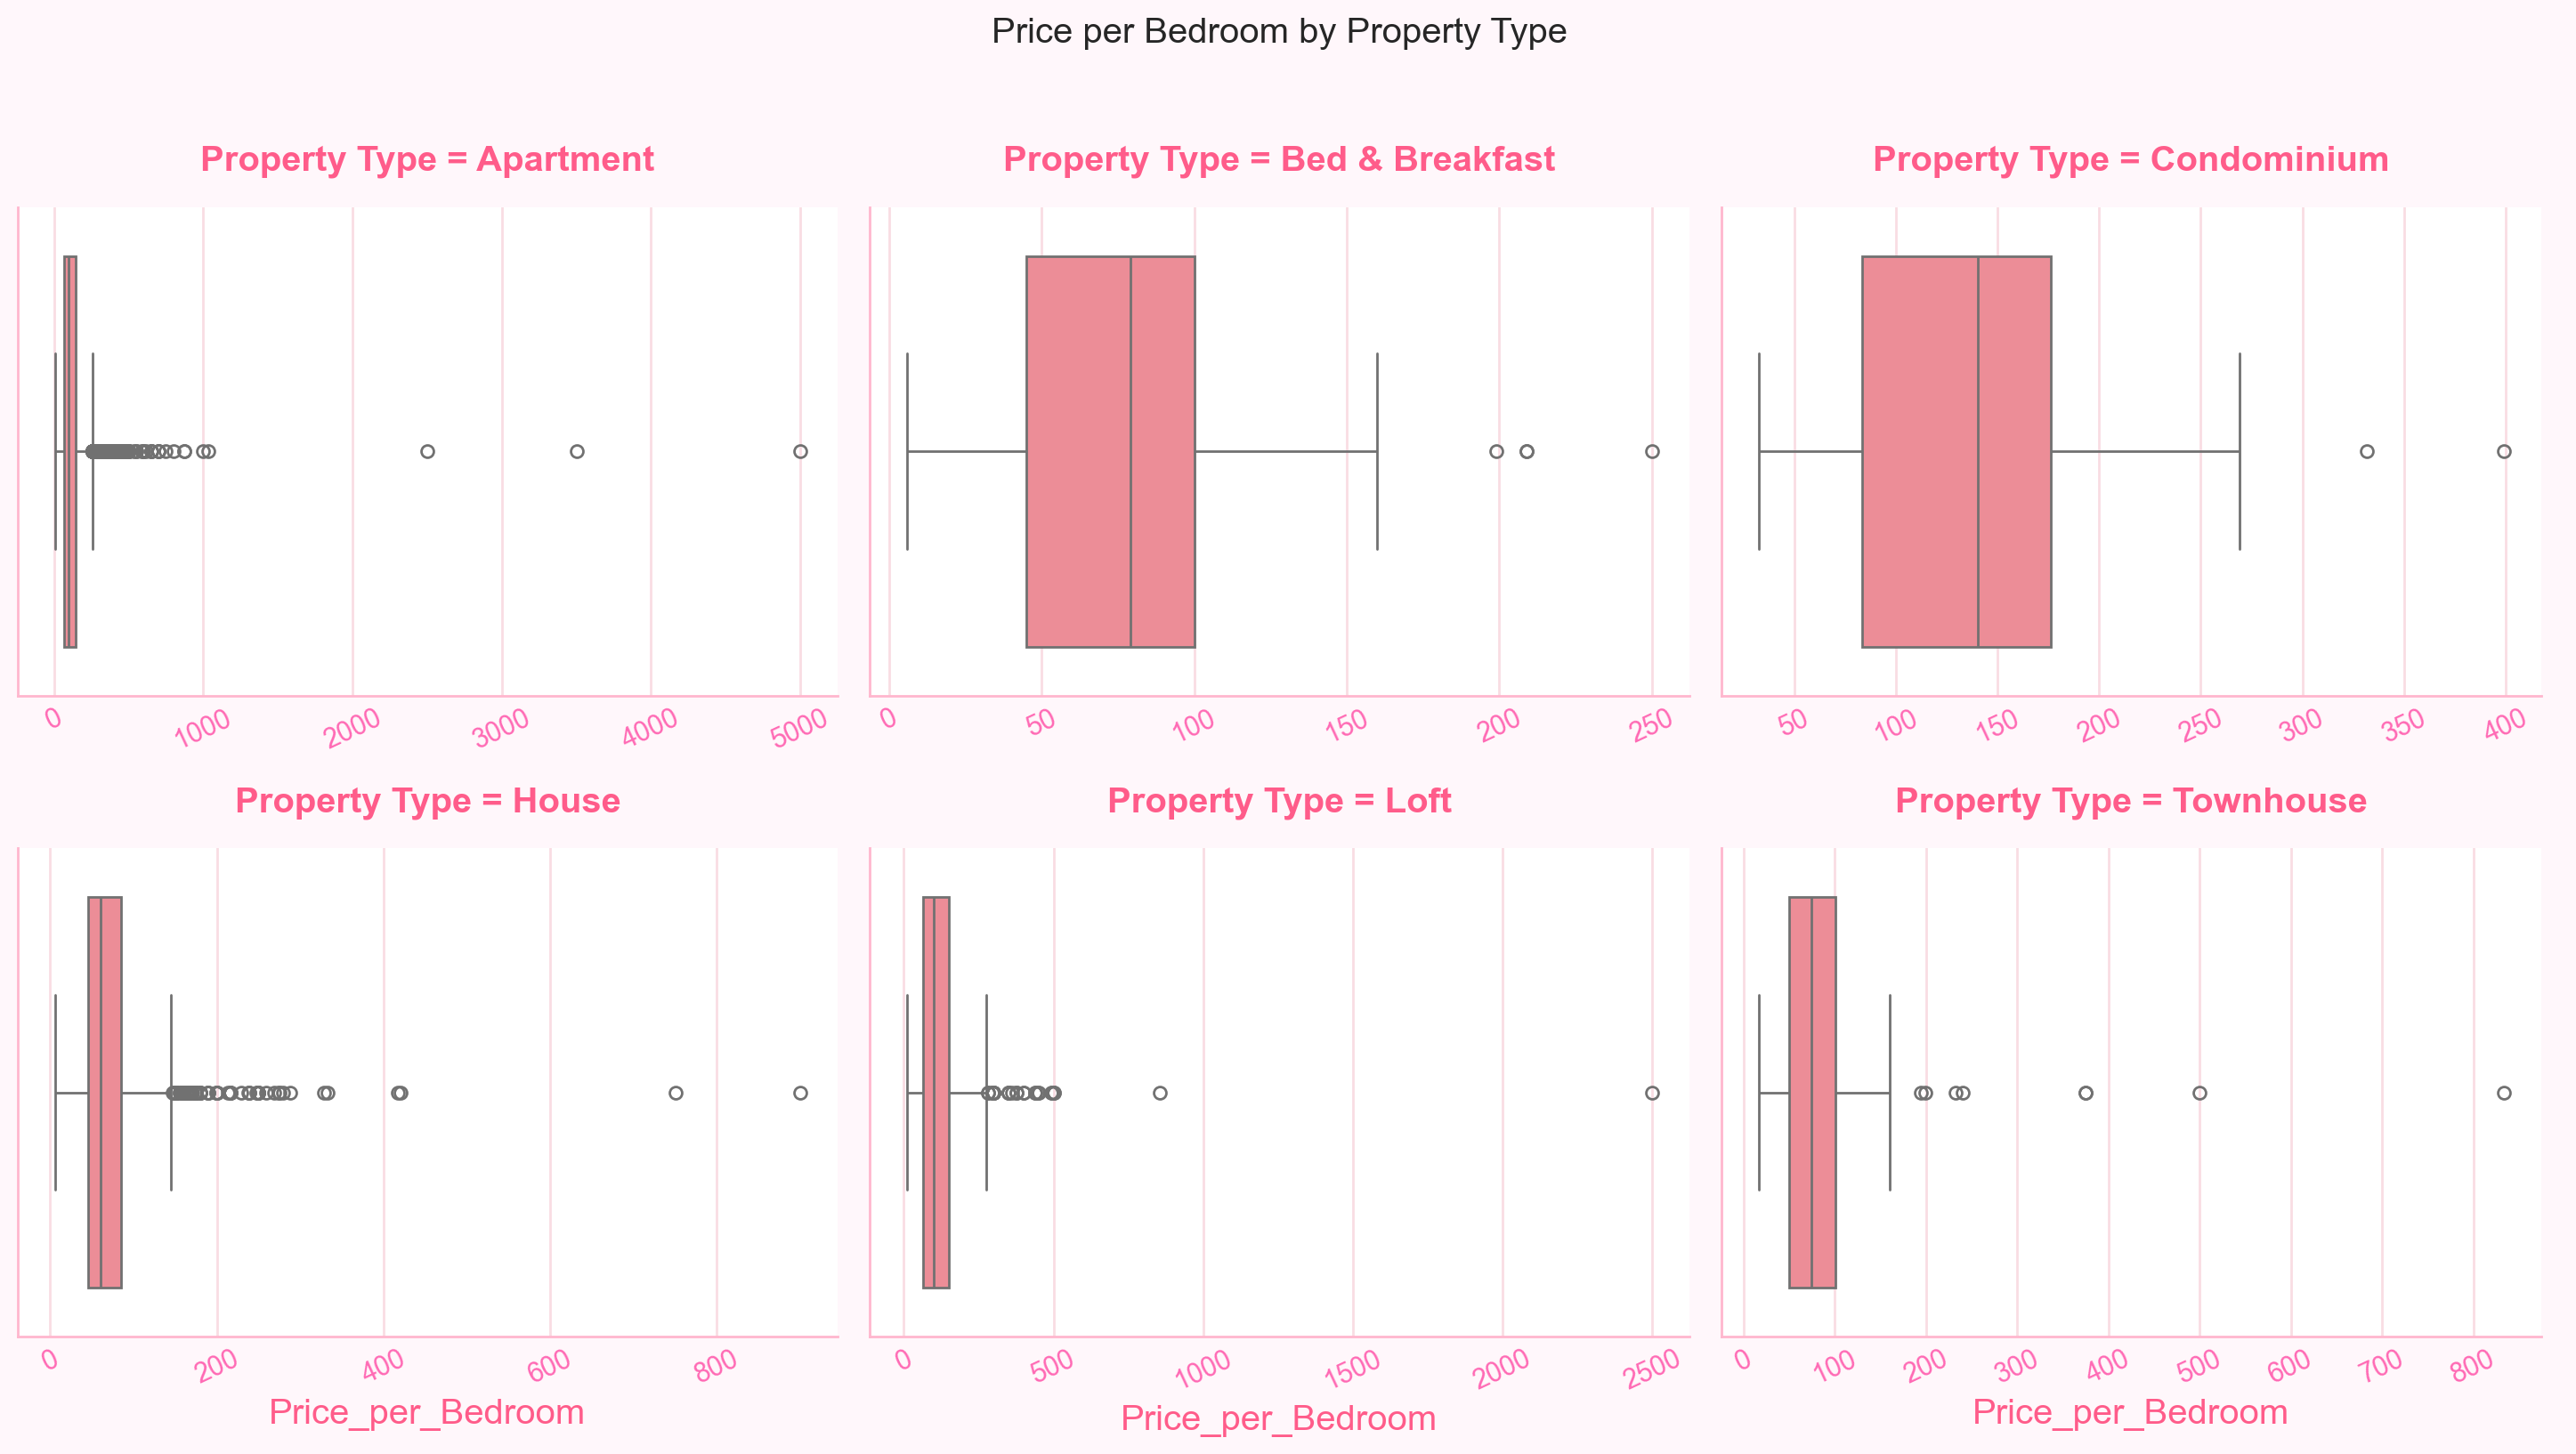

In [ ]:

top_types = df2['Property Type'].value_counts().nlargest(6).index.tolist()
df_box = df2[df2['Property Type'].isin(top_types)].copy()

if df_box['Property Type'].dtype.name == 'category':
    df_box['Property Type'] = df_box['Property Type'].cat.remove_unused_categories()


g2 = sns.catplot(
    data=df_box,
    x='Price_per_Bedroom',
    col='Property Type',
    col_wrap=3,
    kind='box',
    height=4, aspect=1.2,
    sharex=False
)
plt.suptitle('Price per Bedroom by Property Type', y=1.02)
for ax in g2.axes.flatten():
    ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()


### <a id='toc2_7_5_'></a>[Bonus: Chernoffs Faces](#toc0_)

In [ ]:
# find columns that are int or float
all_numerical_cols_df2 = [col for col in df2.columns if ptypes.is_numeric_dtype(df2[col])]
print(all_numerical_cols_df2)

['Host Id', 'Review Scores Rating (bin)', 'Zipcode', 'Beds', 'Number of Records', 'Number Of Reviews', 'Price', 'Review Scores Rating', 'Price_per_Bedroom']


In [ ]:
feature_mapping = {
    'Upper Face Height': all_numerical_cols_df2[0],
    'Lower Face Overlap': all_numerical_cols_df2[1],
    'Vertical Face Size': all_numerical_cols_df2[2],
    'Upper Face Width': all_numerical_cols_df2[3],
    'Lower Face Width': all_numerical_cols_df2[4],
    'Nose Length': all_numerical_cols_df2[2],
    'Mouth Position': all_numerical_cols_df2[6],
    'Mouth Curvature': all_numerical_cols_df2[7],
    'Mouth Width': all_numerical_cols_df2[8]
}

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


<Figure size 2000x1000 with 0 Axes>

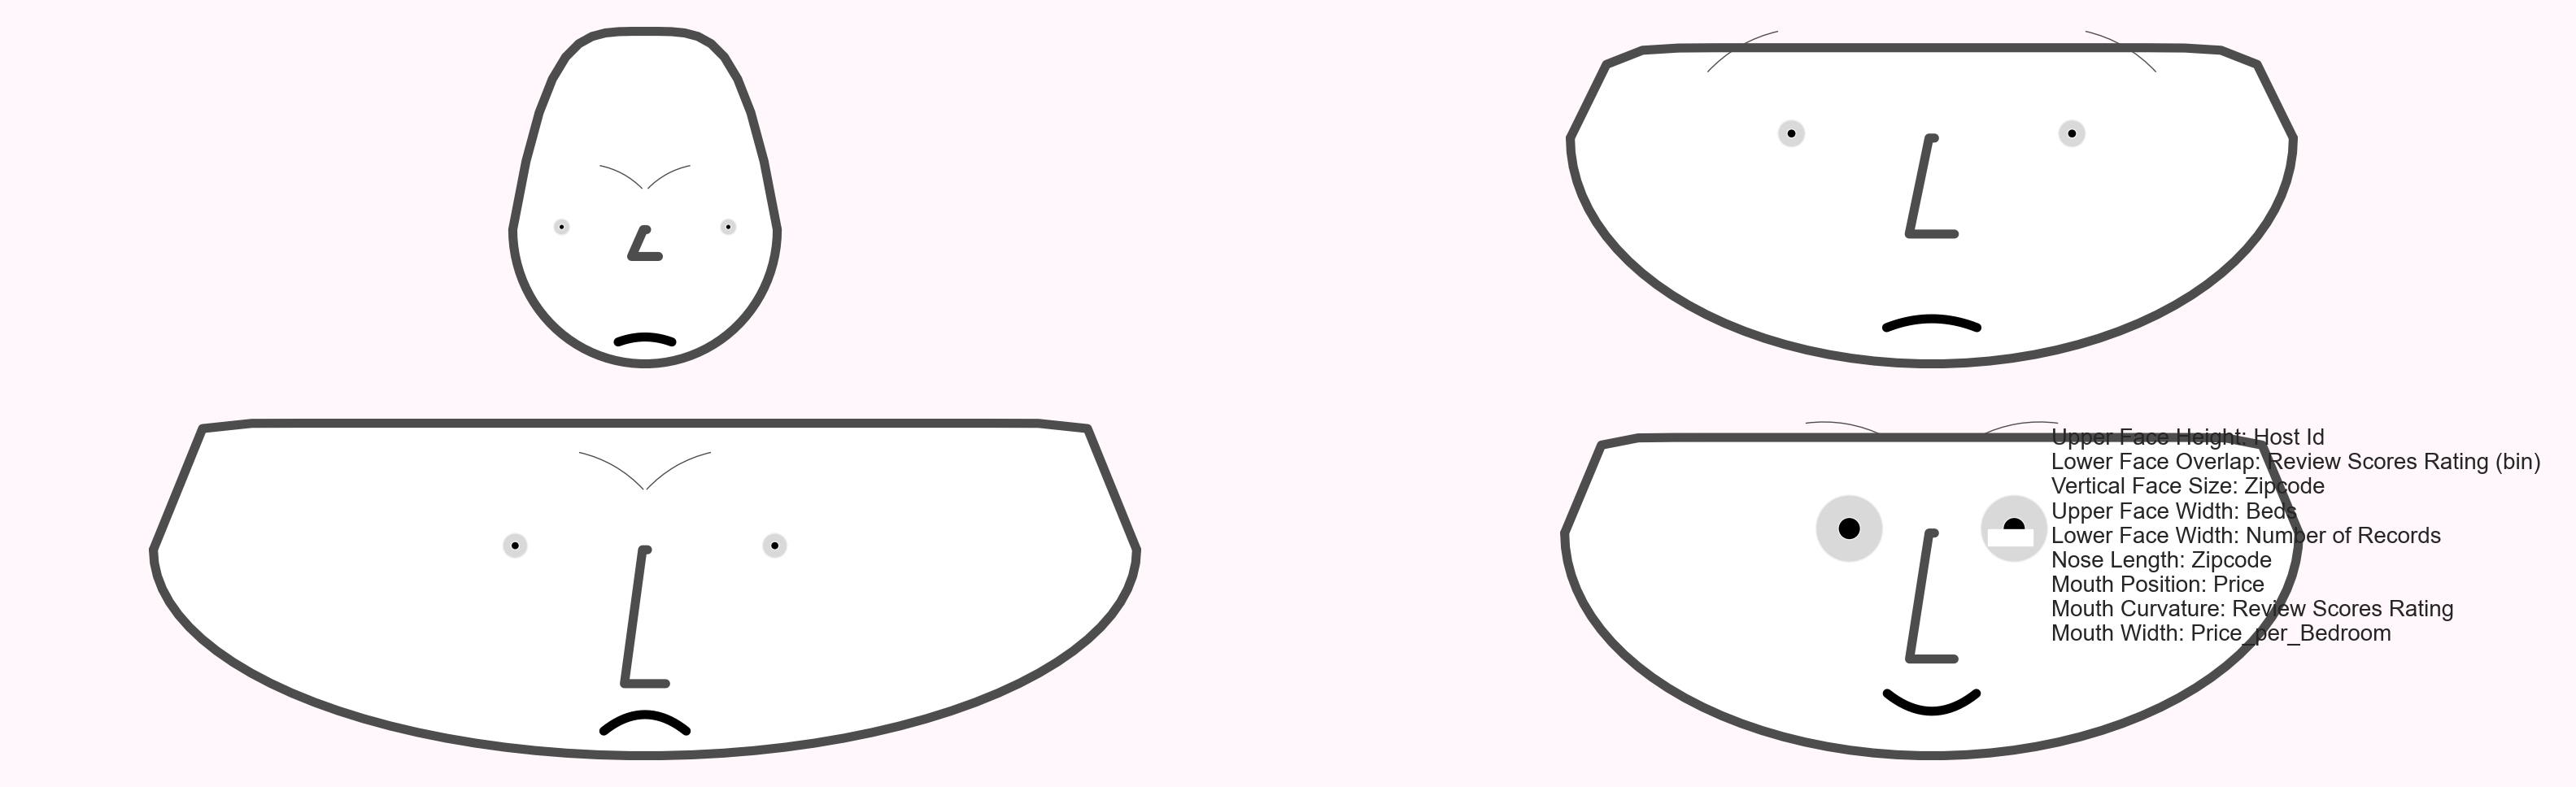

In [ ]:

df_numeric = df2[all_numerical_cols_df2].dropna().sample(4)

df_scaled = (df_numeric - df_numeric.min()) / (df_numeric.max() - df_numeric.min())

n = len(df_scaled)
plt.figure(figsize=(20, 10))
plt.suptitle("Chernoff Faces (Sample of Listings)", fontsize=14)

chernoff_face(df_scaled.values)
legend_text = "\n".join([f"{feat}: {col}" for feat, col in feature_mapping.items()])
plt.legend([legend_text], loc='upper right', fontsize=10, frameon=False)
plt.tight_layout()
plt.show()


# <a id='toc3_'></a>[Data Ink Ratios](#toc0_)

## <a id='toc3_1_'></a>[2d Images](#toc0_)


In [42]:
images = [cv2.imread(f"obj_2-{name}.png", cv2.COLOR_RGBA2GRAY) for name in ["Sales", "Energy", "WebTraffic"]]

In [75]:

def data_ink_2d_img(image):
    data_ink =0
    non_data_ink=0
    data_ink_ratio=0
    if len(image.shape) == 2:
        rgb = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
    elif image.shape[2] == 4:
        rgb = cv2.cvtColor(image, cv2.COLOR_RGBA2RGB)
    else:
        rgb = image.copy()

    height, width, _ = rgb.shape
    classified = np.zeros((height, width, 3), dtype=np.uint8)

    for y in range(height):
        for x in range(width):
            red, green, blue = rgb[y, x]

            if red > 250 and green > 250 and blue > 250:
                classified[y, x] = [255, 255, 255]
                non_data_ink += 1    
            else:
                is_light_gray= abs(red - green) < 15 and abs(green - blue) < 15 and 200 <= red <= 250
                is_dark_gray = abs(red - green) < 15 and abs(green - blue) < 15 and red < 100
                is_black = red < 50 and green < 50 and blue < 50

                if is_light_gray or is_dark_gray or is_black:
                    classified[y, x] = [128, 0, 128] 
                    non_data_ink += 1       
                else:
                    classified[y, x] = [255, 105, 180] 
                    data_ink += 1

    data_ink_ratio = (data_ink / (data_ink + non_data_ink)) * 100 if (data_ink + non_data_ink) > 0 else 0
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))
    ax[0].imshow(rgb)
    ax[0].set_title("Original Image")
    ax[0].axis("off")

    ax[1].imshow(classified)
    ax[1].set_title("Final Image\nPink:Data Ink, Purple:Non-data Ink")
    ax[1].axis("off")

    plt.tight_layout()
    plt.show()

    print(f"Data Ink Pixels: {data_ink}")
    print(f"Non-Data Ink Pixels: {non_data_ink}")
    print(f"Data Ink Ratio: {data_ink_ratio:.2f}%")


In [7]:
# call functions to analyze an image
import cv2
from PIL import Image


C:\Users\ThinkPad T480s\AppData\Local\Temp\ipykernel_12800\3178054998.py:23: RuntimeWarning: overflow encountered in scalar subtract
  is_light_gray= abs(red - green) < 15 and abs(green - blue) < 15 and 200 <= red <= 250
C:\Users\ThinkPad T480s\AppData\Local\Temp\ipykernel_12800\3178054998.py:24: RuntimeWarning: overflow encountered in scalar subtract
  is_dark_gray = abs(red - green) < 15 and abs(green - blue) < 15 and red < 100


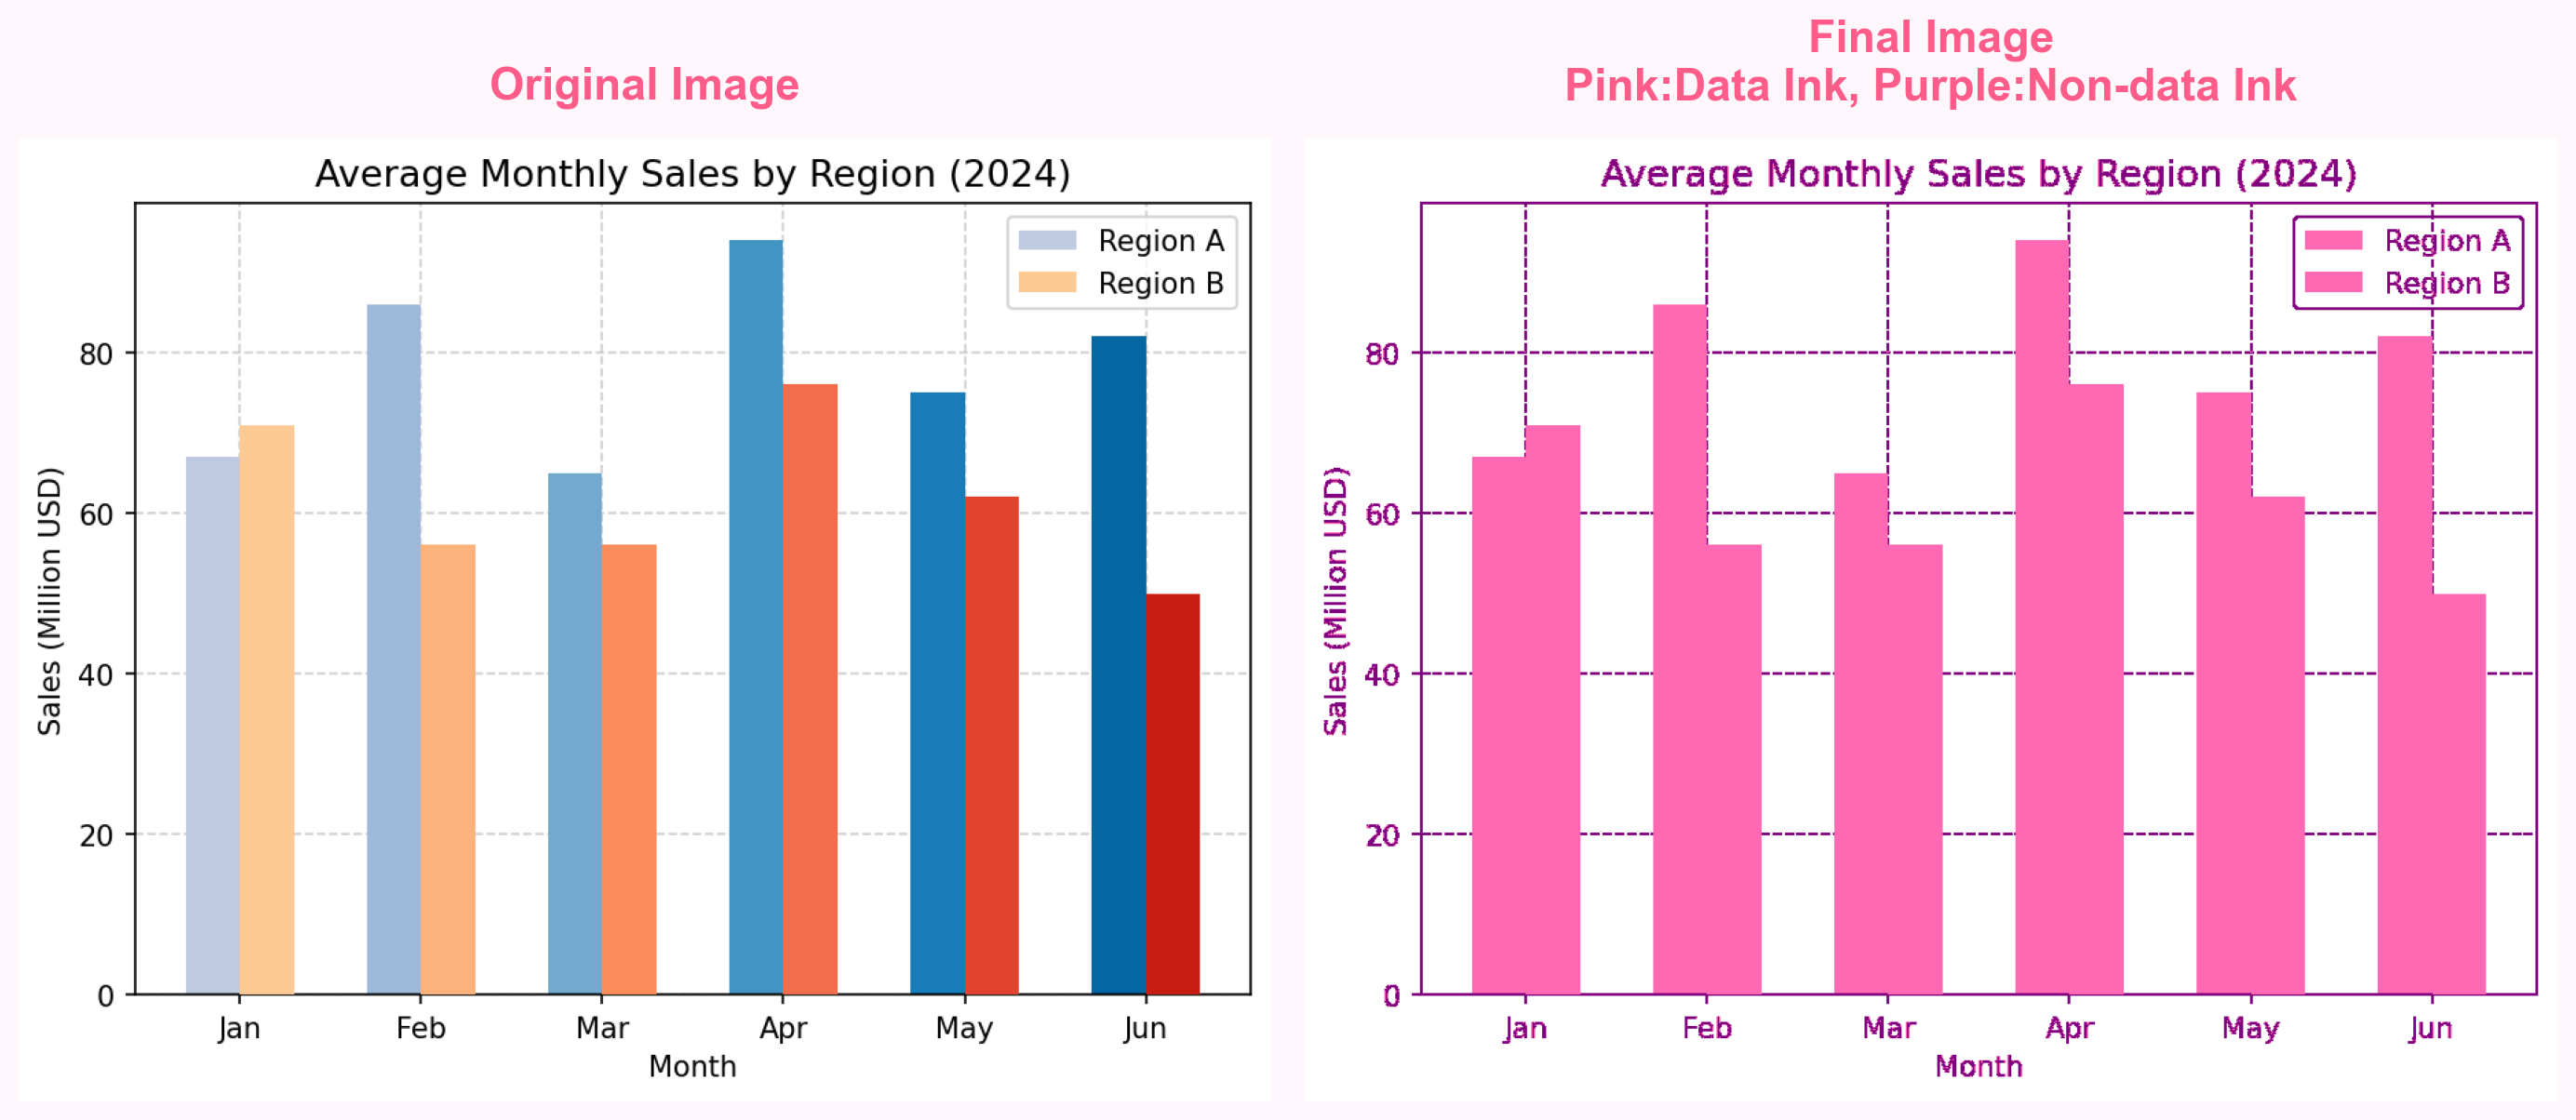

Data Ink Pixels: 197037
Non-Data Ink Pixels: 443889
Data Ink Ratio: 30.74%


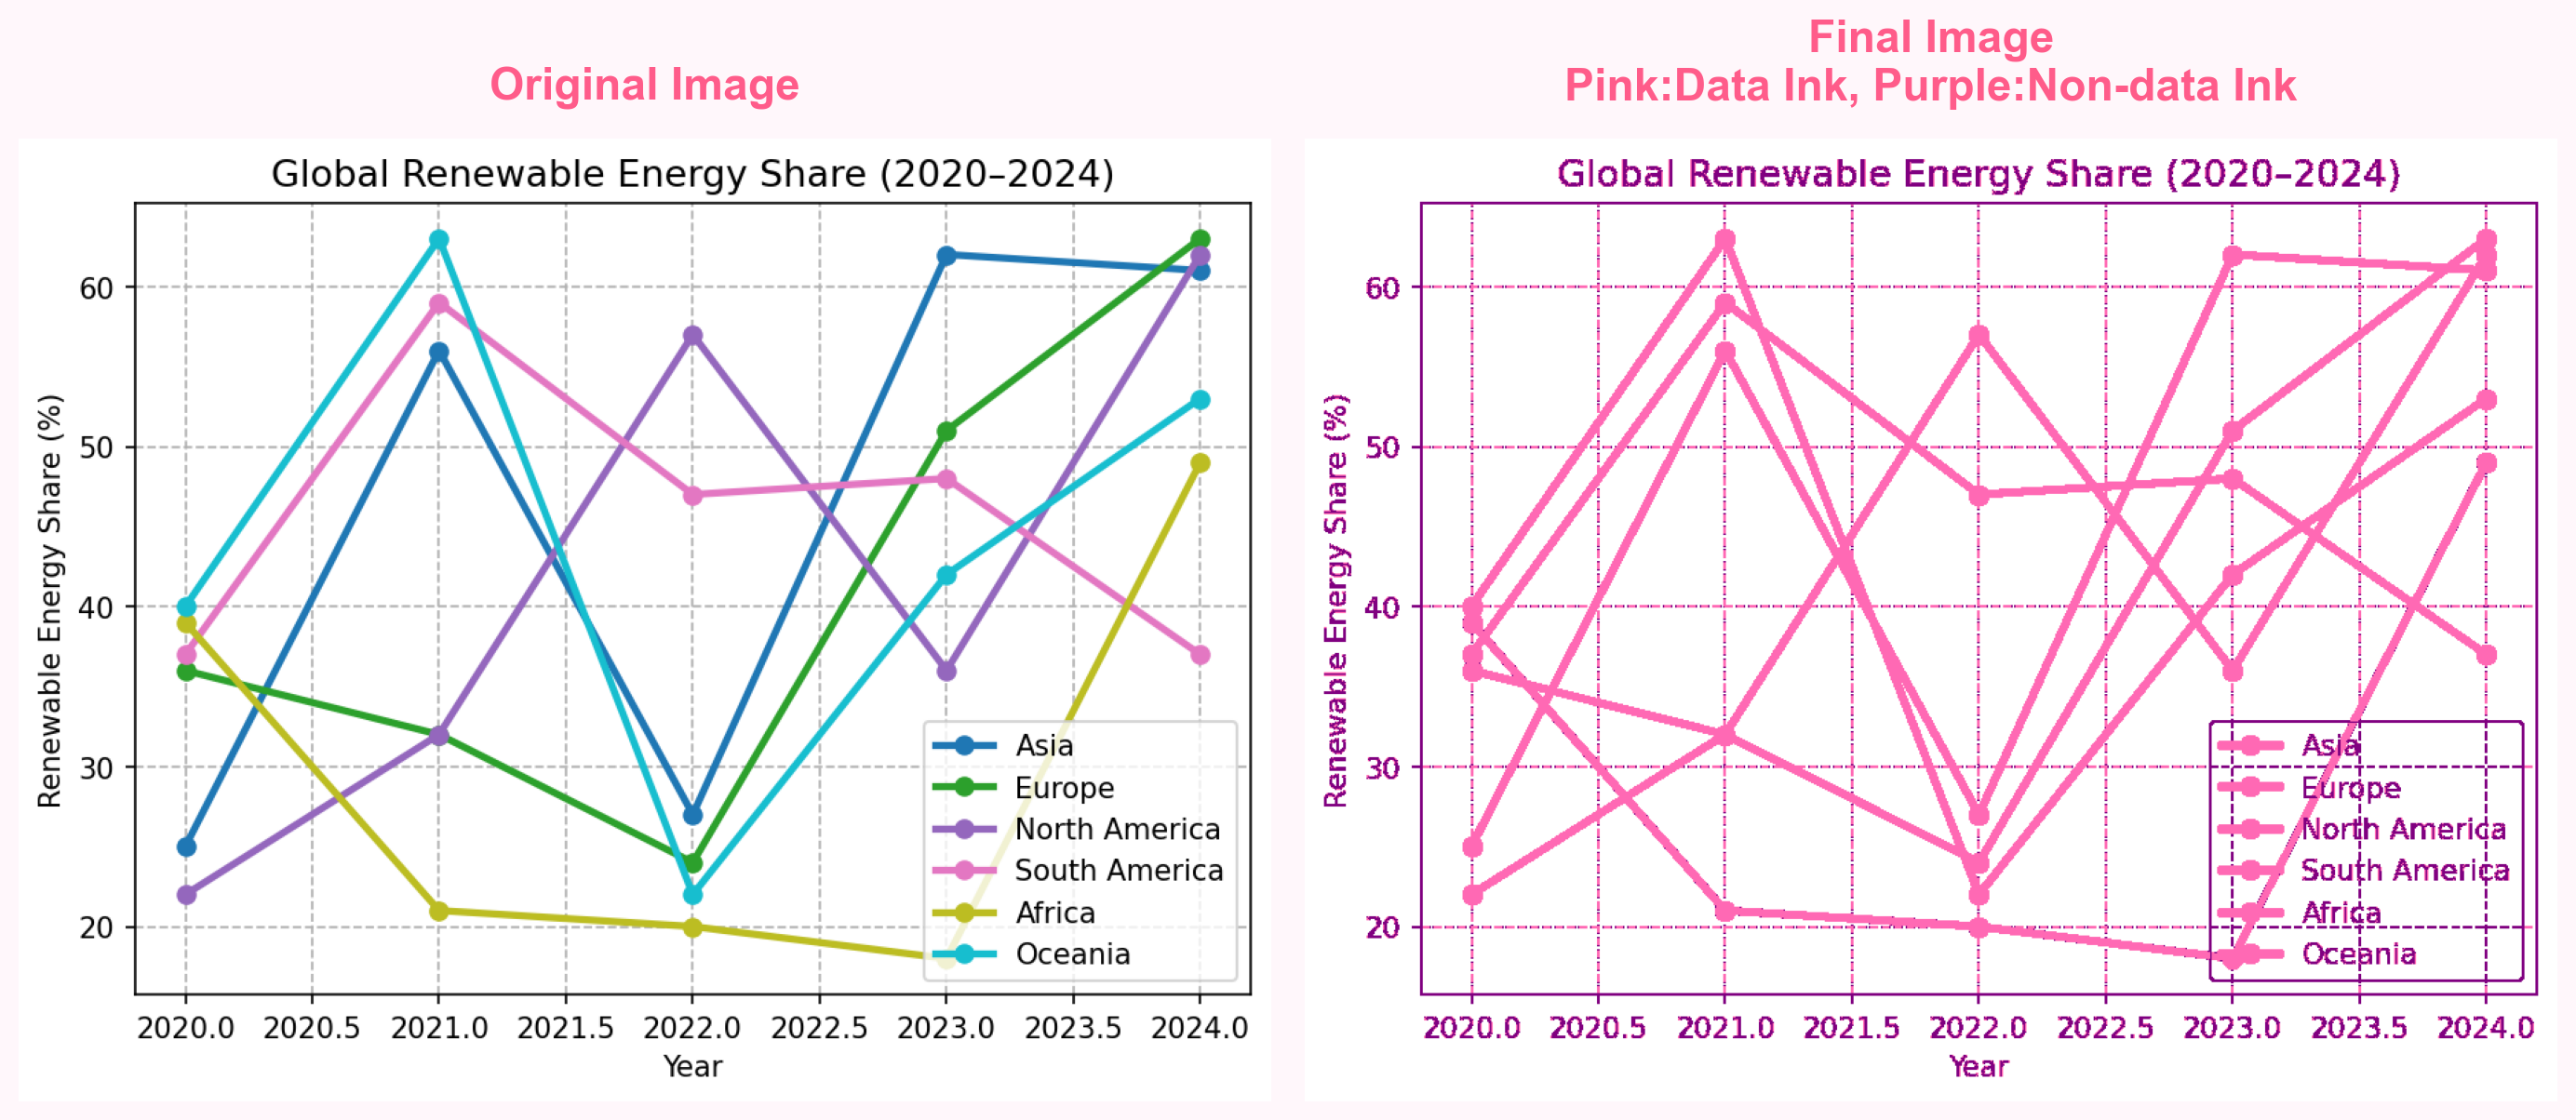

Data Ink Pixels: 59959
Non-Data Ink Pixels: 580967
Data Ink Ratio: 9.36%


In [76]:

image_paths = ["obj_2-Sales.png", "obj_2-Energy.png"]
for image_path in image_paths:
    img = Image.open(image_path)
    img_array = np.array(img)
    data_ink_2d_img(img_array)


## <a id='toc3_2_'></a>[3d Image](#toc0_)


In [ ]:

allowed_values = [44, 70, 98, 125, 150, 177]
def visualize_data_ink(gray_img):
    data_ink = 0
    non_data = 0

    classified = np.zeros((gray_img.shape[0], gray_img.shape[1], 3), dtype=np.uint8)

    for y in range(gray_img.shape[0]):
        for x in range(gray_img.shape[1]):
            p = gray_img[y, x]
            if p in allowed_values:
                classified[y, x] = [255, 105, 180]  
                data_ink += 1
            elif p < 240: 
                classified[y, x] = [128, 0, 128]  
                non_data += 1

    ratio = (data_ink / (data_ink + non_data) * 100) if (data_ink + non_data) > 0 else 0

    # Show result
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1), plt.imshow(gray_img, cmap="gray"), plt.title("Original"), plt.axis("off")
    plt.subplot(1, 2, 2), plt.imshow(classified), plt.title("Data Ink Map"), plt.axis("off")
    plt.show()

    print(f"Data Ink Pixels: {data_ink}")
    print(f"Non-Data Ink Pixels: {non_data}")
    print(f"Data Ink Ratio: {ratio:.2f}%")


C:\Users\ThinkPad T480s\AppData\Local\Temp\ipykernel_12800\2800965775.py:18: RuntimeWarning: overflow encountered in scalar subtract
  if any(abs(p - val) <= tolerance_range for val in DATA_GRAY_VALUES):


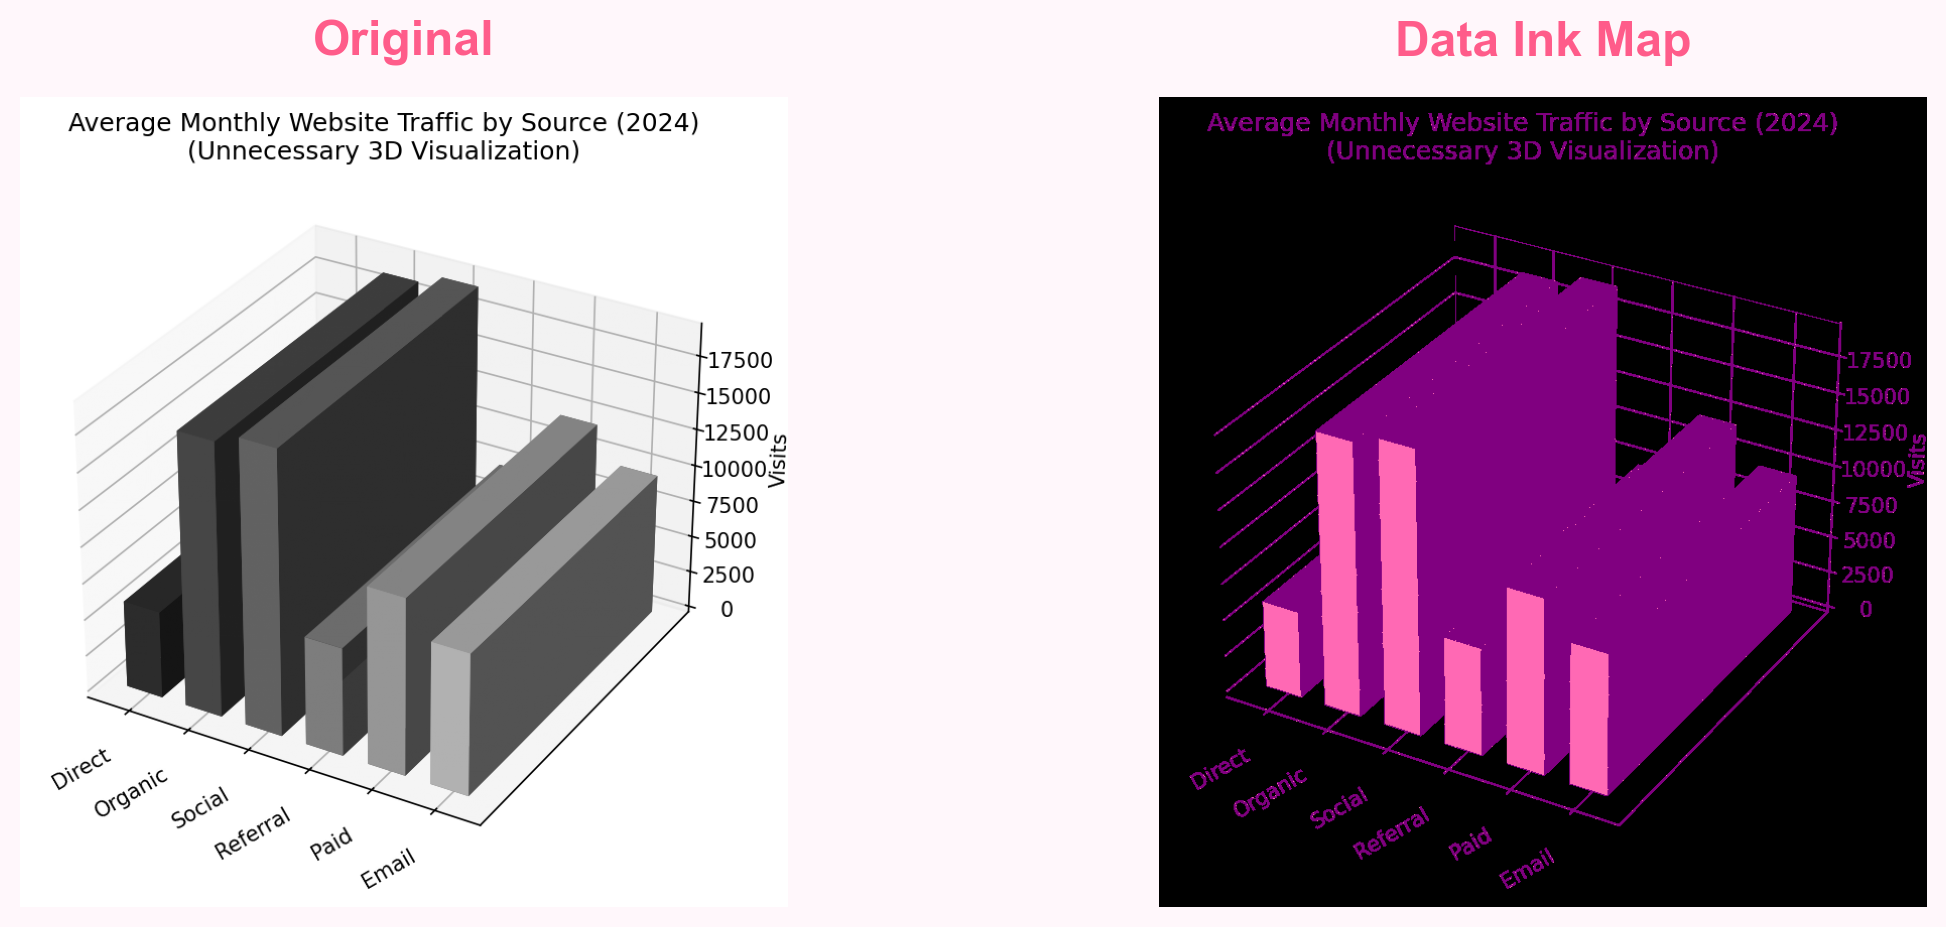

Data Ink Pixels: 38414
Non-Data Ink Pixels: 158312
Data Ink Ratio: 19.53%


In [77]:
imagepath = "obj_2-WebTraffic.png"
image = cv2.imread(imagepath, cv2.IMREAD_GRAYSCALE)
visualize_data_ink(image)